# PINN flux reconstruction - Koppel-Martin Case 1 (2D point trace)

Nonconforming **2D** LCG solve (unit-square quad bulk + independent 1D fracture,
codimension-1 pointwise trace coupling, no `fenicsx_ii`, no slab/thickness),
followed by the two-network ghost-partition PINN flux reconstruction of the
matrix flux `Q = -k_m grad(p_m)`.


In [2]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from dolfinx import fem, geometry, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError('This manual point-trace assembly notebook is serial; run it with one MPI rank.')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1234)
np.random.seed(1234)

REF = 6
ORDER = 1

K_M_VALUE = 1.0
K_F_VALUE = 10.0

# Koppel-Martin case 1 boundary-tip fracture.
FRAC_A = np.array([0.25, 0.0], dtype=float)
FRAC_B = np.array([0.75, 1.0], dtype=float)
TIP_FRAC = 0.05


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)
_G3_SYM = np.array([-np.sqrt(3.0 / 5.0), 0.0, np.sqrt(3.0 / 5.0)], dtype=float)
_W3_SYM = np.array([5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0], dtype=float)


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells)


def make_fracture_pressure_mesh(h):
    # Fracture pressure remains P1 on a relatively fine independent mesh.
    h_gamma_target = 0.5 * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_gamma + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_multiplier_mesh(h):
    # Koppel-Martin case-1 setting for P0 multipliers: h_lambda approx 2h.
    h_lambda_target = 2.0 * h
    n_lambda = max(1, int(round(L_gamma / h_lambda_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_lambda + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, h_gamma, n_gamma = make_fracture_pressure_mesh(h)
    gamma_l, h_lambda, n_lambda = make_multiplier_mesh(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_G3):
        for j, eta in enumerate(_G3):
            pts.append([xi, eta])
            weights.append(_W3[i] * _W3[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_coords[dofs],
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def q1_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    x0, x1, y0, y1 = cell["x0"], cell["x1"], cell["y0"], cell["y1"]
    hx, hy = cell["hx"], cell["hy"]
    vals = np.zeros((pts.shape[0], len(cell["dofs"])), dtype=float)
    grads = np.zeros((pts.shape[0], len(cell["dofs"]), 2), dtype=float)
    xmid = 0.5 * (x0 + x1)
    ymid = 0.5 * (y0 + y1)
    for a, xy in enumerate(cell["dof_xy"]):
        if xy[0] < xmid:
            px = (x1 - x) / hx
            dpx = np.full_like(x, -1.0 / hx)
        else:
            px = (x - x0) / hx
            dpx = np.full_like(x, 1.0 / hx)
        if xy[1] < ymid:
            py = (y1 - y) / hy
            dpy = np.full_like(y, -1.0 / hy)
        else:
            py = (y - y0) / hy
            dpy = np.full_like(y, 1.0 / hy)
        vals[:, a] = px * py
        grads[:, a, 0] = dpx * py
        grads[:, a, 1] = px * dpy
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


In [4]:
def assemble_bulk_stiffness(A, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        _, grads = q1_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)


def build_fracture_pressure_data(gamma, V_f):
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    cells = []
    s_nodes = []
    num_gamma_cells = gamma.topology.index_map(gamma.topology.dim).size_local
    for ci in range(num_gamma_cells):
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        s = s_coord_np(coords_f[fdofs])
        order = np.argsort(s)
        fdofs = fdofs[order]
        s = s[order]
        cells.append({"dofs": fdofs, "s0": float(s[0]), "s1": float(s[1])})
        s_nodes.extend([float(s[0]), float(s[1])])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    starts = np.array([c["s0"] for c in cells], dtype=float)
    order = np.argsort(starts)
    cells = [cells[i] for i in order]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_pressure_cell_s(s, pressure_data, tol=1e-12):
    cells = pressure_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def p1_line_basis_on_pressure_cell(cell, s):
    ell = cell["s1"] - cell["s0"]
    return np.array([(cell["s1"] - s) / ell, (s - cell["s0"]) / ell], dtype=float)


def line_mesh_cell_s_intervals(domain):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    coords = domain.geometry.x[:, :2]
    intervals = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s = np.sort(s_coord_np(coords[verts]))
        intervals.append((float(s[0]), float(s[1])))
    return intervals


def s_breakpoints(s0, s1, s_nodes, tol=1e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_fracture_pressure_data(gamma, V_f)

    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        ell = cell["s1"] - cell["s0"]
        Kloc = (K_F_VALUE / ell) * np.array([[1.0, -1.0], [-1.0, 1.0]], dtype=float)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)

    for ci, (s0, s1) in enumerate(line_mesh_cell_s_intervals(gamma_l)):
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        ell = float(np.linalg.norm(seg))

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, b in zip(pbreaks[:-1], pbreaks[1:]):
            if b - a <= 1e-14:
                continue
            pcell = locate_pressure_cell_s(0.5 * (a + b), pressure_data)
            fdofs = pcell["dofs"]
            for q, w in zip(_G3, _W3):
                sq = a + (b - a) * q
                psi = p1_line_basis_on_pressure_cell(pcell, sq)
                weight = (b - a) * w
                A.setValues(off_f + fdofs, off_l + ldofs, (weight * psi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, off_f + fdofs, (-weight * psi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)

        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            for q, w in zip(_G3, _W3):
                r = r0 + (r1 - r0) * q
                xq = xa + r * seg
                phi = q1_values_grads_on_cell(bulk_cell, xq[None, :])[0][0]
                weight = ell * (r1 - r0) * w
                A.setValues(mdofs, off_l + ldofs, (-weight * phi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, mdofs, (weight * phi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, off_l = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1e-12

    left = np.where(np.isclose(coords_m[:, 0], 0.0, atol=tol))[0].astype(np.int32)
    right = np.where(np.isclose(coords_m[:, 0], 1.0, atol=tol))[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")

    bc_idx = np.concatenate([off_m + left, off_m + right, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        np.full(len(left), 1.0),
        np.full(len(right), 4.0),
        np.array([1.0]),
        np.array([4.0]),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    if order != 1:
        raise ValueError("The manual point-trace assembly is implemented for Q1/P1/P0 only.")
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", 1))
    V_f = fem.functionspace(gamma, ("Lagrange", 1))
    V_l = fem.functionspace(gamma_l, ("DG", 0))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=80, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    assemble_bulk_stiffness(A, bulk_data)
    assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()

    b = A.createVecRight()
    b.set(0.0)
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"km2d_ref{ref}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    k_m = fem.Constant(omega, np.eye(2, dtype=np.float64))
    k_f = fem.Constant(gamma, K_F_VALUE)
    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())

    if verbose:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda(P0)={n_l}, total={n_total}")

    return {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "k_f": k_f,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bbox": (xmin, xmax, ymin, ymax),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_total": int(n_total),
        "factor_solver": factor_solver,
    }


t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=True)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(
    f"ref={sol['ref']} h={sol['h']:.3e} h_gamma={sol['h_gamma']:.3e} "
    f"h_lambda={sol['h_lambda']:.3e} n_gamma={sol['n_gamma']} "
    f"n_lambda={sol['n_lambda']} total dofs={sol['ndof_total']}"
)
omega = sol["omega"]; gamma = sol["gamma"]; gamma_l = sol["gamma_l"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


PETSc LU factor solver: mumps
n_bulk=128, n_gamma=287, n_lambda=72, h=7.812e-03, h_gamma=3.896e-03, h_lambda=1.553e-02
dofs: matrix=16641, fracture=288, lambda(P0)=72, total=17001
LCG solve complete in 3.19 s
ref=6 h=7.812e-03 h_gamma=3.896e-03 h_lambda=1.553e-02 n_gamma=287 n_lambda=72 total dofs=17001


In [5]:
def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

# Actual 2D mesh-cell polygons, ordered counter-clockwise for geometry work.
cell_polys = [order_polygon_vertices(omega_geometry[verts, :2]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])


def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))


shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("2D quad cells:", num_cells, "unique edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
_q_pts = Wq.element.interpolation_points
q_cg_expr = fem.Expression(-ufl.dot(k_m, ufl.grad(p_m)), _q_pts)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)


def as_eval_points(points):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.zeros(points.shape[0])])


_BBTREE_CACHE = {}


def _get_bbtree(domain):
    key = id(domain)
    tree = _BBTREE_CACHE.get(key)
    if tree is None:
        tree = geometry.bb_tree(domain, domain.topology.dim)
        _BBTREE_CACHE[key] = tree
    return tree


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_eval_points(points)
    tree = _get_bbtree(domain)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]


def f_numpy(points):
    pts = np.asarray(points)
    return np.zeros(pts.reshape(-1, pts.shape[-1]).shape[0], dtype=float)


2D quad cells: 16384 unique edges: 33024


In [6]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)


t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np


def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))


def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals


def lambda_raw_on_s(s_query):
    return eval_fem_function(lmbd, real_points_np(s_query), gamma_l).reshape(-1)


def multiplier_s_nodes():
    gamma_l.topology.create_connectivity(gamma_l.topology.dim, 0)
    c2v_l = gamma_l.topology.connectivity(gamma_l.topology.dim, 0)
    coords_l = gamma_l.geometry.x[:, :2]
    vals = []
    for ci in range(gamma_l.topology.index_map(gamma_l.topology.dim).size_local):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        vals.extend(s_coord_np(coords_l[verts]))
    return np.unique(np.round(np.asarray(vals, dtype=float), 12))


_LAM_S_NODES = multiplier_s_nodes()
_GS2 = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])


def _split_at_lambda_nodes(s0, s1, tol=1e-12):
    lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
    inner = _LAM_S_NODES[(_LAM_S_NODES > lo + tol) & (_LAM_S_NODES < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval_raw(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_raw_on_s(sq))
    return float(total)


EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)


def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)


def integrate_cg_flux_cell_local(cell_id, poly=None):
    poly = cell_polys[int(cell_id)] if poly is None else poly
    bulk_cell = sol["bulk_data"]["cells"][int(cell_id)]
    uvals = p_m.x.array[bulk_cell["dofs"]]
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            _, grads = q1_values_grads_on_cell(bulk_cell, pt[None, :])
            grad = grads[0].T @ uvals
            flux += w * np.dot(-(K_M_VALUE) * grad, n_len)
    return float(flux)


lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

cell_flux_cg = np.array([
    integrate_cg_flux_cell_local(_cid, _poly) for _cid, _poly in enumerate(cell_polys)
], dtype=float)
cell_source = np.zeros(num_cells, dtype=float)

# The manual PETSc system is assembled with the weak-form signs in this notebook,
# so lambda enters the local balance directly as the line source.
LAMBDA_SIGN = 1.0
lambda_h_cell_int = lambda_h_cell_int_raw


def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)


print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with weak-form lambda sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with weak-form lambda sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


fracture-cut cells: 128
LAMBDA_SIGN: 1.0
mean |R_CG| with weak-form lambda sign: 0.0001668248564783409
max  |R_CG| with weak-form lambda sign: 0.10866241886066262


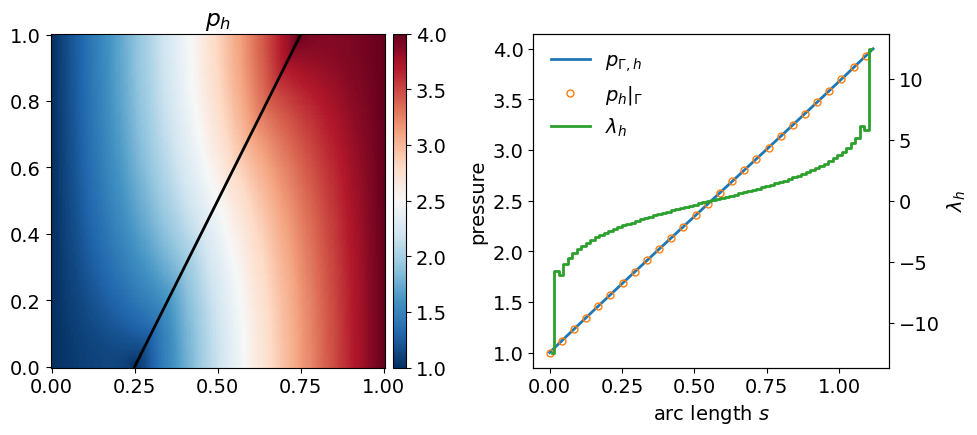

In [7]:
# ============================================================
# Pre-reconstruction visualization of the CG-LCG solution
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({"font.size": 14})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# (a) matrix pressure p_h over the domain, with the embedded fracture.
_nx = _ny = 160
_xg = np.linspace(xmin, xmax, _nx)
_yg = np.linspace(ymin, ymax, _ny)
_Xg, _Yg = np.meshgrid(_xg, _yg)
_P = eval_fem_function(p_m, np.column_stack([_Xg.ravel(), _Yg.ravel()]), omega).reshape(_ny, _nx)
_pc = axes[0].pcolormesh(_Xg, _Yg, _P, cmap="RdBu_r", shading="auto")
axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=2.0)
axes[0].set_aspect("equal")
axes[0].set_title(r"$p_h$")
_div = make_axes_locatable(axes[0])
_cax = _div.append_axes("right", size="4%", pad=0.08)
fig.colorbar(_pc, cax=_cax)

# (b) fracture pressure p_{Gamma,h}, matrix trace p_h|_Gamma, and multiplier lambda_h.
_sf = s_coord_np(V_f.tabulate_dof_coordinates()[:, :2])
_of = np.argsort(_sf)
_s_dense = np.linspace(0.0, L_gamma, 400)
_p_trace = eval_fem_function(p_m, real_points_np(_s_dense), omega).reshape(-1)
_sl = s_coord_np(V_l.tabulate_dof_coordinates()[:, :2])
_ol = np.argsort(_sl)

axL = axes[1]
h1, = axL.plot(_sf[_of], p_f.x.array[_of], "-", lw=2.0, color="tab:blue", label=r"$p_{\Gamma,h}$")
h2, = axL.plot(_s_dense, _p_trace, "o", ms=5, mfc="none", color="tab:orange", markevery=15, label=r"$p_h|_\Gamma$")
axL.set_xlabel(r"arc length $s$")
axL.set_ylabel("pressure")

axR = axL.twinx()
h3, = axR.step(_sl[_ol], lmbd.x.array[_ol], where="mid", lw=2.0, color="tab:green", label=r"$\lambda_h$")
axR.set_ylabel(r"$\lambda_h$")

axL.legend(handles=[h1, h2, h3], frameon=False, loc="best")
fig.tight_layout()
plt.show()


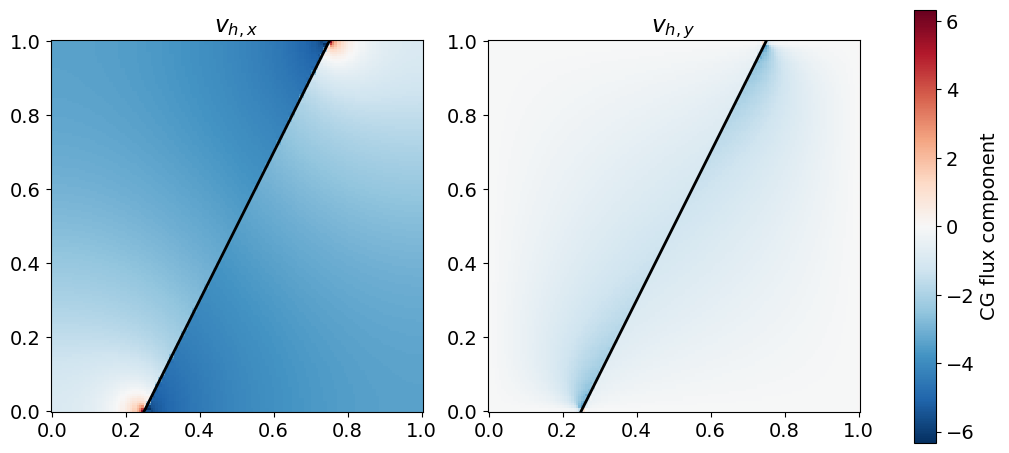

In [8]:
# Raw CG Darcy-flux components v_h = -k_m grad(p_h).
_nx_v = _ny_v = 160
_xv = np.linspace(xmin, xmax, _nx_v)
_yv = np.linspace(ymin, ymax, _ny_v)
_Xv, _Yv = np.meshgrid(_xv, _yv)
_Qv = q_cg_numpy(np.column_stack([_Xv.ravel(), _Yv.ravel()]))
v_h_x = _Qv[:, 0].reshape(_ny_v, _nx_v)
v_h_y = _Qv[:, 1].reshape(_ny_v, _nx_v)

_flux_vals = np.concatenate([v_h_x[np.isfinite(v_h_x)], v_h_y[np.isfinite(v_h_y)]])
_vlim = np.nanmax(np.abs(_flux_vals)) if _flux_vals.size else 1.0
if not np.isfinite(_vlim) or _vlim <= 0.0:
    _vlim = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], v_h_x, r"$v_{h,x}$"),
    (axes[1], v_h_y, r"$v_{h,y}$"),
]:
    _pc = ax.pcolormesh(_Xv, _Yv, vals, cmap="RdBu_r", shading="auto", vmin=-_vlim, vmax=_vlim)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=2.0)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(_pc, ax=axes.ravel().tolist(), label=r"CG flux component")
plt.show()


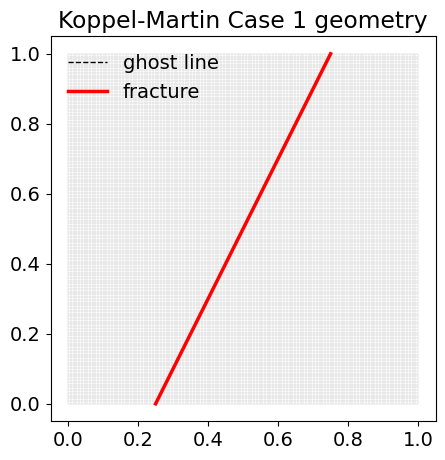

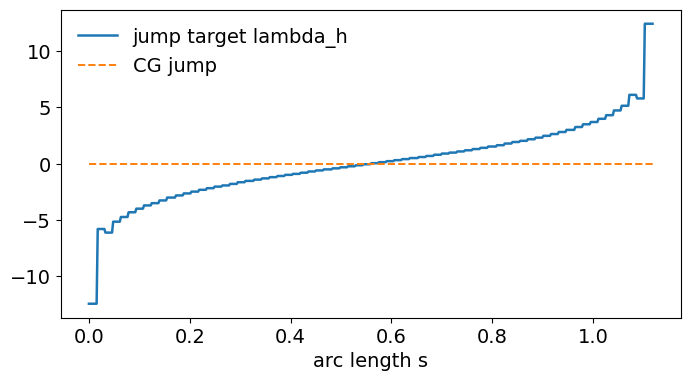

In [9]:
def cg_jump_on_fracture(s_query, eps=None):
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    if eps is None:
        eps = 0.00 * h_est
    pts = real_points_np(s_query)[:, :2]
    d_tip = np.minimum(s_query, L_gamma - s_query)
    eps_i = np.minimum(eps, 0.35 * np.maximum(d_tip, 1e-12))
    qp = q_cg_numpy(pts + eps_i[:, None] * normal_np[None, :])
    qm = q_cg_numpy(pts - eps_i[:, None] * normal_np[None, :])
    jump = np.sum((qp - qm) * normal_np[None, :], axis=1)
    return np.nan_to_num(jump, nan=0.0, posinf=0.0, neginf=0.0)

TARGET_MODE = "lambda_h"
N_REAL = max(160, 4 * max(1, len(gamma_facet_records)))
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)[:, :2]
x_ghost = ghost_points_np(n_each=max(80, N_REAL // 2))
lambda_target = lambda_h_on_s(s_real) if TARGET_MODE == "lambda_h" else cg_jump_on_fracture(s_real)

def tip_weight(s, tip_frac=TIP_FRAC):
    s = np.asarray(s, dtype=float)
    d = np.minimum(s, L_gamma - s)
    return np.clip(d / (tip_frac * L_gamma + 1e-30), 0.05, 1.0)

w_tip = tip_weight(s_real)

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_collection(LineCollection([np.vstack([p0, p1]) for p0, p1 in shadow_edges], colors="0.80", linewidths=0.35))
ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1.0, label="ghost line")
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.5, label="fracture")
ax.set_aspect("equal")
ax.legend(frameon=False)
ax.set_title("Koppel-Martin Case 1 geometry")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_real, lambda_target, lw=1.8, label="jump target lambda_h")
ax.plot(s_real, cg_jump_on_fracture(s_real), "--", lw=1.4, label="CG jump")
ax.set_xlabel("arc length s")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


In [10]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))
xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t = torch.tensor(tau_np, dtype=torch.float32, device=device)
normal_t = torch.tensor(normal_np, dtype=torch.float32, device=device)
frac_a_t = torch.tensor(FRAC_A, dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=32, num_hidden_layers=2).to(device)
q_minus_net = FluxNet(hidden_dim=32, num_hidden_layers=2).to(device)

def signed_distance_torch(x):
    return (x - frac_a_t) @ normal_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


In [11]:
# Optional R_xi fracture-conservation target on vertex-centered control volumes.
def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


def split_segment_at_partition_line(a, b, tol=1e-12):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    phi_a, phi_b = signed_distance_np(np.vstack([a, b]))
    cuts = [0.0, 1.0]
    if phi_a * phi_b < -tol ** 2:
        t = float(phi_a / (phi_a - phi_b))
        if tol < t < 1.0 - tol:
            cuts.append(t)
    cuts = np.array(sorted(cuts), dtype=float)
    return [(a + t0 * (b - a), a + t1 * (b - a)) for t0, t1 in zip(cuts[:-1], cuts[1:])]


def prepare_cv_rect_from_quad_mesh():
    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, poly in enumerate(cell_polys):
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        xy = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        cells.append({
            "xy": xy,
            "vids": np.array([get_vid(corner) for corner in xy], dtype=np.int32),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "cell_id": int(ci),
        })

    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)
    return {"cells": cells, "vertices_xy": vertices_xy, "vtc": vtc, "num_vertices": len(vertices_xy)}


def integrate_lambda_interval_signed(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_h_on_s(sq))
    return float(total)


def build_cv_quadrature_rect(cv_rect):
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    edge_points, edge_nw, edge_vids, edge_cell_ids = [], [], [], []
    source = np.zeros(cv_rect["num_vertices"], dtype=float)
    frac_source_abs = np.zeros(cv_rect["num_vertices"], dtype=float)

    for ci, cell in enumerate(cv_rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        cell_id = int(cell["cell_id"])
        for gi, vid in enumerate(cell["vids"]):
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            source_piece = 0.0
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_piece += integrate_lambda_interval_signed(s0, s1)
            source[int(vid)] += source_piece
            frac_source_abs[int(vid)] += abs(source_piece)

            for midp in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                for xa, xb in split_segment_at_partition_line(centroid, midp):
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1e-15:
                        continue
                    for t, w in zip(_G3, _W3):
                        x = xa + t * (xb - xa)
                        edge_points.append(x)
                        edge_nw.append(w * n_seg * seg_len)
                        edge_vids.append(int(vid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_vids": np.asarray(edge_vids, dtype=np.int64),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source_abs": frac_source_abs,
    }


def q_cg_cell_local_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float)
    cids = np.asarray(cell_ids, dtype=np.int32)
    out = np.zeros((pts.shape[0], 2), dtype=float)
    for cid in np.unique(cids):
        idx = np.nonzero(cids == cid)[0]
        bulk_cell = sol["bulk_data"]["cells"][int(cid)]
        uvals = p_m.x.array[bulk_cell["dofs"]]
        _, grads = q1_values_grads_on_cell(bulk_cell, pts[idx])
        grad = np.einsum("qad,a->qd", grads, uvals)
        out[idx] = -(K_M_VALUE) * grad
    return out


def compute_cg_cv_residual(data, num_vertices):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_cg = np.zeros(num_vertices, dtype=float)
    np.add.at(flux_cg, data["edge_vids"], flux_cg_q)
    return flux_cg - data["source"]


def compute_lce_for_vertices(cv_rect, data=None):
    data = build_cv_quadrature_rect(cv_rect) if data is None else data
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(cv_rect["num_vertices"], dtype=float)
    flux_rec = np.zeros(cv_rect["num_vertices"], dtype=float)
    np.add.at(flux_cg, data["edge_vids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_vids"], flux_rec_q)
    return data, flux_cg - data["source"], flux_rec - data["source"]


def boundary_vertex_mask_rect(cv_rect):
    xy = cv_rect["vertices_xy"]
    tol = 1e-12
    return (
        np.isclose(xy[:, 0], 0.0, atol=tol)
        | np.isclose(xy[:, 0], 1.0, atol=tol)
        | np.isclose(xy[:, 1], 0.0, atol=tol)
        | np.isclose(xy[:, 1], 1.0, atol=tol)
    )


def restrict_cv_quadrature_to_vertices(data, num_vertices, vertex_ids):
    vertex_ids = np.asarray(vertex_ids, dtype=np.int64)
    local_of_vertex = np.full(num_vertices, -1, dtype=np.int64)
    local_of_vertex[vertex_ids] = np.arange(len(vertex_ids), dtype=np.int64)
    local_edge_vids = local_of_vertex[data["edge_vids"]]
    keep = local_edge_vids >= 0
    return {
        "edge_points": data["edge_points"][keep],
        "edge_nw": data["edge_nw"][keep],
        "edge_vids": local_edge_vids[keep],
        "edge_cell_ids": data["edge_cell_ids"][keep],
        "source": data["source"][vertex_ids],
        "vertex_ids": vertex_ids,
    }


cv_rect = prepare_cv_rect_from_quad_mesh()
cv_data = build_cv_quadrature_rect(cv_rect)
is_bnd = boundary_vertex_mask_rect(cv_rect)
interior_vertex_ids = np.where(~is_bnd)[0]
R_cv_cg_pre = compute_cg_cv_residual(cv_data, cv_rect["num_vertices"])
frac_cv_ids = np.where((cv_data["frac_source_abs"] > 1e-14) & (~is_bnd))[0]
cv_frac_quad = restrict_cv_quadrature_to_vertices(cv_data, cv_rect["num_vertices"], frac_cv_ids)
N_cv_frac_cons = len(frac_cv_ids)
cv_frac_eq_pts_t = to_torch(cv_frac_quad["edge_points"])
cv_frac_eq_nw_t = to_torch(cv_frac_quad["edge_nw"])
cv_frac_eq_vids_t = torch.tensor(cv_frac_quad["edge_vids"], dtype=torch.long, device=device)
cv_frac_source_t = to_torch(cv_frac_quad["source"])
cv_frac_cg_res_np = R_cv_cg_pre[frac_cv_ids]
cv_frac_cg_res_t = to_torch(cv_frac_cg_res_np)
cv_frac_s_np = s_coord_np(cv_rect["vertices_xy"][frac_cv_ids]) if N_cv_frac_cons else np.zeros(0, dtype=float)
cv_frac_cons_tip_np = (cv_frac_s_np < TIP_FRAC * L_gamma) | (cv_frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
cv_frac_cons_int_np = ~cv_frac_cons_tip_np
cv_frac_cons_tip_t = torch.tensor(cv_frac_cons_tip_np, dtype=torch.bool, device=device)
cv_frac_cons_int_t = torch.tensor(cv_frac_cons_int_np, dtype=torch.bool, device=device)

print(f"fracture-cut CVs available for R_xi conservation loss: {N_cv_frac_cons}")


fracture-cut CVs available for R_xi conservation loss: 191


In [12]:
TRAINING_STAGE = "full"  # choose "matrix_only" or "full"
FRACTURE_CONS_TARGET = "R_tau"  # choose "R_tau" or "R_xi"
DATA_SAMPLE_MODE = "auto"  # "auto", "element_edge", "cv_edge", or "cell_interior"
if TRAINING_STAGE not in {"matrix_only", "full"}:
    raise ValueError("TRAINING_STAGE must be 'matrix_only' or 'full'")
if FRACTURE_CONS_TARGET not in {"R_tau", "R_xi"}:
    raise ValueError("FRACTURE_CONS_TARGET must be 'R_tau' or 'R_xi'")

N_PTS_PER_EDGE = 3
N_PTS_PER_CELL_AXIS = 2
N_DIV_PTS_PER_CV_AXIS = 2
DIV_R_XI_THRESHOLD = 1e-7
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15


def build_element_edge_data_points():
    xi = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    pts, cell_ids = [], []
    for cell_id, poly in enumerate(cell_polys):
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            for t in xi:
                pts.append(x0 + t * edge)
                cell_ids.append(cell_id)
    return np.asarray(pts, dtype=float), np.asarray(cell_ids, dtype=np.int32)


def build_cell_interior_data_points():
    xis = np.linspace(0.0, 1.0, N_PTS_PER_CELL_AXIS + 2)[1:-1]
    pts, cell_ids = [], []
    for cell_id, cell in enumerate(sol["bulk_data"]["cells"]):
        for xi in xis:
            for eta in xis:
                pts.append([
                    cell["x0"] + xi * cell["hx"],
                    cell["y0"] + eta * cell["hy"],
                ])
                cell_ids.append(cell_id)
    return np.asarray(pts, dtype=float), np.asarray(cell_ids, dtype=np.int32)


def build_cv_edge_data_points():
    return cv_data["edge_points"].copy(), cv_data["edge_cell_ids"].copy()


def resolve_data_sample_mode(mode, fracture_cons_target):
    if mode == "auto":
        return "cv_edge" if fracture_cons_target == "R_xi" else "element_edge"
    if mode not in {"element_edge", "cv_edge", "cell_interior"}:
        raise ValueError("DATA_SAMPLE_MODE must be 'auto', 'element_edge', 'cv_edge', or 'cell_interior'")
    return mode


DATA_SKELETON = resolve_data_sample_mode(DATA_SAMPLE_MODE, FRACTURE_CONS_TARGET)
if DATA_SKELETON == "element_edge":
    data_sample_pts, data_sample_cell_ids = build_element_edge_data_points()
elif DATA_SKELETON == "cv_edge":
    data_sample_pts, data_sample_cell_ids = build_cv_edge_data_points()
elif DATA_SKELETON == "cell_interior":
    data_sample_pts, data_sample_cell_ids = build_cell_interior_data_points()

phi_all = signed_distance_np(data_sample_pts)
Q_data_all = q_cg_cell_local_numpy(data_sample_pts, data_sample_cell_ids)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = data_sample_pts[valid]
Q_data = Q_data_all[valid]
X_data_cell_ids = data_sample_cell_ids[valid]
phi_data = phi_all[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

def bilinear_quad_sample_points(quad, n_axis):
    n_axis = int(n_axis)
    if n_axis < 1:
        raise ValueError("N_DIV_PTS_PER_CV_AXIS must be at least 1")
    xis = np.linspace(0.0, 1.0, n_axis + 2)[1:-1]
    pts = []
    x00, x10, x11, x01 = [np.asarray(p, dtype=float) for p in quad]
    for r in xis:
        for s in xis:
            pts.append((1.0 - r) * (1.0 - s) * x00 + r * (1.0 - s) * x10 + r * s * x11 + (1.0 - r) * s * x01)
    return pts


def build_cv_interior_div_points(cv_rect, vertex_ids, n_axis):
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    pts = []
    for vid in np.asarray(vertex_ids, dtype=np.int64):
        for ci in cv_rect["vtc"][int(vid)]:
            cell = cv_rect["cells"][int(ci)]
            loc = np.nonzero(cell["vids"] == int(vid))[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            quad = np.array([vi, mid_next, cell["centroid"], mid_prev], dtype=float)
            pts.extend(bilinear_quad_sample_points(quad, n_axis))
    if not pts:
        return np.zeros((0, 2), dtype=float)
    return np.asarray(pts, dtype=float)


if FRACTURE_CONS_TARGET == "R_xi":
    div_cv_candidate_ids = interior_vertex_ids.copy()
    div_cv_ids = div_cv_candidate_ids[np.abs(R_cv_cg_pre[div_cv_candidate_ids]) > DIV_R_XI_THRESHOLD]
    X_div = build_cv_interior_div_points(cv_rect, div_cv_ids, N_DIV_PTS_PER_CV_AXIS)
    div_collocation_label = f"R_xi-selected CV interiors: {len(div_cv_ids)} CVs, {N_DIV_PTS_PER_CV_AXIS}x{N_DIV_PTS_PER_CV_AXIS} points per CV subcell"
else:
    div_cv_ids = np.zeros(0, dtype=np.int64)
    X_div = cell_centroids.copy()
    div_collocation_label = "cell centroids"

if len(X_div) == 0:
    raise RuntimeError("No divergence collocation points were generated. Lower DIV_R_XI_THRESHOLD.")
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
div_idx_start_np = np.nonzero(div_mask)[0]
div_idx_final_np = np.nonzero(div_mask_final)[0]
if len(div_idx_start_np) == 0:
    raise RuntimeError("No divergence collocation points survived the start fracture-distance mask.")
if len(div_idx_final_np) == 0:
    div_idx_final_np = div_idx_start_np.copy()
X_div_t = to_torch(X_div)
F_div_t = torch.zeros(len(X_div), dtype=torch.float32, device=device)
div_idx_start_t = torch.tensor(div_idx_start_np, dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(div_idx_final_np, dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        centroid = poly.mean(axis=0)
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
            for q, w in zip(xi, wi):
                edge_points.append(x0 + q * edge)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
    return {
        "cell_ids": np.asarray(cell_ids, dtype=np.int32),
        "edge_points": np.asarray(edge_points),
        "edge_nw": np.asarray(edge_nw),
        "edge_cells": np.asarray(edge_cells, dtype=np.int64),
        "source": np.asarray(source),
        "cg_flux": np.asarray(cg_flux),
        "lambda_h_int": np.asarray(lambda_h_int),
        "local_id_of_cell": local_id_of_cell,
    }

_frac_cids = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t = to_torch(_frac_quad["edge_points"])
frac_eq_nw_t = to_torch(_frac_quad["edge_nw"])
frac_eq_cells_t = torch.tensor(_frac_quad["edge_cells"], dtype=torch.long, device=device)
frac_source_t = to_torch(_frac_quad["source"])
frac_lambda_t = to_torch(_frac_quad["lambda_h_int"])
frac_cg_res_np = _frac_quad["cg_flux"] - _frac_quad["source"] - _frac_quad["lambda_h_int"]
frac_cg_res_t = to_torch(frac_cg_res_np)
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)

print(f"training stage: {TRAINING_STAGE}")
print(f"fracture conservation target: {FRACTURE_CONS_TARGET}")
print(f"flux data mode: {DATA_SAMPLE_MODE} -> {DATA_SKELETON}")
print(f"flux data pool: {len(X_data)}")
print(f"data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", np.count_nonzero(data_mask), "->", np.count_nonzero(data_mask_final))
print(f"div collocation mode: {div_collocation_label}")
if FRACTURE_CONS_TARGET == "R_xi":
    print(f"div R_xi threshold: {DIV_R_XI_THRESHOLD:.1e}")
print("div collocation pool:", len(X_div))
print(f"div_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):", len(div_idx_start_np), "->", len(div_idx_final_np))
print(f"fracture-cut cells for conservation loss: {N_frac_cons}")


training stage: full
fracture conservation target: R_tau
flux data mode: auto -> element_edge
flux data pool: 196608
data_mask points (0.15h -> 1.15h): 196224 -> 192384
div collocation mode: cell centroids
div collocation pool: 16384
div_mask points (0.15h -> 1.15h): 16384 -> 16000
fracture-cut cells for conservation loss: 128


In [13]:
MATRIX_ONLY = TRAINING_STAGE == "matrix_only"
if TRAINING_STAGE not in {"matrix_only", "full"}:
    raise ValueError("TRAINING_STAGE must be 'matrix_only' or 'full'")
if FRACTURE_CONS_TARGET not in {"R_tau", "R_xi"}:
    raise ValueError("FRACTURE_CONS_TARGET must be 'R_tau' or 'R_xi'")
print("training stage:", TRAINING_STAGE)
print("fracture conservation target:", FRACTURE_CONS_TARGET)
print("flux data skeleton:", DATA_SKELETON)

W_DATA = 10.0
W_DIV = 1.0
W_CONS_INT = 0.0 if MATRIX_ONLY else 0.10
W_CONS_TIP = 0.0 if MATRIX_ONLY else 0.10
CONS_INT_BETA = 1.0
CONS_R_FLOOR = 1e-5
CONS_INT_GAMMA = 4.0
W_JUMP = 0.0 if MATRIX_ONLY else 1.0
W_GHOST = 0.0 if MATRIX_ONLY else 2.0
W_SLOPE = 1e-4

EPOCHS = 5000
if MATRIX_ONLY:
    CONS_RAMP_START = EPOCHS + 1
    CONS_RAMP_END = EPOCHS + 2
    BEST_START_EPOCH = int(0.8 * EPOCHS)
else:
    CONS_RAMP_START = int(1.0 * EPOCHS)
    CONS_RAMP_END = int(1.2 * EPOCHS)
    BEST_START_EPOCH = CONS_RAMP_END
BATCH_DATA = 8192
BATCH_DIV = 4096

optimizer_plus = torch.optim.Adam(q_plus_net.parameters(), lr=2e-3)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=2e-3)
scheduler_plus = torch.optim.lr_scheduler.MultiStepLR(optimizer_plus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(optimizer_minus, milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)], gamma=0.35)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(t):
    t = float(np.clip(t, 0.0, 1.0))
    return t * t * (3.0 - 2.0 * t)

def curriculum_for_epoch(epoch):
    t = (epoch - CONS_RAMP_START) / max(CONS_RAMP_END - CONS_RAMP_START, 1)
    ramp = smoothstep01(t)
    use_final_mask = epoch >= CONS_RAMP_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    return ramp, mask_factor, data_pool, div_pool

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)
    n_data_epoch = data_pool.numel()
    idx_d = data_pool[torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)]
    loss_data = mse(q_piecewise(X_data_t[idx_d]) - Q_data_t[idx_d])

    n_div_epoch = div_pool.numel()
    idx_v = div_pool[torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)]
    x_div_b = X_div_t[idx_v]
    side_b = side_div_t[idx_v]
    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b]
    Xm = x_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp))
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm))

    if FRACTURE_CONS_TARGET == "R_tau":
        q_edge = q_piecewise(frac_eq_pts_t)
        flux_q = torch.sum(q_edge * frac_eq_nw_t, dim=1)
        flux_K = torch.zeros(N_frac_cons, device=device)
        flux_K.scatter_add_(0, frac_eq_cells_t, flux_q)
        R_cons = flux_K - frac_source_t - frac_lambda_t
        R_cg_cons = frac_cg_res_t
        cons_int_t = frac_cons_int_t
        cons_tip_t = frac_cons_tip_t
    else:
        q_cv = q_piecewise(cv_frac_eq_pts_t)
        flux_q = torch.sum(q_cv * cv_frac_eq_nw_t, dim=1)
        flux_cv = torch.zeros(N_cv_frac_cons, device=device)
        if N_cv_frac_cons:
            flux_cv.scatter_add_(0, cv_frac_eq_vids_t, flux_q)
        R_cons = flux_cv - cv_frac_source_t
        R_cg_cons = cv_frac_cg_res_t
        cons_int_t = cv_frac_cons_int_t
        cons_tip_t = cv_frac_cons_tip_t

    loss_cons_frac = mse(R_cons) if R_cons.numel() > 0 else torch.tensor(0.0, device=device)

    loss_cons_int = torch.tensor(0.0, device=device)
    if cons_int_t.any().item():
        R_rec_int = R_cons[cons_int_t]
        R_cg_int = R_cg_cons[cons_int_t]
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        loss_cons_int = torch.mean((R_rec_int / denom) ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if cons_tip_t.any().item():
        loss_cons_tip = mse(R_cons[cons_tip_t])

    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)
    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 else torch.tensor(0.0, device=device)
    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA * loss_data
        + W_DIV * div_loss
        + cons_ramp * W_CONS_INT * loss_cons_int
        + cons_ramp * W_CONS_TIP * loss_cons_tip
        + W_JUMP * loss_jump
        + W_GHOST * loss_ghost
        + W_SLOPE * loss_slope
    )
    parts = {
        "data": loss_data.detach(),
        "div": div_loss.detach(),
        "cons_frac": loss_cons_frac.detach(),
        "cons_int": loss_cons_int.detach(),
        "cons_tip": loss_cons_tip.detach(),
        "jump": loss_jump.detach(),
        "ghost": loss_ghost.detach(),
        "slope": loss_slope.detach(),
        "cons_ramp": torch.tensor(cons_ramp, device=device),
        "mask_factor": torch.tensor(mask_factor, device=device),
    }
    return total, parts

history = []
best_state = None
best_loss = float("inf")
t0 = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    total, parts = compute_loss_terms(epoch)
    total.backward()
    torch.nn.utils.clip_grad_norm_(list(q_plus_net.parameters()) + list(q_minus_net.parameters()), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    row = {"epoch": epoch, "total": float(total.detach().cpu())}
    row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
    history.append(row)
    if epoch >= BEST_START_EPOCH and row["total"] < best_loss:
        best_loss = row["total"]
        best_state = {
            "plus": {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
            "minus": {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
            "epoch": epoch,
        }
    if epoch == 1 or epoch % 250 == 0:
        print(
            f"{epoch:6d} total={row['total']:.3e} ramp={row['cons_ramp']:.2f} "
            f"data={row['data']:.3e} div={row['div']:.3e} cons={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e}"
        )

if best_state is not None:
    q_plus_net.load_state_dict(best_state["plus"])
    q_minus_net.load_state_dict(best_state["minus"])
    print("restored best epoch:", best_state["epoch"], "loss:", best_loss)
print(f"training time: {time.perf_counter() - t0:.1f} s")


training stage: full
fracture conservation target: R_tau
flux data skeleton: element_edge
     1 total=6.154e+01 ramp=0.00 data=5.461e+00 div=1.366e-04 cons=8.642e-04 jump=6.928e+00 ghost=0.000e+00
   250 total=1.547e+00 ramp=0.00 data=8.496e-02 div=4.834e-02 cons=1.763e-04 jump=6.493e-01 ghost=0.000e+00
   500 total=6.047e-01 ramp=0.00 data=3.108e-02 div=6.672e-03 cons=1.007e-04 jump=2.872e-01 ghost=0.000e+00
   750 total=3.530e-01 ramp=0.00 data=1.679e-02 div=7.292e-03 cons=6.690e-05 jump=1.777e-01 ghost=0.000e+00
  1000 total=3.092e-01 ramp=0.00 data=1.621e-02 div=5.480e-03 cons=5.076e-05 jump=1.415e-01 ghost=0.000e+00
  1250 total=2.708e-01 ramp=0.00 data=1.411e-02 div=5.729e-03 cons=4.024e-05 jump=1.239e-01 ghost=0.000e+00
  1500 total=2.448e-01 ramp=0.00 data=1.202e-02 div=9.545e-03 cons=3.589e-05 jump=1.150e-01 ghost=0.000e+00
  1750 total=1.977e-01 ramp=0.00 data=8.316e-03 div=5.748e-03 cons=3.215e-05 jump=1.087e-01 ghost=0.000e+00
  2000 total=2.019e-01 ramp=0.00 data=9.423e-0

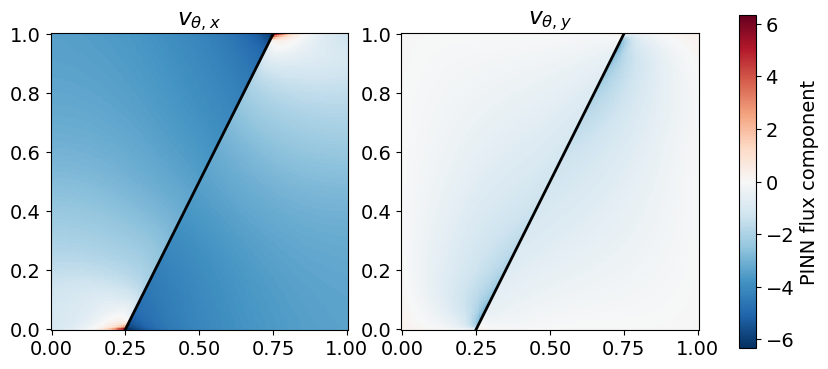

pointwise |v_theta - v_h| on element edges: {'mean': 0.040130520458892566, 'median': 0.01746044007345176, 'max': 9.123024329930972}


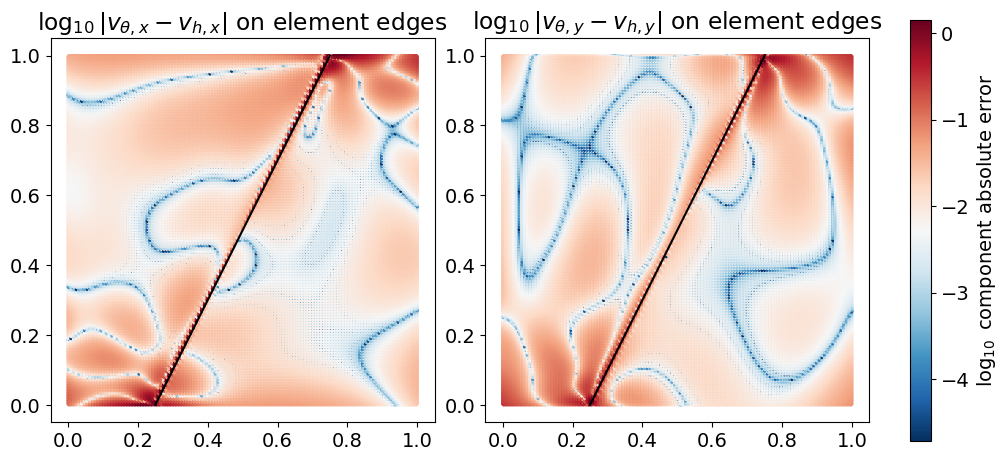

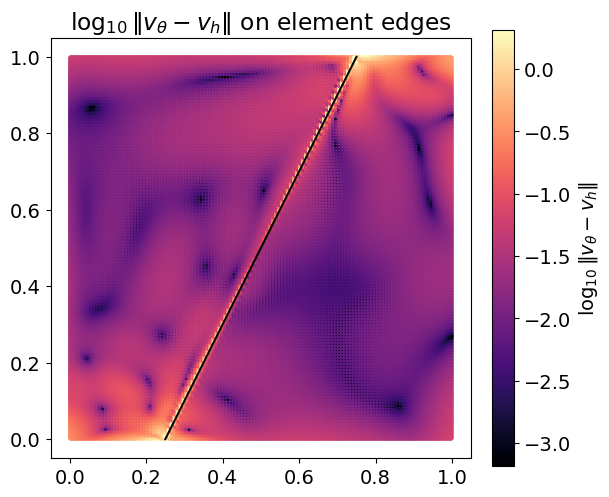

Ghost-partition PINN reconstruction:
  all CG : {'mean': 0.0001668248564783409, 'median': 0.0, 'max': 0.10866241886066262}
  all PINN: {'mean': 1.0437502674453439e-05, 'median': 1.3042590580880642e-06, 'max': 0.019025030647966165}
  fracture CG : {'mean': 0.021353581629227562, 'median': 0.016262252021739695, 'max': 0.10866241886066262}
  fracture PINN: {'mean': 0.0011158896719321962, 'median': 0.00018778450653070787, 'max': 0.019025030647966165}


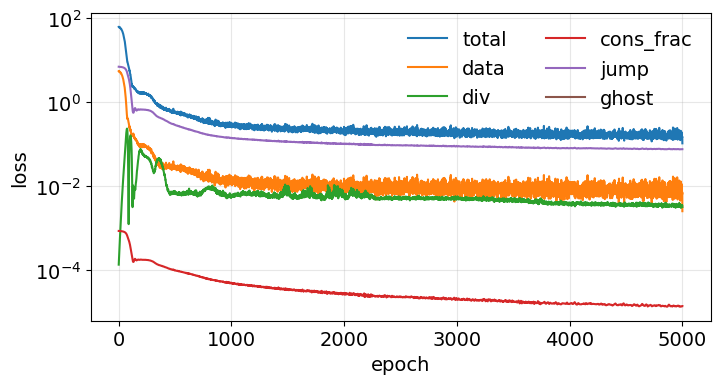

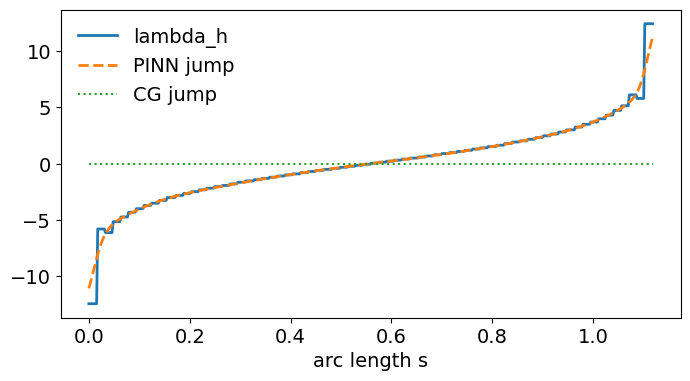

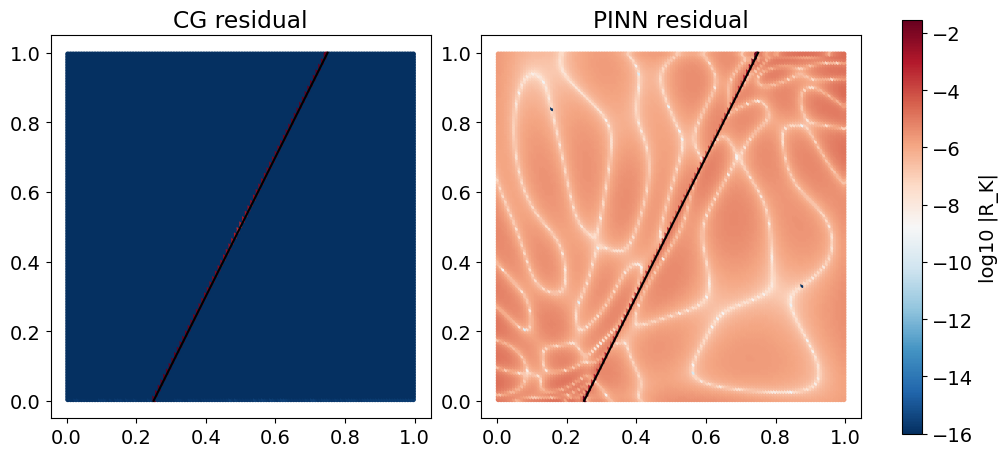

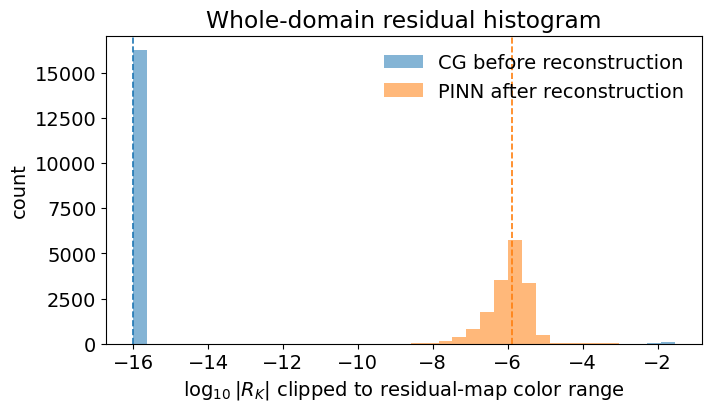

In [14]:
@torch.no_grad()
def q_rec_numpy(points, batch=200000):
    pts = np.asarray(points, dtype=float)
    out = []
    for i in range(0, len(pts), batch):
        xb = to_torch(pts[i:i + batch, :2])
        out.append(q_piecewise(xb).detach().cpu().numpy())
    return np.vstack(out) if out else np.zeros((0, 2))

@torch.no_grad()
def jump_rec_numpy(s):
    pts = real_points_np(s)[:, :2]
    xb = to_torch(pts)
    qp = q_plus(xb)
    qm = q_minus(xb)
    return torch.sum((qp - qm) * normal_t.reshape(1, 2), dim=1).detach().cpu().numpy()

# Reconstructed PINN Darcy-flux components v_theta.
_nx_theta = _ny_theta = 160
_x_theta = np.linspace(xmin, xmax, _nx_theta)
_y_theta = np.linspace(ymin, ymax, _ny_theta)
_Xtheta, _Ytheta = np.meshgrid(_x_theta, _y_theta)
_Qtheta = q_rec_numpy(np.column_stack([_Xtheta.ravel(), _Ytheta.ravel()]))
v_theta_x = _Qtheta[:, 0].reshape(_ny_theta, _nx_theta)
v_theta_y = _Qtheta[:, 1].reshape(_ny_theta, _nx_theta)

if "v_h_x" in globals() and "v_h_y" in globals():
    _theta_cg_vals = np.concatenate([v_h_x[np.isfinite(v_h_x)], v_h_y[np.isfinite(v_h_y)]])
else:
    _Qh_theta = q_cg_numpy(np.column_stack([_Xtheta.ravel(), _Ytheta.ravel()]))
    _theta_cg_vals = _Qh_theta[np.isfinite(_Qh_theta)]
_theta_vlim = np.nanmax(np.abs(_theta_cg_vals)) if _theta_cg_vals.size else 1.0
if not np.isfinite(_theta_vlim) or _theta_vlim <= 0.0:
    _theta_vlim = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], v_theta_x, r"$v_{\theta,x}$"),
    (axes[1], v_theta_y, r"$v_{\theta,y}$"),
]:
    _pc = ax.pcolormesh(_Xtheta, _Ytheta, vals, cmap="RdBu_r", shading="auto", vmin=-_theta_vlim, vmax=_theta_vlim)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=2.0)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(_pc, ax=axes.ravel().tolist(), label=r"PINN flux component")
plt.show()

if FRACTURE_CONS_TARGET == "R_xi":
    err_pts = cv_data["edge_points"].copy()
    err_cell_ids = cv_data["edge_cell_ids"].copy()
    err_skeleton_label = r"control-volume edges"
else:
    err_pts, err_cell_ids = build_element_edge_data_points()
    err_skeleton_label = r"element edges"

q_h_err = q_cg_cell_local_numpy(err_pts, err_cell_ids)
q_theta_err = q_rec_numpy(err_pts)
err_vec = q_theta_err - q_h_err
err_norm = np.linalg.norm(err_vec, axis=1)
valid_err = np.isfinite(err_norm)
print(f"pointwise |v_theta - v_h| on {err_skeleton_label}:", {
    "mean": float(np.mean(err_norm[valid_err])),
    "median": float(np.median(err_norm[valid_err])),
    "max": float(np.max(err_norm[valid_err])),
})

err_x = err_vec[:, 0]
err_y = err_vec[:, 1]
_err_log_x = np.log10(np.abs(err_x) + 1e-16)
_err_log_y = np.log10(np.abs(err_y) + 1e-16)
_err_comp_vals = np.concatenate([_err_log_x[valid_err], _err_log_y[valid_err]])
_err_comp_vmin, _err_comp_vmax = np.percentile(_err_comp_vals, [0.1, 99.9]) if _err_comp_vals.size else (-16.0, 0.0)
if not np.isfinite(_err_comp_vmin) or not np.isfinite(_err_comp_vmax) or _err_comp_vmin >= _err_comp_vmax:
    _err_comp_vmin = float(np.nanmin(_err_comp_vals)) if _err_comp_vals.size else -16.0
    _err_comp_vmax = float(np.nanmax(_err_comp_vals)) if _err_comp_vals.size else 0.0
    if _err_comp_vmin >= _err_comp_vmax:
        _err_comp_vmin, _err_comp_vmax = _err_comp_vmax - 1.0, _err_comp_vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], _err_log_x, r"$\log_{10}|v_{\theta,x}-v_{h,x}|$"),
    (axes[1], _err_log_y, r"$\log_{10}|v_{\theta,y}-v_{h,y}|$"),
]:
    _sc_comp = ax.scatter(
        err_pts[valid_err, 0], err_pts[valid_err, 1],
        c=vals[valid_err], s=1.5, cmap="RdBu_r", vmin=_err_comp_vmin, vmax=_err_comp_vmax, rasterized=True,
    )
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title + " on " + err_skeleton_label)
fig.colorbar(_sc_comp, ax=axes.ravel().tolist(), label=r"$\log_{10}$ component absolute error")
plt.show()

_err_log = np.log10(err_norm + 1e-16)
_err_vals = _err_log[valid_err]
_err_vmin, _err_vmax = np.percentile(_err_vals, [0.1, 99.9]) if _err_vals.size else (-16.0, 0.0)
if not np.isfinite(_err_vmin) or not np.isfinite(_err_vmax) or _err_vmin >= _err_vmax:
    _err_vmin = float(np.nanmin(_err_vals)) if _err_vals.size else -16.0
    _err_vmax = float(np.nanmax(_err_vals)) if _err_vals.size else 0.0
    if _err_vmin >= _err_vmax:
        _err_vmin, _err_vmax = _err_vmax - 1.0, _err_vmax

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
_sc = ax.scatter(
    err_pts[valid_err, 0], err_pts[valid_err, 1],
    c=_err_log[valid_err], s=1.5, cmap="magma", vmin=_err_vmin, vmax=_err_vmax, rasterized=True,
)
ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
ax.set_aspect("equal")
ax.set_title(r"$\log_{10}\Vert v_{\theta}-v_h\Vert$ on " + err_skeleton_label)
fig.colorbar(_sc, ax=ax, label=r"$\log_{10}\Vert v_{\theta}-v_h\Vert$")
plt.show()

def compute_lce_for_cells(cell_ids):
    data = build_edge_quadrature_for_cells(cell_ids)
    q_rec = q_rec_numpy(data["edge_points"])
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_rec = np.zeros(len(data["cell_ids"]), dtype=float)
    np.add.at(flux_rec, data["edge_cells"], flux_rec_q)
    flux_cg = data["cg_flux"].copy()
    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg = flux_cg - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells, dtype=np.int32)
diag_data, R_cg, R_rec = compute_lce_for_cells(all_cell_ids)
frac_cell_ids = np.unique([cid for cid, _, _, _ in gamma_facet_records]).astype(np.int32)

def residual_stats(vals, ids=None):
    vals = np.asarray(vals if ids is None else vals[ids], dtype=float)
    return {
        "mean": float(np.mean(np.abs(vals))),
        "median": float(np.median(np.abs(vals))),
        "max": float(np.max(np.abs(vals))),
    }

print("Ghost-partition PINN reconstruction:")
print("  all CG :", residual_stats(R_cg))
print("  all PINN:", residual_stats(R_rec))
print("  fracture CG :", residual_stats(R_cg, frac_cell_ids))
print("  fracture PINN:", residual_stats(R_rec, frac_cell_ids))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}
fig, ax = plt.subplots(figsize=(8, 4))
for key in ["total", "data", "div", "cons_frac", "jump", "ghost"]:
    ax.semilogy(hist["epoch"], hist[key], label=key)
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend(ncol=2, frameon=False)
ax.grid(True, which="both", alpha=0.3)
plt.show()

jump_rec = jump_rec_numpy(s_real)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_real, lambda_target, lw=2, label="lambda_h")
ax.plot(s_real, jump_rec, "--", lw=2, label="PINN jump")
ax.plot(s_real, cg_jump_on_fracture(s_real), ":", lw=1.5, label="CG jump")
ax.set_xlabel("arc length s")
ax.legend(frameon=False)
ax.grid(False)
plt.show()

eps = 1e-16
log_R_cg = np.log10(np.abs(R_cg) + eps)
log_R_rec = np.log10(np.abs(R_rec) + eps)
res_color_values = np.concatenate([log_R_cg[np.isfinite(log_R_cg)], log_R_rec[np.isfinite(log_R_rec)]])
res_vmin, res_vmax = np.percentile(res_color_values, [0.1, 99.9])
if not np.isfinite(res_vmin) or not np.isfinite(res_vmax) or res_vmin >= res_vmax:
    res_vmin = min(np.nanmin(log_R_cg), np.nanmin(log_R_rec))
    res_vmax = max(np.nanmax(log_R_cg), np.nanmax(log_R_rec))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], log_R_cg, "CG residual"),
    (axes[1], log_R_rec, "PINN residual"),
]:
    sc = ax.scatter(cell_centroids[:, 0], cell_centroids[:, 1], c=vals, s=8, cmap="RdBu_r", vmin=res_vmin, vmax=res_vmax)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="log10 |R_K|")
plt.show()

hist_vmin, hist_vmax = res_vmin, res_vmax
log_R_cg_hist = np.clip(log_R_cg[np.isfinite(log_R_cg)], hist_vmin, hist_vmax)
log_R_rec_hist = np.clip(log_R_rec[np.isfinite(log_R_rec)], hist_vmin, hist_vmax)
hist_bins = np.linspace(hist_vmin, hist_vmax, 40)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.hist(log_R_cg_hist, bins=hist_bins, alpha=0.55, color="C0", label="CG before reconstruction")
ax.hist(log_R_rec_hist, bins=hist_bins, alpha=0.55, color="C1", label="PINN after reconstruction")
ax.axvline(np.median(log_R_cg_hist), color="C0", ls="--", lw=1.2)
ax.axvline(np.median(log_R_rec_hist), color="C1", ls="--", lw=1.2)
ax.set_xlabel(r"$\log_{10}|R_K|$ clipped to residual-map color range")
ax.set_ylabel("count")
ax.set_title(r"Whole-domain residual histogram")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


Interior control-volume residual R_xi
  CG  : {'mean': 2.0452415171444268e-05, 'median': 4.506842199241377e-09, 'max': 0.007972975565354763}
  PINN: {'mean': 8.605022725168191e-06, 'median': 1.2918866963892712e-06, 'max': 0.01430563243890607}
Fracture-cut interior control-volume residual R_xi
  CG  : {'mean': 0.0008491345156498039, 'median': 0.00021570699474979943, 'max': 0.007972975565354763}
  PINN: {'mean': 0.000585698129738019, 'median': 0.00014442241755670444, 'max': 0.01430563243890607}


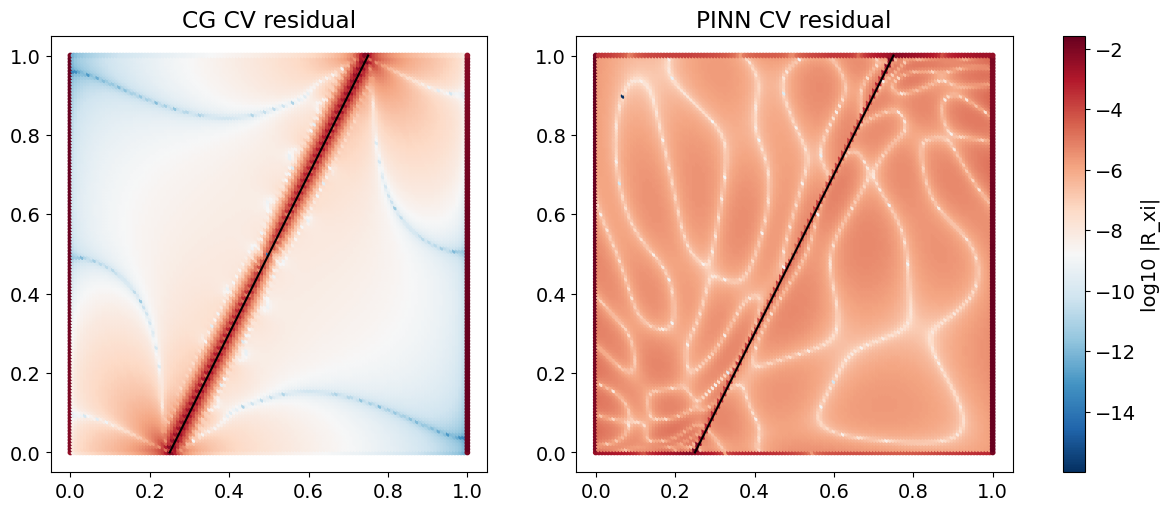

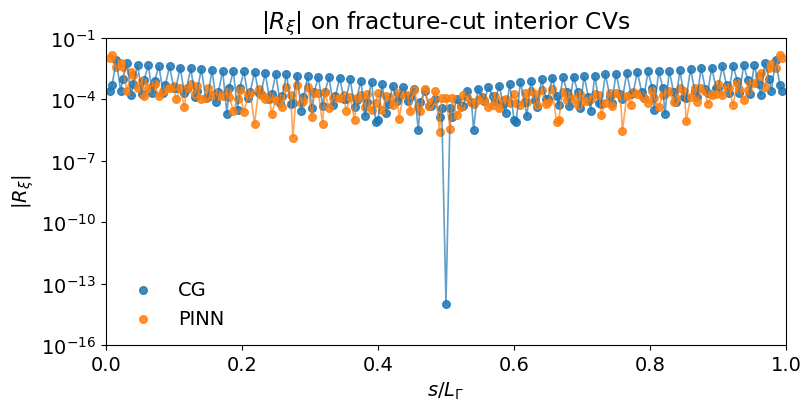

In [15]:
# R_xi diagnostic on vertex-centered control volumes.
cv_data, R_cv_cg, R_cv_rec = compute_lce_for_vertices(cv_rect, cv_data)
frac_cv_ids = np.where((cv_data["frac_source_abs"] > 1e-14) & (~is_bnd))[0]

print("Interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, interior_vertex_ids))
print("  PINN:", residual_stats(R_cv_rec, interior_vertex_ids))
print("Fracture-cut interior control-volume residual R_xi")
print("  CG  :", residual_stats(R_cv_cg, frac_cv_ids))
print("  PINN:", residual_stats(R_cv_rec, frac_cv_ids))

xyv = cv_rect["vertices_xy"]
_rx = np.log10(np.abs(np.concatenate([R_cv_cg, R_cv_rec])) + eps)
_vmin, _vmax = float(_rx.min()), float(_rx.max())
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], R_cv_cg, "CG CV residual"),
    (axes[1], R_cv_rec, "PINN CV residual"),
]:
    sc = ax.scatter(
        xyv[:, 0], xyv[:, 1],
        c=np.log10(np.abs(vals) + eps), s=10, cmap="RdBu_r", vmin=_vmin, vmax=_vmax,
    )
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.colorbar(sc, ax=axes.ravel().tolist(), label="log10 |R_xi|")
plt.show()

if len(frac_cv_ids):
    s_cv = ((xyv[frac_cv_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    cv_order = np.argsort(s_cv)
    s_cv = s_cv[cv_order]
    cut_Rxi_cg = np.abs(R_cv_cg[frac_cv_ids][cv_order]) + eps
    cut_Rxi_rec = np.abs(R_cv_rec[frac_cv_ids][cv_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_cv, cut_Rxi_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_cv, cut_Rxi_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_cv, cut_Rxi_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_cv, cut_Rxi_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel(r"$s/L_\Gamma$")
    ax.set_ylabel(r"$|R_\xi|$")
    ax.set_title(r"$|R_\xi|$ on fracture-cut interior CVs")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut interior CVs were found.")


Shifted rectangular transport-CV residual R_C
  rectangles: 16641
  Hx=0.0078125, Hy=0.0078125, shift=(0.00242187, 0.00367187)
  CG  : {'mean': 8.810155571602887e-05, 'median': 5.150525893456159e-07, 'max': 0.03848443467261001}
  PINN: {'mean': 9.173883495088243e-06, 'median': 1.2864103161721804e-06, 'max': 0.021921095485907677}
Fracture-cut shifted rectangular transport-CV residual R_C
  CG  : {'mean': 0.00605368490909406, 'median': 0.0038272796184603986, 'max': 0.03848443467261001}
  PINN: {'mean': 0.000645926869826152, 'median': 0.00012489769847048073, 'max': 0.021921095485907677}


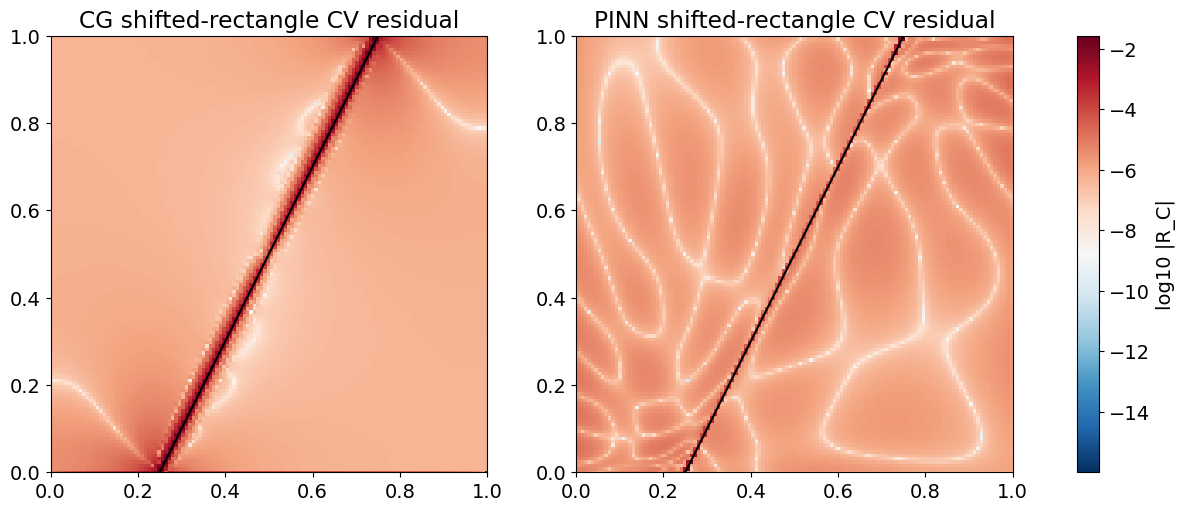

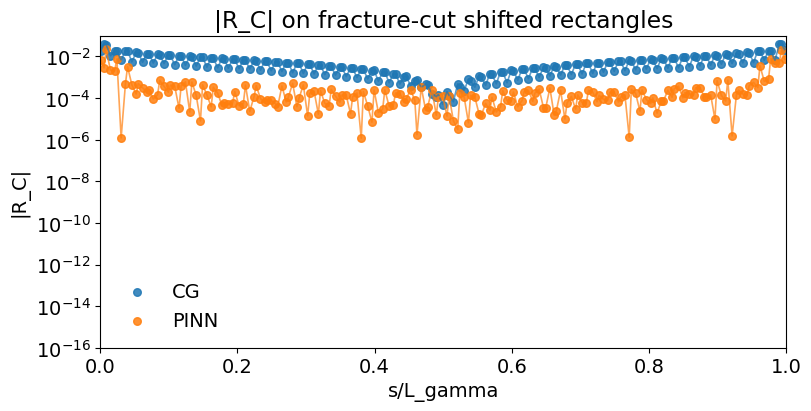

In [16]:
# Shifted rectangular transport-grid CV diagnostic.
from matplotlib.collections import PolyCollection

# User inputs. Edit these values directly before running this cell.
SHIFTED_RECT_H = 2.0 * h_est
SHIFTED_RECT_HX = 1.0 * h_est
SHIFTED_RECT_HY = 1.0 * h_est
SHIFTED_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
SHIFTED_RECT_SHIFT_X = float(SHIFTED_RECT_SHIFT_FRACTION[0] * SHIFTED_RECT_HX)
SHIFTED_RECT_SHIFT_Y = float(SHIFTED_RECT_SHIFT_FRACTION[1] * SHIFTED_RECT_HY)
SHIFTED_RECT_EDGE_NQ = 4
SHIFTED_RECT_SOURCE_NQ = 3
SHIFTED_RECT_MIN_AREA = 1.0e-14
SHIFTED_RECT_CMAP = "RdBu_r"
# Default: inherit the same log-color limits as the preceding R_xi plot.
# Override with SHIFTED_RECT_LOG_CLIM=(vmin, vmax) if needed.
SHIFTED_RECT_LOG_CLIM = None


def _legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def shifted_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    lo = float(lo)
    hi = float(hi)
    H = float(H)
    if H <= 0.0:
        raise ValueError("The shifted-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [lo, hi]
    x = lo + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_shifted_rectangles():
    x_lines = shifted_rect_grid_lines(xmin, xmax, SHIFTED_RECT_HX, SHIFTED_RECT_SHIFT_X)
    y_lines = shifted_rect_grid_lines(ymin, ymax, SHIFTED_RECT_HY, SHIFTED_RECT_SHIFT_Y)
    rects, centers, areas = [], [], []
    for x0, x1 in zip(x_lines[:-1], x_lines[1:]):
        for y0, y1 in zip(y_lines[:-1], y_lines[1:]):
            area = float((x1 - x0) * (y1 - y0))
            if area <= SHIFTED_RECT_MIN_AREA:
                continue
            rects.append(np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float))
            centers.append([0.5 * (x0 + x1), 0.5 * (y0 + y1)])
            areas.append(area)
    return np.asarray(rects, dtype=float), np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def integrate_source_rectangle(poly):
    if SHIFTED_RECT_SOURCE_NQ <= 0:
        return 0.0
    xi, wi = _legendre_01(SHIFTED_RECT_SOURCE_NQ)
    x0, y0 = poly[0]
    x1, y1 = poly[2]
    pts, weights = [], []
    for i, qx in enumerate(xi):
        for j, qy in enumerate(xi):
            pts.append([x0 + qx * (x1 - x0), y0 + qy * (y1 - y0)])
            weights.append(wi[i] * wi[j] * (x1 - x0) * (y1 - y0))
    return float(np.sum(f_numpy(np.asarray(pts, dtype=float)) * np.asarray(weights, dtype=float)))


def integrate_lambda_polygon_signed(poly):
    total = 0.0
    total_abs = 0.0
    for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(poly)):
        piece = integrate_lambda_interval_signed(s0, s1)
        total += piece
        total_abs += abs(piece)
    return float(total), float(total_abs)


def build_shifted_rect_cv_quadrature(rects):
    edge_q, edge_w = _legendre_01(SHIFTED_RECT_EDGE_NQ)
    edge_points, edge_nw, edge_rect_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(rects), dtype=float)
    frac_source = np.zeros(len(rects), dtype=float)
    frac_source_abs = np.zeros(len(rects), dtype=float)

    for rid, poly in enumerate(rects):
        source[rid] = integrate_source_rectangle(poly)
        frac_source[rid], frac_source_abs[rid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa0 = x0 + a * edge
                xb0 = x0 + b * edge
                for xa, xb in split_segment_at_partition_line(xa0, xb0):
                    seg = xb - xa
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1.0e-15:
                        continue
                    n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                    cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                    for q, w in zip(edge_q, edge_w):
                        edge_points.append(xa + q * seg)
                        edge_nw.append(w * n_len)
                        edge_rect_ids.append(int(rid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_rect_ids": np.asarray(edge_rect_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_shifted_rect_residuals(data, n_rects):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_rects, dtype=float)
    flux_rec = np.zeros(n_rects, dtype=float)
    np.add.at(flux_cg, data["edge_rect_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_rect_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


shifted_rect_polys, shifted_rect_centers, shifted_rect_areas = build_shifted_rectangles()
shifted_rect_data = build_shifted_rect_cv_quadrature(shifted_rect_polys)
R_shifted_rect_cg, R_shifted_rect_rec = compute_shifted_rect_residuals(shifted_rect_data, len(shifted_rect_polys))
shifted_rect_frac_ids = np.where(shifted_rect_data["frac_source_abs"] > 1.0e-14)[0]

print("Shifted rectangular transport-CV residual R_C")
print(f"  rectangles: {len(shifted_rect_polys)}")
print(f"  Hx={SHIFTED_RECT_HX:.6g}, Hy={SHIFTED_RECT_HY:.6g}, shift=({SHIFTED_RECT_SHIFT_X:.6g}, {SHIFTED_RECT_SHIFT_Y:.6g})")
print("  CG  :", residual_stats(R_shifted_rect_cg))
print("  PINN:", residual_stats(R_shifted_rect_rec))
if len(shifted_rect_frac_ids):
    print("Fracture-cut shifted rectangular transport-CV residual R_C")
    print("  CG  :", residual_stats(R_shifted_rect_cg, shifted_rect_frac_ids))
    print("  PINN:", residual_stats(R_shifted_rect_rec, shifted_rect_frac_ids))

log_shift_cg = np.log10(np.abs(R_shifted_rect_cg) + eps)
log_shift_rec = np.log10(np.abs(R_shifted_rect_rec) + eps)
if SHIFTED_RECT_LOG_CLIM is None:
    if "_vmin" in globals() and "_vmax" in globals():
        _rvmin, _rvmax = float(_vmin), float(_vmax)
    elif "R_cv_cg" in globals() and "R_cv_rec" in globals():
        _rxi_vals = np.log10(np.abs(np.concatenate([R_cv_cg, R_cv_rec])) + eps)
        _rvmin, _rvmax = float(_rxi_vals.min()), float(_rxi_vals.max())
    else:
        _vals = np.concatenate([log_shift_cg[np.isfinite(log_shift_cg)], log_shift_rec[np.isfinite(log_shift_rec)]])
        _rvmin, _rvmax = np.percentile(_vals, [0.1, 99.9])
else:
    _rvmin, _rvmax = map(float, SHIFTED_RECT_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, vals, title in [
    (axes[0], log_shift_cg, "CG shifted-rectangle CV residual"),
    (axes[1], log_shift_rec, "PINN shifted-rectangle CV residual"),
]:
    pc = PolyCollection(shifted_rect_polys, edgecolors="none", linewidths=0.0, cmap=SHIFTED_RECT_CMAP)
    pc.set_array(vals)
    pc.set_clim(_rvmin, _rvmax)
    ax.add_collection(pc)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(pc, ax=axes.ravel().tolist(), label="log10 |R_C|")
plt.show()

if len(shifted_rect_frac_ids):
    s_rect = ((shifted_rect_centers[shifted_rect_frac_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    rect_order = np.argsort(s_rect)
    s_rect = s_rect[rect_order]
    cut_Rc_cg = np.abs(R_shifted_rect_cg[shifted_rect_frac_ids][rect_order]) + eps
    cut_Rc_rec = np.abs(R_shifted_rect_rec[shifted_rect_frac_ids][rect_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_rect, cut_Rc_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_rect, cut_Rc_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_rect, cut_Rc_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_rect, cut_Rc_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel("s/L_gamma")
    ax.set_ylabel("|R_C|")
    ax.set_title("|R_C| on fracture-cut shifted rectangles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut shifted rectangles were found.")


Rotated rectangular transport-CV residual R_C
  rectangles: 16744
  angle=45 deg, Hu=0.0078125, Hv=0.0078125, shift=(0.00242187, 0.00367187)
  CG  : {'mean': 0.00012647506950527659, 'median': 1.3323374745388998e-05, 'max': 0.04771616576696102}
  PINN: {'mean': 1.0533236821540562e-05, 'median': 1.2740123585697357e-06, 'max': 0.02521629836099394}
Fracture-cut rotated rectangular transport-CV residual R_C
  CG  : {'mean': 0.005887256246117148, 'median': 0.003291884688518999, 'max': 0.04771616576696102}
  PINN: {'mean': 0.0008151255084783603, 'median': 9.93104600702508e-05, 'max': 0.02521629836099394}


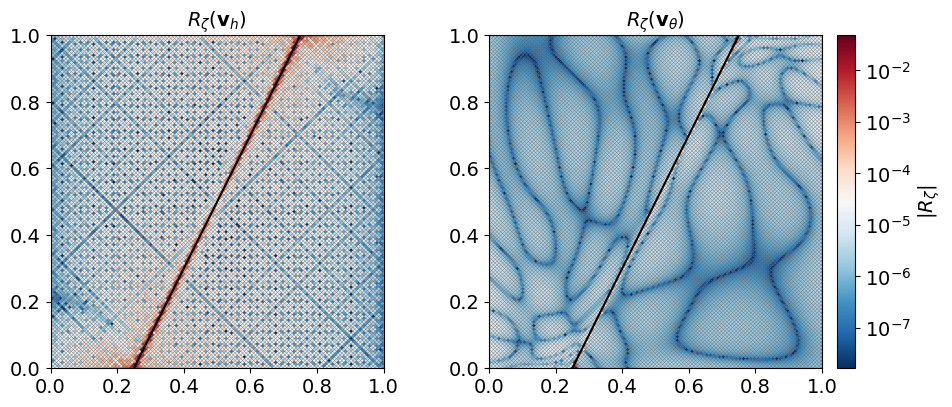

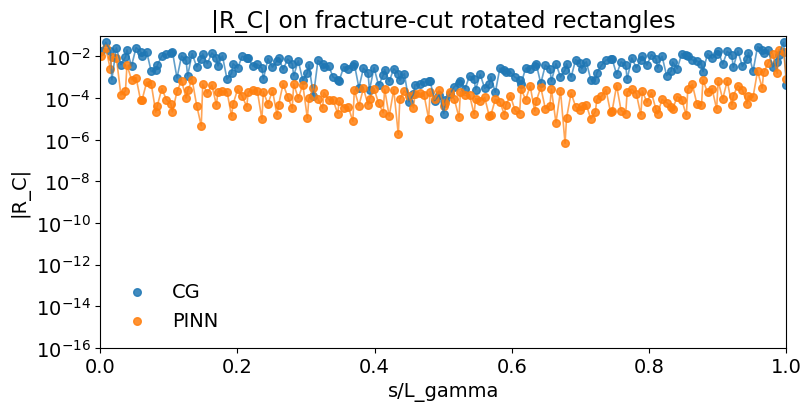

In [17]:
# Rotated rectangular transport-grid CV diagnostic.
# User inputs. Edit these values directly before running this cell.
ROT_RECT_ANGLE_DEG = 45.0
ROT_RECT_HU = 1.0 * h_est
ROT_RECT_HV = 1.0 * h_est
ROT_RECT_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
ROT_RECT_SHIFT_U = float(ROT_RECT_SHIFT_FRACTION[0] * ROT_RECT_HU)
ROT_RECT_SHIFT_V = float(ROT_RECT_SHIFT_FRACTION[1] * ROT_RECT_HV)
ROT_RECT_EDGE_NQ = 4
ROT_RECT_SOURCE_NQ = 3
ROT_RECT_MIN_AREA = 1.0e-14
ROT_RECT_CMAP = "RdBu_r"
ROT_RECT_OUTLINE_COLOR = "0.25"
ROT_RECT_OUTLINE_WIDTH = 0.15
# Default: autoscale from this rotated R_C data. Set a tuple to override.
ROT_RECT_LOG_CLIM = None


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [
        (0, xmin, False),
        (0, xmax, True),
        (1, ymin, False),
        (1, ymax, True),
    ]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def integrate_source_polygon(poly):
    if ROT_RECT_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if ROT_RECT_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def rotated_rect_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-rectangle CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_rectangles():
    theta = np.deg2rad(ROT_RECT_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = rotated_rect_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), ROT_RECT_HU, ROT_RECT_SHIFT_U)
    v_lines = rotated_rect_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), ROT_RECT_HV, ROT_RECT_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= ROT_RECT_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def build_rotated_rect_cv_quadrature(polys):
    edge_q, edge_w = _legendre_01(ROT_RECT_EDGE_NQ)
    edge_points, edge_nw, edge_rect_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for rid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[rid] = integrate_source_polygon(poly)
        frac_source[rid], frac_source_abs[rid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa0 = x0 + a * edge
                xb0 = x0 + b * edge
                for xa, xb in split_segment_at_partition_line(xa0, xb0):
                    seg = xb - xa
                    seg_len = edge_length(xa, xb)
                    if seg_len <= 1.0e-15:
                        continue
                    n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                    cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                    for q, w in zip(edge_q, edge_w):
                        edge_points.append(xa + q * seg)
                        edge_nw.append(w * n_len)
                        edge_rect_ids.append(int(rid))
                        edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_rect_ids": np.asarray(edge_rect_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_rotated_rect_residuals(data, n_rects):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_rects, dtype=float)
    flux_rec = np.zeros(n_rects, dtype=float)
    np.add.at(flux_cg, data["edge_rect_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_rect_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()
rotated_rect_poly_counts = np.asarray([len(poly) for poly in rotated_rect_polys], dtype=np.int32)
rotated_rect_max_vertices = int(rotated_rect_poly_counts.max()) if len(rotated_rect_poly_counts) else 0
rotated_rect_polys_padded = np.full((len(rotated_rect_polys), rotated_rect_max_vertices, 2), np.nan, dtype=float)
for _rid, _poly in enumerate(rotated_rect_polys):
    rotated_rect_polys_padded[_rid, :len(_poly), :] = _poly
rotated_rect_data = build_rotated_rect_cv_quadrature(rotated_rect_polys)
R_rotated_rect_cg, R_rotated_rect_rec = compute_rotated_rect_residuals(rotated_rect_data, len(rotated_rect_polys))
rotated_rect_frac_ids = np.where(rotated_rect_data["frac_source_abs"] > 1.0e-14)[0]

print("Rotated rectangular transport-CV residual R_C")
print(f"  rectangles: {len(rotated_rect_polys)}")
print(f"  angle={ROT_RECT_ANGLE_DEG:.6g} deg, Hu={ROT_RECT_HU:.6g}, Hv={ROT_RECT_HV:.6g}, shift=({ROT_RECT_SHIFT_U:.6g}, {ROT_RECT_SHIFT_V:.6g})")
print("  CG  :", residual_stats(R_rotated_rect_cg))
print("  PINN:", residual_stats(R_rotated_rect_rec))
if len(rotated_rect_frac_ids):
    print("Fracture-cut rotated rectangular transport-CV residual R_C")
    print("  CG  :", residual_stats(R_rotated_rect_cg, rotated_rect_frac_ids))
    print("  PINN:", residual_stats(R_rotated_rect_rec, rotated_rect_frac_ids))

log_rot_cg = np.log10(np.abs(R_rotated_rect_cg) + eps)
log_rot_rec = np.log10(np.abs(R_rotated_rect_rec) + eps)
if ROT_RECT_LOG_CLIM is None:
    _vals = np.concatenate([log_rot_cg[np.isfinite(log_rot_cg)], log_rot_rec[np.isfinite(log_rot_rec)]])
    _rot_vmin = float(np.percentile(_vals, 1.0))
    _rot_vmax = float(_vals.max())
    if not np.isfinite(_rot_vmin) or not np.isfinite(_rot_vmax) or _rot_vmin >= _rot_vmax:
        _rot_vmin, _rot_vmax = -16.0, -1.0
else:
    _rot_vmin, _rot_vmax = map(float, ROT_RECT_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], log_rot_cg, r"$R_\zeta(\mathbf{v}_h)$"),
    (axes[1], log_rot_rec, r"$R_\zeta(\mathbf{v}_\theta)$"),
]:
    pc = PolyCollection(
        rotated_rect_polys,
        edgecolors=ROT_RECT_OUTLINE_COLOR,
        linewidths=ROT_RECT_OUTLINE_WIDTH,
        cmap=ROT_RECT_CMAP,
    )
    pc.set_array(vals)
    pc.set_clim(_rot_vmin, _rot_vmax)
    ax.add_collection(pc)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(False)
fig.canvas.draw()
_axpos = axes[1].get_position()
_cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
cbar = fig.colorbar(pc, cax=_cax)
cbar.set_label(r"$|R_\zeta|$", fontsize=14)
_tick_lo = int(np.floor(_rot_vmin))
_tick_hi = int(np.ceil(_rot_vmax))
_cb_ticks = np.arange(_tick_lo, _tick_hi + 1, 1)
_cb_ticks = _cb_ticks[(_cb_ticks >= _rot_vmin) & (_cb_ticks <= _rot_vmax)]
if len(_cb_ticks) == 0:
    _cb_ticks = np.array([_rot_vmin, _rot_vmax])
cbar.set_ticks(_cb_ticks)
cbar.set_ticklabels([rf"$10^{{{int(t)}}}$" for t in _cb_ticks])
cbar.ax.tick_params(labelsize=14)
plt.show()

if len(rotated_rect_frac_ids):
    s_rot = ((rotated_rect_centers[rotated_rect_frac_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
    rot_order = np.argsort(s_rot)
    s_rot = s_rot[rot_order]
    cut_Rc_rot_cg = np.abs(R_rotated_rect_cg[rotated_rect_frac_ids][rot_order]) + eps
    cut_Rc_rot_rec = np.abs(R_rotated_rect_rec[rotated_rect_frac_ids][rot_order]) + eps

    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.plot(s_rot, cut_Rc_rot_cg, lw=1.2, alpha=0.7, color="C0")
    ax.plot(s_rot, cut_Rc_rot_rec, lw=1.2, alpha=0.7, color="C1")
    ax.scatter(s_rot, cut_Rc_rot_cg, s=30, alpha=0.85, color="C0", label="CG")
    ax.scatter(s_rot, cut_Rc_rot_rec, s=30, alpha=0.85, color="C1", label="PINN")
    ax.set_xlabel("s/L_gamma")
    ax.set_ylabel("|R_C|")
    ax.set_title("|R_C| on fracture-cut rotated rectangles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(1e-16, 1e-1)
    ax.set_yscale("log")
    ax.legend(frameon=False)
    ax.grid(False)
    plt.show()
else:
    print("No fracture-cut rotated rectangles were found.")


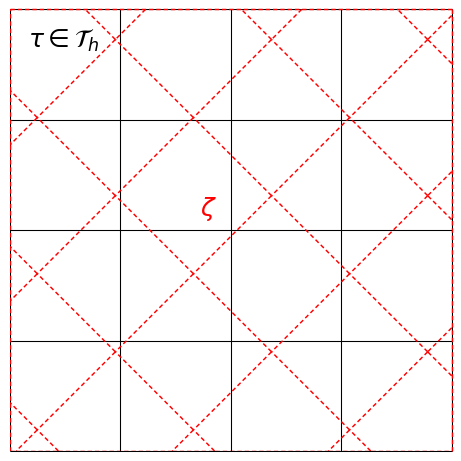

In [19]:
from matplotlib.collections import LineCollection

# Geometry-only visualization of the independent rotated CV grid eta over primal mesh tau.
ROT_CV_GEOM_WINDOW = (0.0, 4.0 * h_est, 0.0, 4.0 * h_est)  # xmin, xmax, ymin, ymax
ROT_CV_GEOM_FONTSIZE = 18
ROT_CV_GEOM_FIGSIZE = (4.5, 4.5)

_x0, _x1, _y0, _y1 = ROT_CV_GEOM_WINDOW

def _poly_intersects_window(poly, x0, x1, y0, y1):
    poly = np.asarray(poly, dtype=float)
    return (
        (poly[:, 0].max() >= x0) and (poly[:, 0].min() <= x1)
        and (poly[:, 1].max() >= y0) and (poly[:, 1].min() <= y1)
    )

# Primal mesh tau edges in the selected window.
_tau_segments = []
for poly in cell_polys:
    if not _poly_intersects_window(poly, _x0, _x1, _y0, _y1):
        continue
    for j in range(len(poly)):
        _tau_segments.append([poly[j], poly[(j + 1) % len(poly)]])

# Rotated CV eta polygons in the selected window.
_eta_polys = [
    poly for poly in rotated_rect_polys
    if _poly_intersects_window(poly, _x0, _x1, _y0, _y1)
]

fig, ax = plt.subplots(figsize=ROT_CV_GEOM_FIGSIZE, constrained_layout=True)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
_eta_dash_style = (0, (3.0, 2.0))

ax.add_collection(LineCollection(_tau_segments, colors="k", linewidths=0.75, zorder=2))

_eta_segments = []
_eta_seen_edges = set()
_eta_key_decimals = 12
for poly in _eta_polys:
    for j in range(len(poly)):
        p0 = np.asarray(poly[j], dtype=float)
        p1 = np.asarray(poly[(j + 1) % len(poly)], dtype=float)
        k0 = tuple(np.round(p0, _eta_key_decimals))
        k1 = tuple(np.round(p1, _eta_key_decimals))
        eta_edge_key = tuple(sorted((k0, k1)))
        if eta_edge_key in _eta_seen_edges:
            continue
        _eta_seen_edges.add(eta_edge_key)
        _eta_segments.append([p0, p1])

_eta_lines = LineCollection(
    _eta_segments,
    colors="red",
    linewidths=1.05,
    linestyles=_eta_dash_style,
    zorder=3,
)
ax.add_collection(_eta_lines)
_dx = _x1 - _x0
_dy = _y1 - _y0

# Keep the primal/window boundary visible behind dashed CV-boundary strokes.
_primal_boundary_segments = [
    [[_x0, _y0], [_x1, _y0]],
    [[_x1, _y0], [_x1, _y1]],
    [[_x1, _y1], [_x0, _y1]],
    [[_x0, _y1], [_x0, _y0]],
]
_primal_boundary = LineCollection(_primal_boundary_segments, colors="k", linewidths=0.75, zorder=2.8)
_primal_boundary.set_clip_on(False)
ax.add_collection(_primal_boundary)

# Complete the displayed boundary of retained cut CVs on the cropped top/right sides.
ax.plot([_x0, _x1], [_y1, _y1], color="red", lw=1.05, ls=_eta_dash_style, zorder=3.5, clip_on=False)
ax.plot([_x1, _x1], [_y0, _y1], color="red", lw=1.05, ls=_eta_dash_style, zorder=3.5, clip_on=False)

ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=0.9, zorder=4)

ax.text(
    _x0 + 0.04 * _dx, _y1 - 0.04 * _dy,
    r"$\tau\in\mathcal{T}_h$", fontsize=ROT_CV_GEOM_FONTSIZE, ha="left", va="top",
)
ax.text(
    0.45 * (_x0 + _x1), 0.55 * (_y0 + _y1),
    r"$\zeta$", fontsize=ROT_CV_GEOM_FONTSIZE, color="red", ha="center", va="center",
)

ax.set_xlim(_x0, _x1)
ax.set_ylim(_y0, _y1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Midpoint-diamond CV residual R_eta
  diamonds: 16384
  CG  : {'mean': 0.00011224675198273344, 'median': 1.734723475976807e-18, 'max': 0.0724416125737778}
  PINN: {'mean': 8.145915505605253e-06, 'median': 6.530899746949939e-07, 'max': 0.01982022163335192}
Fracture-cut midpoint-diamond CV residual R_eta
  CG  : {'mean': 0.01436758425378957, 'median': 0.010841501347826332, 'max': 0.0724416125737778}
  PINN: {'mean': 0.0009323886369117564, 'median': 0.00016837644560493539, 'max': 0.01982022163335192}


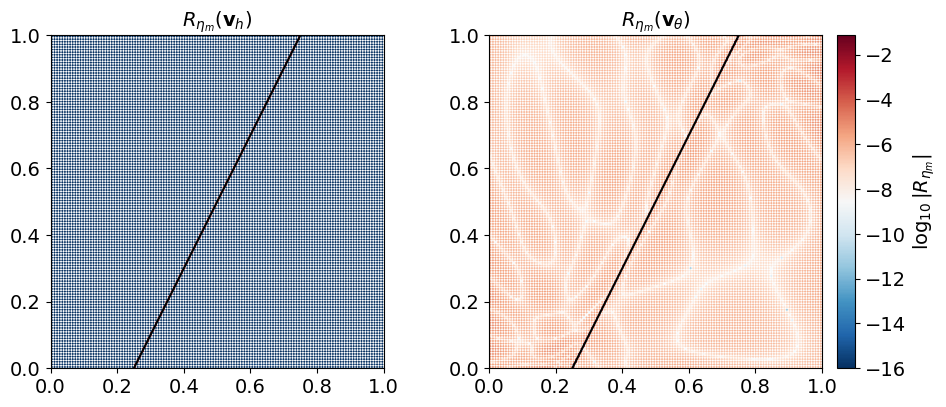

In [18]:
# Midpoint-diamond CV diagnostic: eta is obtained by connecting edge midpoints of each primal quad tau.
MID_DIAMOND_EDGE_NQ = 4
MID_DIAMOND_SOURCE_NQ = 3
MID_DIAMOND_MIN_AREA = 1.0e-14
MID_DIAMOND_CMAP = "RdBu_r"
MID_DIAMOND_OUTLINE_COLOR = "none"
MID_DIAMOND_OUTLINE_WIDTH = 0.0
MID_DIAMOND_LOG_CLIM = None


def _mid_diamond_legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def build_midpoint_diamond_cvs():
    polys, centers, areas, cell_ids = [], [], [], []
    for cid, poly in enumerate(cell_polys):
        mids = np.array([
            0.5 * (poly[j] + poly[(j + 1) % len(poly)])
            for j in range(len(poly))
        ], dtype=float)
        eta_poly = order_polygon_vertices(mids)
        area = abs(polygon_signed_area(eta_poly))
        if area <= MID_DIAMOND_MIN_AREA:
            continue
        polys.append(eta_poly)
        centers.append(eta_poly.mean(axis=0))
        areas.append(float(area))
        cell_ids.append(int(cid))
    return (
        np.asarray(polys, dtype=float),
        np.asarray(centers, dtype=float),
        np.asarray(areas, dtype=float),
        np.asarray(cell_ids, dtype=np.int32),
    )


def integrate_source_midpoint_diamond(poly):
    if MID_DIAMOND_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if MID_DIAMOND_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def build_midpoint_diamond_cv_quadrature(polys, cell_ids):
    edge_q, edge_w = _mid_diamond_legendre_01(MID_DIAMOND_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_midpoint_diamond(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)
        cell_id = int(cell_ids[eid])

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            for xa, xb in split_segment_at_partition_line(x0, x1):
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_midpoint_diamond_residuals(data, n_eta):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_rec = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_eta_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


mid_diamond_polys, mid_diamond_centers, mid_diamond_areas, mid_diamond_cell_ids = build_midpoint_diamond_cvs()
mid_diamond_data = build_midpoint_diamond_cv_quadrature(mid_diamond_polys, mid_diamond_cell_ids)
R_mid_diamond_cg, R_mid_diamond_rec = compute_midpoint_diamond_residuals(mid_diamond_data, len(mid_diamond_polys))
mid_diamond_frac_ids = np.where(mid_diamond_data["frac_source_abs"] > 1.0e-14)[0]

print("Midpoint-diamond CV residual R_eta")
print(f"  diamonds: {len(mid_diamond_polys)}")
print("  CG  :", residual_stats(R_mid_diamond_cg))
print("  PINN:", residual_stats(R_mid_diamond_rec))
if len(mid_diamond_frac_ids):
    print("Fracture-cut midpoint-diamond CV residual R_eta")
    print("  CG  :", residual_stats(R_mid_diamond_cg, mid_diamond_frac_ids))
    print("  PINN:", residual_stats(R_mid_diamond_rec, mid_diamond_frac_ids))

log_mid_cg = np.log10(np.abs(R_mid_diamond_cg) + eps)
log_mid_rec = np.log10(np.abs(R_mid_diamond_rec) + eps)
if MID_DIAMOND_LOG_CLIM is None:
    _vals = np.concatenate([log_mid_cg[np.isfinite(log_mid_cg)], log_mid_rec[np.isfinite(log_mid_rec)]])
    _mid_vmin = float(np.percentile(_vals, 1.0))
    _mid_vmax = float(_vals.max())
    if not np.isfinite(_mid_vmin) or not np.isfinite(_mid_vmax) or _mid_vmin >= _mid_vmax:
        _mid_vmin, _mid_vmax = -16.0, -1.0
else:
    _mid_vmin, _mid_vmax = map(float, MID_DIAMOND_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], log_mid_cg, r"$R_{\eta_m}(\mathbf{v}_h)$"),
    (axes[1], log_mid_rec, r"$R_{\eta_m}(\mathbf{v}_\theta)$"),
]:
    pc = PolyCollection(
        mid_diamond_polys,
        edgecolors=MID_DIAMOND_OUTLINE_COLOR,
        linewidths=MID_DIAMOND_OUTLINE_WIDTH,
        cmap=MID_DIAMOND_CMAP,
    )
    pc.set_array(vals)
    pc.set_clim(_mid_vmin, _mid_vmax)
    ax.add_collection(pc)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(False)
fig.canvas.draw()
_axpos = axes[1].get_position()
_cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
cbar = fig.colorbar(pc, cax=_cax)
cbar.set_label(r"$\log_{10}|R_{\eta_m}|$", fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.show()


Vertex-centered midpoint-diamond CV residual R_eta
  diamonds: 16129
  CG  : {'mean': 0.00011467312474373584, 'median': 4.506841738347034e-09, 'max': 0.05483449344430321}
  PINN: {'mean': 2.2483468998776923e-06, 'median': 6.439057854733601e-07, 'max': 0.0066619095107711}
Fracture-cut vertex-centered midpoint-diamond CV residual R_eta
  CG  : {'mean': 0.0045147030896142545, 'median': 0.00362772665179637, 'max': 0.018581086851544013}
  PINN: {'mean': 0.00035791849492378965, 'median': 0.00014101375470633275, 'max': 0.0066619095107711}


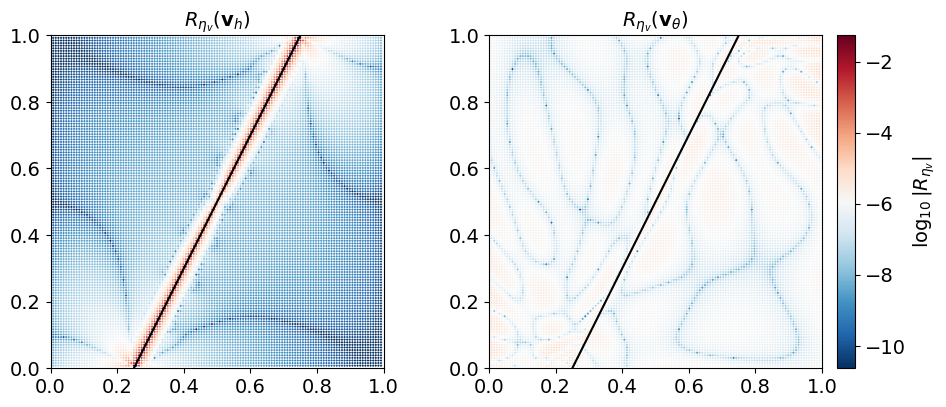

In [19]:
# Vertex-centered midpoint-diamond CV diagnostic.
# Each eta_v is centered at an interior primal vertex and connects the four neighboring edge midpoints.
VERT_DIAMOND_EDGE_NQ = MID_DIAMOND_EDGE_NQ
VERT_DIAMOND_SOURCE_NQ = MID_DIAMOND_SOURCE_NQ
VERT_DIAMOND_MIN_AREA = 1.0e-14
VERT_DIAMOND_CMAP = "RdBu_r"
VERT_DIAMOND_OUTLINE_COLOR = "none"
VERT_DIAMOND_OUTLINE_WIDTH = 0.0
VERT_DIAMOND_LOG_CLIM = None


def _is_domain_boundary_xy(xy, tol=1.0e-12):
    return (
        np.isclose(xy[0], xmin, atol=tol)
        or np.isclose(xy[0], xmax, atol=tol)
        or np.isclose(xy[1], ymin, atol=tol)
        or np.isclose(xy[1], ymax, atol=tol)
    )


def build_vertex_midpoint_diamond_cvs():
    polys, centers, areas, vertex_ids, edge_cell_ids = [], [], [], [], []
    hx = float(h_est)
    hy = float(h_est)
    offsets = np.array([[0.0, -0.5 * hy], [0.5 * hx, 0.0], [0.0, 0.5 * hy], [-0.5 * hx, 0.0]], dtype=float)

    for vid, xy in enumerate(cv_rect["vertices_xy"]):
        xy = np.asarray(xy, dtype=float)
        if _is_domain_boundary_xy(xy):
            continue
        eta_poly = order_polygon_vertices(xy[None, :] + offsets)
        if (
            eta_poly[:, 0].min() < xmin - 1.0e-12
            or eta_poly[:, 0].max() > xmax + 1.0e-12
            or eta_poly[:, 1].min() < ymin - 1.0e-12
            or eta_poly[:, 1].max() > ymax + 1.0e-12
        ):
            continue
        area = abs(polygon_signed_area(eta_poly))
        if area <= VERT_DIAMOND_MIN_AREA:
            continue

        edge_cids = []
        for j in range(len(eta_poly)):
            probe = 0.5 * (eta_poly[j] + eta_poly[(j + 1) % len(eta_poly)])
            edge_cids.append(int(locate_bulk_cell_xy(probe, sol["bulk_data"])["cell_id"]))

        polys.append(eta_poly)
        centers.append(xy)
        areas.append(float(area))
        vertex_ids.append(int(vid))
        edge_cell_ids.append(edge_cids)

    return (
        np.asarray(polys, dtype=float),
        np.asarray(centers, dtype=float),
        np.asarray(areas, dtype=float),
        np.asarray(vertex_ids, dtype=np.int32),
        np.asarray(edge_cell_ids, dtype=np.int32),
    )


def integrate_source_vertex_diamond(poly):
    if VERT_DIAMOND_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    return integrate_source_midpoint_diamond(poly)


def build_vertex_diamond_cv_quadrature(polys, edge_cell_ids_by_eta):
    edge_q, edge_w = _mid_diamond_legendre_01(VERT_DIAMOND_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_vertex_diamond(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            cell_id = int(edge_cell_ids_by_eta[eid, j])
            for xa, xb in split_segment_at_partition_line(x0, x1):
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def compute_vertex_diamond_residuals(data, n_eta):
    q_cg = q_cg_cell_local_numpy(data["edge_points"], data["edge_cell_ids"])
    q_rec = q_rec_numpy(data["edge_points"])
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_rec_q = np.sum(q_rec * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_rec = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_rec, data["edge_eta_ids"], flux_rec_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_rec - total_source


vertex_diamond_polys, vertex_diamond_centers, vertex_diamond_areas, vertex_diamond_vertex_ids, vertex_diamond_edge_cell_ids = build_vertex_midpoint_diamond_cvs()
vertex_diamond_data = build_vertex_diamond_cv_quadrature(vertex_diamond_polys, vertex_diamond_edge_cell_ids)
R_vertex_diamond_cg, R_vertex_diamond_rec = compute_vertex_diamond_residuals(vertex_diamond_data, len(vertex_diamond_polys))
vertex_diamond_frac_ids = np.where(vertex_diamond_data["frac_source_abs"] > 1.0e-14)[0]

print("Vertex-centered midpoint-diamond CV residual R_eta")
print(f"  diamonds: {len(vertex_diamond_polys)}")
print("  CG  :", residual_stats(R_vertex_diamond_cg))
print("  PINN:", residual_stats(R_vertex_diamond_rec))
if len(vertex_diamond_frac_ids):
    print("Fracture-cut vertex-centered midpoint-diamond CV residual R_eta")
    print("  CG  :", residual_stats(R_vertex_diamond_cg, vertex_diamond_frac_ids))
    print("  PINN:", residual_stats(R_vertex_diamond_rec, vertex_diamond_frac_ids))

log_vertex_cg = np.log10(np.abs(R_vertex_diamond_cg) + eps)
log_vertex_rec = np.log10(np.abs(R_vertex_diamond_rec) + eps)
if VERT_DIAMOND_LOG_CLIM is None:
    _vals = np.concatenate([log_vertex_cg[np.isfinite(log_vertex_cg)], log_vertex_rec[np.isfinite(log_vertex_rec)]])
    _vertex_vmin = float(np.percentile(_vals, 1.0))
    _vertex_vmax = float(_vals.max())
    if not np.isfinite(_vertex_vmin) or not np.isfinite(_vertex_vmax) or _vertex_vmin >= _vertex_vmax:
        _vertex_vmin, _vertex_vmax = -16.0, -1.0
else:
    _vertex_vmin, _vertex_vmax = map(float, VERT_DIAMOND_LOG_CLIM)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.88, bottom=0.12, top=0.86, wspace=0.18)
for ax, vals, title in [
    (axes[0], log_vertex_cg, r"$R_{\eta_v}(\mathbf{v}_h)$"),
    (axes[1], log_vertex_rec, r"$R_{\eta_v}(\mathbf{v}_\theta)$"),
]:
    pc = PolyCollection(
        vertex_diamond_polys,
        edgecolors=VERT_DIAMOND_OUTLINE_COLOR,
        linewidths=VERT_DIAMOND_OUTLINE_WIDTH,
        cmap=VERT_DIAMOND_CMAP,
    )
    pc.set_array(vals)
    pc.set_clim(_vertex_vmin, _vertex_vmax)
    ax.add_collection(pc)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.5)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(False)
fig.canvas.draw()
_axpos = axes[1].get_position()
_cax = fig.add_axes([_axpos.x1 + 0.015, _axpos.y0, 0.018, _axpos.height])
cbar = fig.colorbar(pc, cax=_cax)
cbar.set_label(r"$\log_{10}|R_{\eta_v}|$", fontsize=14)
cbar.ax.tick_params(labelsize=14)
plt.show()


fracture-cut residual scatter cells: 128 / 16384


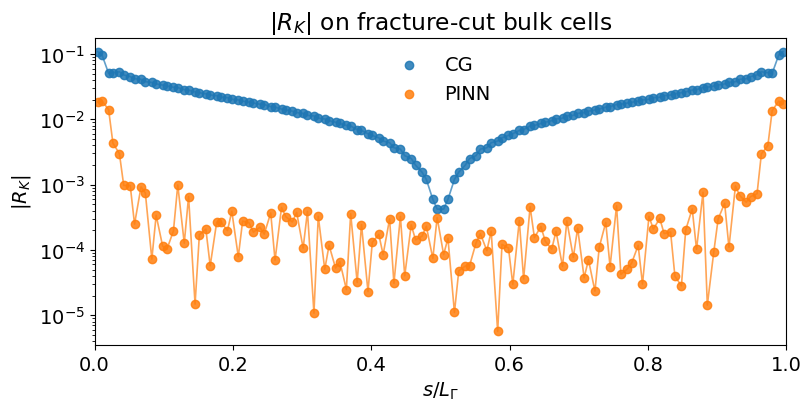

In [20]:
# R_K scatter diagnostic restricted to bulk cells cut by the fracture
diag_cell_ids = np.asarray(diag_data["cell_ids"], dtype=np.int32)
cut_cell_ids = np.asarray(frac_cell_ids, dtype=np.int32)
diag_position = {int(cid): i for i, cid in enumerate(diag_cell_ids)}
cut_diag_pos = np.array([diag_position[int(cid)] for cid in cut_cell_ids if int(cid) in diag_position], dtype=np.int32)
cut_plot_cell_ids = diag_cell_ids[cut_diag_pos]

print(f"fracture-cut residual scatter cells: {len(cut_plot_cell_ids)} / {num_cells}")
if len(cut_plot_cell_ids) == 0:
    raise RuntimeError("No fracture-cut cells were found in diag_data; check gamma_facet_records.")

cut_s = ((cell_centroids[cut_plot_cell_ids, :2] - FRAC_A[None, :]) @ tau_np) / L_gamma
cut_order = np.argsort(cut_s)
cut_s = cut_s[cut_order]
eps = 1e-16
cut_R_cg = np.abs(R_cg[cut_diag_pos][cut_order]) + eps
cut_R_rec = np.abs(R_rec[cut_diag_pos][cut_order]) + eps

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(cut_s, cut_R_cg, lw=1.2, alpha=0.7, color="C0")
ax.plot(cut_s, cut_R_rec, lw=1.2, alpha=0.7, color="C1")
ax.scatter(cut_s, cut_R_cg, s=36, alpha=0.85, color="C0", label="CG")
ax.scatter(cut_s, cut_R_rec, s=36, alpha=0.85, color="C1", label="PINN")
ax.set_xlabel(r"$s/L_\Gamma$")
ax.set_ylabel(r"$|R_K|$")
ax.set_title(r"$|R_K|$ on fracture-cut bulk cells")
ax.set_xlim(0.0, 1.0)
ax.set_yscale("log")
ax.legend(frameon=False)
ax.grid(False)
plt.show()


MRST validation file: case3_ecmor/case3_mrst_export.mat
MRST grid: (np.int64(128), np.int64(128)) faces: 33024 fracture cells: 125
Pressure comparison: LCG CG solve minus MRST
  matrix pressure, all               n= 16384 mean|e|=1.377e-03 rmse=1.955e-03 max|e|=1.834e-02 rel_rmse=7.313e-04
  matrix pressure, |phi|>2h          n= 15872 mean|e|=1.311e-03 rmse=1.806e-03 max|e|=9.762e-03 rel_rmse=6.751e-04
  matrix pressure, |phi|<=2h         n=   512 mean|e|=3.429e-03 rmse=4.612e-03 max|e|=1.834e-02 rel_rmse=1.746e-03
  fracture pressure                  n=   125 mean|e|=6.029e-03 rmse=6.983e-03 max|e|=1.215e-02 rel_rmse=2.639e-03
Matrix face-flux comparison: notebook integral minus MRST face_flux
  PINN face flux, all                n= 33024 mean|e|=2.266e-04 rmse=7.538e-04 max|e|=1.815e-02 rel_rmse=4.214e-02
  PINN face flux, regular            n= 32576 mean|e|=1.662e-04 rmse=4.090e-04 max|e|=1.028e-02 rel_rmse=2.294e-02
  PINN face flux, fracture-cut       n=   448 mean|e|=4.618e-03 rm

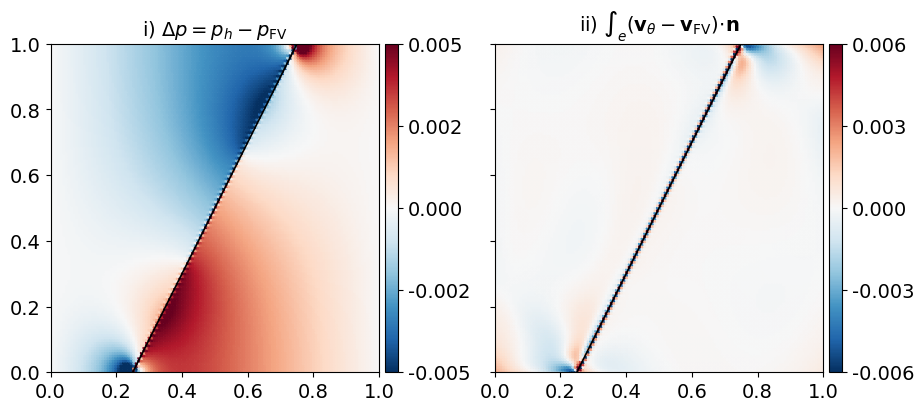

In [21]:
# MRST TPFA-EDFM validation for KM Case 1 / conference Case 3.
from scipy.io import loadmat

MRST_CASE3_PATH = pathlib.Path("case3_ecmor/case3_mrst_export.mat")
if not MRST_CASE3_PATH.exists():
    _mrst_alt = pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export.mat")
    if _mrst_alt.exists():
        MRST_CASE3_PATH = _mrst_alt
if not MRST_CASE3_PATH.exists():
    raise FileNotFoundError(f"Could not find MRST export at {MRST_CASE3_PATH}")

mrst = loadmat(MRST_CASE3_PATH, squeeze_me=True)
mrst_case3_available = True
mrst_xc_matrix = np.asarray(mrst["xc_matrix"], dtype=float)
mrst_p_matrix = np.asarray(mrst["p_matrix"], dtype=float).reshape(-1)
mrst_xc_frac = np.asarray(mrst["xc_frac"], dtype=float)
mrst_s_frac = np.asarray(mrst["s_frac"], dtype=float).reshape(-1)
mrst_p_frac = np.asarray(mrst["p_frac"], dtype=float).reshape(-1)
mrst_face_p1 = np.asarray(mrst["face_p1"], dtype=float)
mrst_face_p2 = np.asarray(mrst["face_p2"], dtype=float)
mrst_face_centroid = np.asarray(mrst["face_centroid"], dtype=float)
mrst_face_normal = np.asarray(mrst["face_normal"], dtype=float)
mrst_face_len = np.asarray(mrst["face_len"], dtype=float).reshape(-1)
mrst_face_flux = np.asarray(mrst["face_flux"], dtype=float).reshape(-1)
mrst_face_neighbors = np.asarray(mrst["face_neighbors"], dtype=np.int64)
mrst_face_is_boundary = np.asarray(mrst["face_is_boundary"], dtype=bool).reshape(-1)
mrst_face_frac_cut = np.asarray(mrst["face_frac_cut"], dtype=bool).reshape(-1)
mrst_lam_s = np.asarray(mrst["lam_s"], dtype=float).reshape(-1)
mrst_lam_density = np.asarray(mrst["lam_density"], dtype=float).reshape(-1)

_mrst_fracA = np.asarray(mrst.get("meta_fracA", FRAC_A), dtype=float).reshape(-1)
_mrst_fracB = np.asarray(mrst.get("meta_fracB", FRAC_B), dtype=float).reshape(-1)
_mrst_celldim = np.asarray(mrst.get("meta_celldim", [sol["n_bulk"], sol["n_bulk"]]), dtype=int).reshape(-1)
if not (np.allclose(_mrst_fracA, FRAC_A) and np.allclose(_mrst_fracB, FRAC_B)):
    raise ValueError(f"MRST fracture geometry does not match notebook: A={_mrst_fracA}, B={_mrst_fracB}")
if len(_mrst_celldim) >= 2 and tuple(_mrst_celldim[:2]) != (sol["n_bulk"], sol["n_bulk"]):
    print("warning: MRST matrix grid differs from notebook n_bulk:", _mrst_celldim[:2], sol["n_bulk"])

print("MRST validation file:", MRST_CASE3_PATH)
print("MRST grid:", tuple(_mrst_celldim[:2]), "faces:", len(mrst_face_flux), "fracture cells:", len(mrst_s_frac))


def _finite_mask(*arrays):
    mask = np.ones(np.asarray(arrays[0]).shape, dtype=bool)
    for arr in arrays:
        mask &= np.isfinite(np.asarray(arr))
    return mask


def validation_stats(diff, ref=None, mask=None):
    diff = np.asarray(diff, dtype=float).reshape(-1)
    if mask is None:
        mask = np.ones(diff.shape, dtype=bool)
    else:
        mask = np.asarray(mask, dtype=bool).reshape(-1)
    mask &= np.isfinite(diff)
    if ref is not None:
        ref = np.asarray(ref, dtype=float).reshape(-1)
        mask &= np.isfinite(ref)
    if not np.any(mask):
        return {"n": 0, "mean_abs": np.nan, "rmse": np.nan, "max_abs": np.nan, "rel_rmse": np.nan}
    d = diff[mask]
    rmse = float(np.sqrt(np.mean(d ** 2)))
    if ref is None:
        rel_rmse = np.nan
    else:
        denom = float(np.sqrt(np.mean(ref[mask] ** 2)))
        rel_rmse = rmse / denom if denom > 0.0 else np.nan
    return {
        "n": int(mask.sum()),
        "mean_abs": float(np.mean(np.abs(d))),
        "rmse": rmse,
        "max_abs": float(np.max(np.abs(d))),
        "rel_rmse": float(rel_rmse) if np.isfinite(rel_rmse) else np.nan,
    }


def print_validation_stats(label, diff, ref=None, mask=None):
    st = validation_stats(diff, ref=ref, mask=mask)
    print(
        f"  {label:<34} n={st['n']:6d} "
        f"mean|e|={st['mean_abs']:.3e} rmse={st['rmse']:.3e} "
        f"max|e|={st['max_abs']:.3e} rel_rmse={st['rel_rmse']:.3e}"
    )
    return st


def p_gamma_on_s(s_query):
    pressure_data = build_fracture_pressure_data(gamma, V_f)
    out = np.zeros(len(np.asarray(s_query).reshape(-1)), dtype=float)
    for i, sq in enumerate(np.asarray(s_query, dtype=float).reshape(-1)):
        cell = locate_pressure_cell_s(float(np.clip(sq, 0.0, L_gamma)), pressure_data)
        out[i] = float(p1_line_basis_on_pressure_cell(cell, sq) @ p_f.x.array[cell["dofs"]])
    return out


p_matrix_lcg_on_mrst = eval_fem_function(p_m, mrst_xc_matrix, omega).reshape(-1)
p_frac_lcg_on_mrst = p_gamma_on_s(mrst_s_frac)
p_matrix_diff_lcg_mrst = p_matrix_lcg_on_mrst - mrst_p_matrix
p_frac_diff_lcg_mrst = p_frac_lcg_on_mrst - mrst_p_frac

matrix_near_gamma_mask = np.abs(signed_distance_np(mrst_xc_matrix)) <= 2.0 * h_est
matrix_bulk_mask = ~matrix_near_gamma_mask
print("Pressure comparison: LCG CG solve minus MRST")
pressure_matrix_all_stats = print_validation_stats("matrix pressure, all", p_matrix_diff_lcg_mrst, mrst_p_matrix)
pressure_matrix_bulk_stats = print_validation_stats("matrix pressure, |phi|>2h", p_matrix_diff_lcg_mrst, mrst_p_matrix, matrix_bulk_mask)
pressure_matrix_near_stats = print_validation_stats("matrix pressure, |phi|<=2h", p_matrix_diff_lcg_mrst, mrst_p_matrix, matrix_near_gamma_mask)
pressure_frac_stats = print_validation_stats("fracture pressure", p_frac_diff_lcg_mrst, mrst_p_frac)


def integrate_pinn_flux_on_mrst_faces(batch_faces=50000):
    out = np.empty(len(mrst_face_flux), dtype=float)
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        p1 = mrst_face_p1[i0:i1]
        p2 = mrst_face_p2[i0:i1]
        mid = 0.5 * (p1 + p2)
        half = 0.5 * (p2 - p1)
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        q = q_rec_numpy(xq.reshape(-1, 2)).reshape(i1 - i0, len(_G3_SYM), 2)
        qn = np.einsum("fqd,fd->fq", q, mrst_face_normal[i0:i1])
        out[i0:i1] = 0.5 * mrst_face_len[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out


def integrate_cg_owner_flux_on_mrst_faces(batch_faces=50000):
    out = np.empty(len(mrst_face_flux), dtype=float)
    owner_mrst = np.where(mrst_face_neighbors[:, 0] > 0, mrst_face_neighbors[:, 0], mrst_face_neighbors[:, 1])
    if np.any(owner_mrst <= 0):
        raise ValueError("Encountered an MRST face with no matrix owner cell.")
    owner_centers = mrst_xc_matrix[owner_mrst.astype(np.int64) - 1]
    owner_cell_ids = np.array([
        int(locate_bulk_cell_xy(xy, sol["bulk_data"])["cell_id"])
        for xy in owner_centers
    ], dtype=np.int32)
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        p1 = mrst_face_p1[i0:i1]
        p2 = mrst_face_p2[i0:i1]
        mid = 0.5 * (p1 + p2)
        half = 0.5 * (p2 - p1)
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        q = q_cg_cell_local_numpy(
            xq.reshape(-1, 2),
            np.repeat(owner_cell_ids[i0:i1], len(_G3_SYM)),
        ).reshape(i1 - i0, len(_G3_SYM), 2)
        qn = np.einsum("fqd,fd->fq", q, mrst_face_normal[i0:i1])
        out[i0:i1] = 0.5 * mrst_face_len[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out


mrst_flux_pinn = integrate_pinn_flux_on_mrst_faces()
mrst_flux_cg_owner = integrate_cg_owner_flux_on_mrst_faces()
mrst_flux_pinn_diff = mrst_flux_pinn - mrst_face_flux
mrst_flux_cg_owner_diff = mrst_flux_cg_owner - mrst_face_flux
face_regular_mask = ~mrst_face_frac_cut
face_cut_mask = mrst_face_frac_cut

print("Matrix face-flux comparison: notebook integral minus MRST face_flux")
flux_pinn_all_stats = print_validation_stats("PINN face flux, all", mrst_flux_pinn_diff, mrst_face_flux)
flux_pinn_regular_stats = print_validation_stats("PINN face flux, regular", mrst_flux_pinn_diff, mrst_face_flux, face_regular_mask)
flux_pinn_cut_stats = print_validation_stats("PINN face flux, fracture-cut", mrst_flux_pinn_diff, mrst_face_flux, face_cut_mask)
flux_cg_all_stats = print_validation_stats("CG-owner face flux, all", mrst_flux_cg_owner_diff, mrst_face_flux)
flux_cg_regular_stats = print_validation_stats("CG-owner face flux, regular", mrst_flux_cg_owner_diff, mrst_face_flux, face_regular_mask)
flux_cg_cut_stats = print_validation_stats("CG-owner face flux, fracture-cut", mrst_flux_cg_owner_diff, mrst_face_flux, face_cut_mask)

mrst_lambda_lcg_raw = lambda_h_on_s(mrst_lam_s)
_lam_same_rmse = validation_stats(mrst_lambda_lcg_raw - mrst_lam_density, mrst_lam_density)["rmse"]
_lam_flip_rmse = validation_stats(-mrst_lambda_lcg_raw - mrst_lam_density, mrst_lam_density)["rmse"]
mrst_lambda_sign_to_mrst = 1.0 if _lam_same_rmse <= _lam_flip_rmse else -1.0
mrst_lambda_lcg_to_mrst = mrst_lambda_sign_to_mrst * mrst_lambda_lcg_raw
mrst_lambda_diff_lcg_mrst = mrst_lambda_lcg_to_mrst - mrst_lam_density
print("Lambda/exchange comparison: sign-adjusted LCG lambda_h minus MRST lam_density")
print(f"  sign applied to LCG lambda_h for MRST convention: {mrst_lambda_sign_to_mrst:+.0f}")
lambda_stats = print_validation_stats("lambda density", mrst_lambda_diff_lcg_mrst, mrst_lam_density)

# Publication-ready MRST validation maps.
from mpl_toolkits.axes_grid1 import make_axes_locatable
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

    _pdiff_lim = float(np.nanpercentile(np.abs(p_matrix_diff_lcg_mrst), 99.0))
    if not np.isfinite(_pdiff_lim) or _pdiff_lim <= 0.0:
        _pdiff_lim = 1.0
    _sc_p = axes[0].scatter(
        mrst_xc_matrix[:, 0], mrst_xc_matrix[:, 1],
        c=p_matrix_diff_lcg_mrst, s=3, cmap="RdBu_r", vmin=-_pdiff_lim, vmax=_pdiff_lim, rasterized=True,
    )
    axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.2)
    axes[0].set_xlim(xmin, xmax)
    axes[0].set_ylim(ymin, ymax)
    axes[0].set_aspect("equal")
    axes[0].set_title(r"i) $\Delta p=p_h-p_{\mathrm{FV}}$")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].grid(False)
    _div_p = make_axes_locatable(axes[0])
    _cax_p = _div_p.append_axes("right", size="4%", pad=0.06)
    cbar_p = fig.colorbar(_sc_p, cax=_cax_p)
    _p_ticks = np.linspace(-_pdiff_lim, _pdiff_lim, 5)
    cbar_p.set_ticks(_p_ticks)
    cbar_p.set_ticklabels([f"{t:.3f}" for t in _p_ticks])

    _flux_diff = mrst_flux_pinn_diff
    _flux_diff_finite = _flux_diff[np.isfinite(_flux_diff)]
    _flux_diff_lim = float(np.nanpercentile(np.abs(_flux_diff_finite), 99.5)) if _flux_diff_finite.size else 1.0
    if not np.isfinite(_flux_diff_lim) or _flux_diff_lim <= 0.0:
        _flux_diff_lim = float(np.nanmax(np.abs(_flux_diff))) if np.isfinite(_flux_diff).any() else 1.0
    if not np.isfinite(_flux_diff_lim) or _flux_diff_lim <= 0.0:
        _flux_diff_lim = 1.0
    _sc_f = axes[1].scatter(
        mrst_face_centroid[:, 0], mrst_face_centroid[:, 1],
        c=_flux_diff, s=2.5, cmap="RdBu_r", vmin=-_flux_diff_lim, vmax=_flux_diff_lim, rasterized=True,
    )
    axes[1].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.2)
    axes[1].set_xlim(xmin, xmax)
    axes[1].set_ylim(ymin, ymax)
    axes[1].set_aspect("equal")
    axes[1].set_title(r"ii) $\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\!\cdot\!\mathbf{n}$")
    axes[1].set_xlabel("")
    axes[1].tick_params(labelleft=False)
    axes[1].grid(False)
    _div_f = make_axes_locatable(axes[1])
    _cax_f = _div_f.append_axes("right", size="4%", pad=0.06)
    cbar_f = fig.colorbar(_sc_f, cax=_cax_f)
    _f_ticks = np.linspace(-_flux_diff_lim, _flux_diff_lim, 5)
    cbar_f.set_ticks(_f_ticks)
    cbar_f.set_ticklabels([f"{t:.3f}" for t in _f_ticks])
    plt.show()


In [22]:
# Right-boundary flux as an explicit boundary integral (Option 1) -- run before the
# saturation solve. The pointwise flux-difference map (panel ii) looks ~white on the
# right boundary, yet the integrated right_inflow differs by a few percent. This shows
# why: small, mostly same-sign per-face differences -- invisible on the +-0.008 map --
# add up over the ~n_bulk boundary faces. Computed on the MRST right-boundary faces,
# where mrst_flux_pinn / mrst_flux_cg_owner / mrst_face_flux share one orientation.
_rb_tol = 0.25 * h_est
_rb_mask = mrst_face_is_boundary & (np.abs(mrst_face_centroid[:, 0] - xmax) <= _rb_tol)
_nrb = int(np.sum(_rb_mask))
if _nrb == 0:
    raise RuntimeError("No MRST right-boundary faces found; check xmax / centroid orientation.")

def _rb_sum(arr):
    return float(np.sum(np.asarray(arr, dtype=float)[_rb_mask]))

_phi_mrst = _rb_sum(mrst_face_flux)
_phi_pinn = _rb_sum(mrst_flux_pinn)
_phi_cg = _rb_sum(mrst_flux_cg_owner)
_d_pinn = _rb_sum(mrst_flux_pinn - mrst_face_flux)
_d_cg = _rb_sum(mrst_flux_cg_owner - mrst_face_flux)
_max_pinn = float(np.max(np.abs((mrst_flux_pinn - mrst_face_flux)[_rb_mask])))
_max_cg = float(np.max(np.abs((mrst_flux_cg_owner - mrst_face_flux)[_rb_mask])))

print("Right-boundary flux as a boundary integral (explains the right_inflow gap)")
print(f"  right-boundary faces : {_nrb}")
print(f"  total normal flux    : MRST={_phi_mrst:+.4e}  PINN={_phi_pinn:+.4e}  CG={_phi_cg:+.4e}")
print(
    f"  Sum(PINN - MRST)     : {_d_pinn:+.4e}  ({100.0 * _d_pinn / abs(_phi_mrst):+.2f}% of MRST)"
    f"  mean/face={_d_pinn / _nrb:+.3e}  max|per-face|={_max_pinn:.3e}"
)
print(
    f"  Sum(CG   - MRST)     : {_d_cg:+.4e}  ({100.0 * _d_cg / abs(_phi_mrst):+.2f}% of MRST)"
    f"  mean/face={_d_cg / _nrb:+.3e}  max|per-face|={_max_cg:.3e}"
)
print("  -> max per-face difference is tiny vs the summed (coherent) difference: a small")
print("     same-sign bias invisible on the map integrates into the right_inflow gap.")

# Per-face detail: where along the right boundary is the discrepancy concentrated?
_yb = mrst_face_centroid[_rb_mask, 1]
_dp = (mrst_flux_pinn - mrst_face_flux)[_rb_mask]
_dc = (mrst_flux_cg_owner - mrst_face_flux)[_rb_mask]
_order = np.argsort(_yb)
_yb, _dp, _dc = _yb[_order], _dp[_order], _dc[_order]

_bands = [
    ("y in [0.0,0.1] (near y=0)", (_yb >= 0.0) & (_yb <= 0.1)),
    ("y in [0.1,0.9] (bulk)    ", (_yb > 0.1) & (_yb < 0.9)),
    ("y in [0.9,1.0] (near y=1)", (_yb >= 0.9) & (_yb <= 1.0)),
]
print("Right-boundary discrepancy by y-band (signed Sum and max|per-face|):")
for _label, _m in _bands:
    _n = int(np.sum(_m))
    if _n == 0:
        print(f"  {_label}: (no faces)")
        continue
    print(
        f"  {_label}: nfaces={_n:3d}"
        f"  PINN Sum={np.sum(_dp[_m]):+.3e} max|f|={np.max(np.abs(_dp[_m])):.2e}"
        f"  CG Sum={np.sum(_dc[_m]):+.3e} max|f|={np.max(np.abs(_dc[_m])):.2e}"
    )

def _topk(diff, k=5):
    idx = np.argsort(np.abs(diff))[::-1][:k]
    return [(float(_yb[i]), float(diff[i])) for i in idx]

print("Top-5 right-boundary faces by |PINN - MRST|:")
for _y, _v in _topk(_dp):
    print(f"    y={_y:.3f}  diff={_v:+.3e}")
print("Top-5 right-boundary faces by |CG - MRST|:")
for _y, _v in _topk(_dc):
    print(f"    y={_y:.3f}  diff={_v:+.3e}")


Right-boundary flux as a boundary integral (explains the right_inflow gap)
  right-boundary faces : 128
  total normal flux    : MRST=-2.5032e+00  PINN=-2.5075e+00  CG=-2.4989e+00
  Sum(PINN - MRST)     : -4.2420e-03  (-0.17% of MRST)  mean/face=-3.314e-05  max|per-face|=2.140e-03
  Sum(CG   - MRST)     : +4.3317e-03  (+0.17% of MRST)  mean/face=+3.384e-05  max|per-face|=7.515e-05
  -> max per-face difference is tiny vs the summed (coherent) difference: a small
     same-sign bias invisible on the map integrates into the right_inflow gap.
Right-boundary discrepancy by y-band (signed Sum and max|per-face|):
  y in [0.0,0.1] (near y=0): nfaces= 13  PINN Sum=+3.697e-03 max|f|=3.05e-04  CG Sum=+5.927e-04 max|f|=4.59e-05
  y in [0.1,0.9] (bulk)    : nfaces=102  PINN Sum=+3.742e-03 max|f|=3.46e-04  CG Sum=+2.861e-03 max|f|=5.24e-05
  y in [0.9,1.0] (near y=1): nfaces= 13  PINN Sum=-1.168e-02 max|f|=2.14e-03  CG Sum=+8.775e-04 max|f|=7.51e-05
Top-5 right-boundary faces by |PINN - MRST|:
    y

Rotated-zeta transport grid: cells=16744, canonical edges=33852 (interior=33124, boundary=728)
Rotated-zeta fracture exchange balance (single-phase):
  CG         sum(F_out)-E: n=182 mean|r|=5.887e-03 rmse=9.389e-03 max|r|=4.772e-02 sum(r)=+4.072e-03
  PINN       sum(F_out)-E: n=182 mean|r|=8.151e-04 rmse=3.204e-03 max|r|=2.522e-02 sum(r)=+5.577e-04
  MRST       sum(F_out)-E: n=181 mean|r|=9.209e-03 rmse=1.186e-02 max|r|=4.007e-02 sum(r)=-1.404e-01
Rotated-zeta fracture single-phase balance with open tips:
  CG (LCG q_gamma)     sum(Q_out incl. tips)+E_matrix: n=287 mean|r|=9.404e-03 rmse=1.291e-02 max|r|=5.399e-02 sum(r)=-1.401e-10
  PINN (LCG q_gamma)   sum(Q_out incl. tips)+E_matrix: n=287 mean|r|=9.404e-03 rmse=1.291e-02 max|r|=5.399e-02 sum(r)=-1.401e-10
  MRST                 sum(Q_out incl. tips)+E_matrix: n=125 mean|r|=5.585e-03 rmse=9.195e-03 max|r|=4.801e-02 sum(r)=+6.330e-11
  corner inlet: S=1 on 180/183 bottom right-boundary face(s), y in [0.000, 0.985]
Buckley-Leverett tr

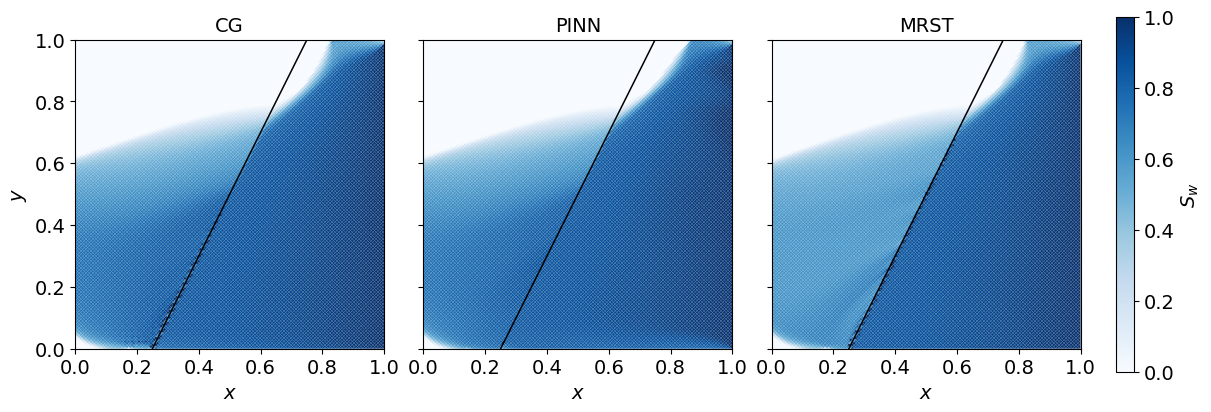

In [23]:
# Matrix-only Buckley-Leverett transport on rotated zeta control volumes.
TRANSPORT_PVI_TARGET = 1.0
TRANSPORT_CFL = 0.45
TRANSPORT_FPRIME_MAX = 2.0
TRANSPORT_RIGHT_BC_S = 1.0
TRANSPORT_RIGHT_BC_NFACES = 180  # inject S=1 only on the N bottom-most right faces (corner inlet); use a large N for the whole x=1 edge
TRANSPORT_DEFAULT_INFLOW_S = 0.0
TRANSPORT_CLIP = True  # keep off as a balance guard; clip dM diagnostics remain visible if enabled
TRANSPORT_T_REFERENCE = "MRST"  # method whose PVI target defines the shared physical end-time
TRANSPORT_FRACTURE_S_GAMMA = 0.0  # legacy frozen value; coupled transport below uses dynamic S_Gamma
TRANSPORT_FRACTURE_COUPLED = True  # True: dynamic S_Gamma conduit; False: frozen S_Gamma=0 sink (matrix-only, no tip throughflow)
TRANSPORT_FRAC_APERTURE = float(np.asarray(mrst.get("meta_aperture", 1.0)).reshape(-1)[0]) if "mrst" in globals() else 1.0
TRANSPORT_FRAC_POROSITY = 1.0
TRANSPORT_FRAC_TIP_S_A = 0.0  # only used if the low-pressure A tip reverses into the fracture
TRANSPORT_FRAC_TIP_S_B = 0.0  # high-pressure B tip inlet saturation
TRANSPORT_MAX_STEPS = 200_000
TRANSPORT_EXCHANGE_TOL = 1.0e-14
TRANSPORT_LCG_EXCHANGE_SIGN = 1.0
TRANSPORT_MRST_EXCHANGE_SIGN = -1.0  # MRST lam_density is opposite to the matrix-source convention used here

FACE_INTERIOR = -1
FACE_LEFT = 0
FACE_RIGHT = 1
FACE_BOTTOM = 2
FACE_TOP = 3


from matplotlib.collections import PolyCollection


def fractional_flow_bl(S):
    S = np.clip(np.asarray(S, dtype=float), 0.0, 1.0)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def cell_ij_from_cell(cell):
    ix = int(round(cell["x0"] / h_est))
    iy = int(round(cell["y0"] / h_est))
    return ix, iy


def boundary_side_from_midpoint(xy, tol=None):
    if tol is None:
        tol = 0.25 * h_est
    x, y = np.asarray(xy, dtype=float)[:2]
    if np.isclose(x, xmin, atol=tol):
        return FACE_LEFT
    if np.isclose(x, xmax, atol=tol):
        return FACE_RIGHT
    if np.isclose(y, ymin, atol=tol):
        return FACE_BOTTOM
    if np.isclose(y, ymax, atol=tol):
        return FACE_TOP
    return FACE_INTERIOR


def ensure_rotated_zeta_grid():
    global rotated_rect_polys, rotated_rect_centers, rotated_rect_areas
    global rotated_rect_poly_counts, rotated_rect_polys_padded

    if len(globals().get("rotated_rect_polys", [])) == 0:
        rotated_rect_polys, rotated_rect_centers, rotated_rect_areas = build_rotated_rectangles()

    rotated_rect_polys = [order_polygon_vertices(np.asarray(poly, dtype=float)) for poly in rotated_rect_polys]
    rotated_rect_centers = np.asarray([poly.mean(axis=0) for poly in rotated_rect_polys], dtype=float)
    rotated_rect_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in rotated_rect_polys], dtype=float)
    rotated_rect_poly_counts = np.asarray([len(poly) for poly in rotated_rect_polys], dtype=np.int32)
    max_vertices = int(rotated_rect_poly_counts.max()) if len(rotated_rect_poly_counts) else 0
    rotated_rect_polys_padded = np.full((len(rotated_rect_polys), max_vertices, 2), np.nan, dtype=float)
    for rid, poly in enumerate(rotated_rect_polys):
        rotated_rect_polys_padded[rid, :len(poly), :] = poly
    return rotated_rect_polys, rotated_rect_centers, rotated_rect_areas


def _zeta_edge_key(x0, x1, decimals=12):
    # Local copy of the cell-4 edge_key: the global name is clobbered by the
    # rotated-CV geometry plot cell (edge_key = tuple(...)), so do not rely on it.
    a = tuple(np.round(np.asarray(x0, dtype=float), decimals))
    b = tuple(np.round(np.asarray(x1, dtype=float), decimals))
    return tuple(sorted((a, b)))


def build_zeta_canonical_edges(polys, centers):
    records = {}
    for rid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        centroid = np.asarray(centers[rid], dtype=float)
        for j in range(len(poly)):
            a = np.asarray(poly[j], dtype=float)
            b = np.asarray(poly[(j + 1) % len(poly)], dtype=float)
            length = edge_length(a, b)
            if length <= 1.0e-14:
                continue
            key = _zeta_edge_key(a, b)
            if key not in records:
                normal = outward_edge_normal(a, b, centroid)
                records[key] = {
                    "owner": int(rid),
                    "neighbor": -1,
                    "p0": a.copy(),
                    "p1": b.copy(),
                    "normal": normal,
                    "length": float(length),
                }
            else:
                if records[key]["neighbor"] >= 0:
                    raise RuntimeError("A rotated-zeta edge is shared by more than two cells.")
                records[key]["neighbor"] = int(rid)

    owner, neighbor, side = [], [], []
    p0s, p1s, normals, lengths = [], [], [], []
    for rec in records.values():
        mid = 0.5 * (rec["p0"] + rec["p1"])
        face_side = FACE_INTERIOR if rec["neighbor"] >= 0 else boundary_side_from_midpoint(mid)
        owner.append(rec["owner"])
        neighbor.append(rec["neighbor"])
        side.append(face_side)
        p0s.append(rec["p0"])
        p1s.append(rec["p1"])
        normals.append(rec["normal"])
        lengths.append(rec["length"])

    out = {
        "owner": np.asarray(owner, dtype=np.int32),
        "neighbor": np.asarray(neighbor, dtype=np.int32),
        "side": np.asarray(side, dtype=np.int8),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "normal": np.asarray(normals, dtype=float),
        "length": np.asarray(lengths, dtype=float),
    }
    bad = (out["neighbor"] < 0) & (out["side"] == FACE_INTERIOR)
    if np.any(bad):
        raise RuntimeError(f"Found {int(np.sum(bad))} unmatched interior-looking zeta edges.")
    return out


def split_segment_by_primal_cells(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - a
    breaks = bulk_breakpoints_on_segment(a, b, sol["bulk_data"])
    pieces = []
    for r0, r1 in zip(breaks[:-1], breaks[1:]):
        if r1 - r0 <= 1.0e-14:
            continue
        xa = a + r0 * d
        xb = a + r1 * d
        if edge_length(xa, xb) > 1.0e-15:
            pieces.append((xa, xb))
    return pieces


def integrate_direct_flux_on_zeta_edges(edge_geom, flux_kind):
    F = np.zeros(len(edge_geom["owner"]), dtype=float)
    for eid, (a, b, nvec) in enumerate(zip(edge_geom["p0"], edge_geom["p1"], edge_geom["normal"])):
        total = 0.0
        for xa0, xb0 in split_segment_by_primal_cells(a, b):
            parts = split_segment_at_partition_line(xa0, xb0) if flux_kind == "pinn" else [(xa0, xb0)]
            for xa, xb in parts:
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                mid = 0.5 * (xa + xb)
                half = 0.5 * (xb - xa)
                xq = mid[None, :] + _G3_SYM[:, None] * half[None, :]
                if flux_kind == "cg":
                    cid = int(locate_bulk_cell_xy(mid, sol["bulk_data"])["cell_id"])
                    q = q_cg_cell_local_numpy(xq, np.full(len(_G3_SYM), cid, dtype=np.int32))
                elif flux_kind == "pinn":
                    q = q_rec_numpy(xq)
                else:
                    raise ValueError(f"unknown flux_kind={flux_kind!r}")
                total += 0.5 * seg_len * float(np.sum(_W3_SYM * (q @ nvec)))
        F[eid] = total
    return F


def build_mrst_rt0_reconstruction():
    nc = len(mrst_xc_matrix)
    x0 = np.empty(nc, dtype=float)
    x1 = np.empty(nc, dtype=float)
    y0 = np.empty(nc, dtype=float)
    y1 = np.empty(nc, dtype=float)
    cid_to_mrst = np.full(num_cells, -1, dtype=np.int32)

    for midx, xy in enumerate(mrst_xc_matrix):
        cell = locate_bulk_cell_xy(xy, sol["bulk_data"])
        cid = int(cell["cell_id"])
        cid_to_mrst[cid] = int(midx)
        x0[midx], x1[midx] = float(cell["x0"]), float(cell["x1"])
        y0[midx], y1[midx] = float(cell["y0"]), float(cell["y1"])

    if np.any(cid_to_mrst < 0):
        raise RuntimeError("MRST matrix cells do not cover every primal matrix cell.")

    hx = x1 - x0
    hy = y1 - y0
    face_out = np.full((nc, 4), np.nan, dtype=float)
    face_count = np.zeros((nc, 4), dtype=np.int16)
    side_tol = 0.35 * h_est

    for fid in range(len(mrst_face_flux)):
        n0, n1 = int(mrst_face_neighbors[fid, 0]), int(mrst_face_neighbors[fid, 1])
        for midx_1based, sign in ((n0, 1.0), (n1, -1.0)):
            if midx_1based <= 0:
                continue
            midx = int(midx_1based) - 1
            fc = np.asarray(mrst_face_centroid[fid], dtype=float)
            dists = np.array([
                abs(fc[0] - x0[midx]),
                abs(fc[0] - x1[midx]),
                abs(fc[1] - y0[midx]),
                abs(fc[1] - y1[midx]),
            ], dtype=float)
            side = int(np.argmin(dists))
            if dists[side] > side_tol:
                raise RuntimeError(f"Could not classify MRST face {fid} for RT0 reconstruction.")
            face_out[midx, side] = sign * float(mrst_face_flux[fid])
            face_count[midx, side] += 1

    if not np.all(face_count == 1):
        bad = np.argwhere(face_count != 1)
        raise RuntimeError(f"MRST RT0 reconstruction expected one face per side; bad entries={bad[:8].tolist()}")

    g_left = face_out[:, FACE_LEFT] / hy
    g_right = face_out[:, FACE_RIGHT] / hy
    g_bottom = face_out[:, FACE_BOTTOM] / hx
    g_top = face_out[:, FACE_TOP] / hx
    return {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "hx": hx,
        "hy": hy,
        "cid_to_mrst": cid_to_mrst,
        "g_left": g_left,
        "g_right": g_right,
        "g_bottom": g_bottom,
        "g_top": g_top,
    }


def eval_mrst_rt0_velocity(xq, midx, rt0):
    xq = np.asarray(xq, dtype=float)
    xi = (xq[:, 0] - rt0["x0"][midx]) / rt0["hx"][midx]
    eta = (xq[:, 1] - rt0["y0"][midx]) / rt0["hy"][midx]
    vx = -rt0["g_left"][midx] + (rt0["g_right"][midx] + rt0["g_left"][midx]) * xi
    vy = -rt0["g_bottom"][midx] + (rt0["g_top"][midx] + rt0["g_bottom"][midx]) * eta
    return np.column_stack([vx, vy])


def integrate_mrst_rt0_flux_on_zeta_edges(edge_geom, rt0):
    F = np.zeros(len(edge_geom["owner"]), dtype=float)
    for eid, (a, b, nvec) in enumerate(zip(edge_geom["p0"], edge_geom["p1"], edge_geom["normal"])):
        total = 0.0
        for xa, xb in split_segment_by_primal_cells(a, b):
            seg_len = edge_length(xa, xb)
            if seg_len <= 1.0e-15:
                continue
            mid = 0.5 * (xa + xb)
            cid = int(locate_bulk_cell_xy(mid, sol["bulk_data"])["cell_id"])
            midx = int(rt0["cid_to_mrst"][cid])
            if midx < 0:
                raise RuntimeError("Could not map a zeta-edge quadrature segment to an MRST cell.")
            half = 0.5 * (xb - xa)
            xq = mid[None, :] + _G3_SYM[:, None] * half[None, :]
            q = eval_mrst_rt0_velocity(xq, midx, rt0)
            total += 0.5 * seg_len * float(np.sum(_W3_SYM * (q @ nvec)))
        F[eid] = total
    return F


def make_owner_face_fluxes(edge_geom, F_owner):
    owners, neighbors, sides, fouts = [], [], [], []
    p0s, p1s, normals, lengths = [], [], [], []
    for eid, F in enumerate(np.asarray(F_owner, dtype=float)):
        i = int(edge_geom["owner"][eid])
        j = int(edge_geom["neighbor"][eid])
        side = int(edge_geom["side"][eid])
        owners.append(i)
        neighbors.append(j)
        sides.append(side)
        fouts.append(float(F))
        p0s.append(edge_geom["p0"][eid])
        p1s.append(edge_geom["p1"][eid])
        normals.append(edge_geom["normal"][eid])
        lengths.append(edge_geom["length"][eid])
        if j >= 0:
            owners.append(j)
            neighbors.append(i)
            sides.append(FACE_INTERIOR)
            fouts.append(float(-F))
            p0s.append(edge_geom["p0"][eid])
            p1s.append(edge_geom["p1"][eid])
            normals.append(-edge_geom["normal"][eid])
            lengths.append(edge_geom["length"][eid])
    return {
        "owner": np.asarray(owners, dtype=np.int32),
        "neighbor": np.asarray(neighbors, dtype=np.int32),
        "side": np.asarray(sides, dtype=np.int8),
        "F_out": np.asarray(fouts, dtype=float),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "normal": np.asarray(normals, dtype=float),
        "length": np.asarray(lengths, dtype=float),
    }


def _mrst_lambda_segment_edges():
    s = np.asarray(mrst_lam_s, dtype=float).reshape(-1)
    if "mrst_lam_seglen" in globals():
        seg = np.asarray(mrst_lam_seglen, dtype=float).reshape(-1)
    elif "mrst" in globals() and "lam_seglen" in mrst:
        seg = np.asarray(mrst["lam_seglen"], dtype=float).reshape(-1)
    else:
        edges = np.empty(len(s) + 1, dtype=float)
        edges[1:-1] = 0.5 * (s[:-1] + s[1:])
        edges[0] = 0.0
        edges[-1] = L_gamma
        return np.clip(edges, 0.0, L_gamma)
    return np.clip(np.r_[s[0] - 0.5 * seg[0], 0.5 * (s[:-1] + s[1:]), s[-1] + 0.5 * seg[-1]], 0.0, L_gamma)


def integrate_mrst_lambda_interval_signed(s0, s1):
    lo, hi = (float(s0), float(s1)) if s0 <= s1 else (float(s1), float(s0))
    if hi - lo <= 1.0e-15:
        return 0.0
    edges = _mrst_lambda_segment_edges()
    density = np.asarray(mrst_lam_density, dtype=float).reshape(-1)
    total = 0.0
    for a, b, val in zip(edges[:-1], edges[1:], density):
        aa = max(lo, float(a))
        bb = min(hi, float(b))
        if bb > aa:
            total += float(val) * (bb - aa)
    return float(total)


def build_transport_fracture_exchange(polys, n_cells, kind, sign=1.0):
    cv_ids, e_vals, s_mids = [], [], []
    e_by_cell = np.zeros(int(n_cells), dtype=float)
    for cid, poly in enumerate(polys):
        intervals = fracture_intervals_in_polygon(order_polygon_vertices(np.asarray(poly, dtype=float)))
        if not intervals:
            continue
        total = 0.0
        s_weight = 0.0
        len_weight = 0.0
        for s0, s1 in intervals:
            if kind == "lcg":
                piece = integrate_lambda_interval_signed(s0, s1)
            elif kind == "mrst":
                piece = integrate_mrst_lambda_interval_signed(s0, s1)
            else:
                raise ValueError(f"unknown exchange kind={kind!r}")
            total += piece
            ds = float(s1 - s0)
            s_weight += 0.5 * float(s0 + s1) * ds
            len_weight += ds
        total = float(sign) * float(total)
        if abs(total) <= TRANSPORT_EXCHANGE_TOL:
            continue
        cv_ids.append(int(cid))
        e_vals.append(total)
        s_mids.append(s_weight / len_weight if len_weight > 0.0 else np.nan)
        e_by_cell[int(cid)] = total
    return {
        "cv_ids": np.asarray(cv_ids, dtype=np.int32),
        "E": np.asarray(e_vals, dtype=float),
        "s_mid": np.asarray(s_mids, dtype=float),
        "E_by_cell": e_by_cell,
        "conn_cv_ids": np.asarray(cv_ids, dtype=np.int32),
        "conn_E": np.asarray(e_vals, dtype=float),
        "conn_s": np.asarray(s_mids, dtype=float),
        "kind": kind,
        "sign": float(sign),
    }


def oriented_face_flux_sum(oriented, n_cells):
    return np.bincount(oriented["owner"], weights=oriented["F_out"], minlength=int(n_cells))


def exchange_residual_stats(residual):
    residual = np.asarray(residual, dtype=float).reshape(-1)
    residual = residual[np.isfinite(residual)]
    if residual.size == 0:
        return "n=0"
    return (
        f"n={residual.size:d} mean|r|={np.mean(np.abs(residual)):.3e} "
        f"rmse={np.sqrt(np.mean(residual ** 2)):.3e} "
        f"max|r|={np.max(np.abs(residual)):.3e} sum(r)={np.sum(residual):+.3e}"
    )


def print_exchange_balance(label, oriented, exchange, n_cells):
    ids = exchange["cv_ids"]
    if len(ids) == 0:
        print(f"  {label:<10} no fracture-cut CVs")
        return np.array([], dtype=float)
    sum_f = oriented_face_flux_sum(oriented, n_cells)
    residual = sum_f[ids] - exchange["E_by_cell"][ids]
    print(f"  {label:<10} sum(F_out)-E: {exchange_residual_stats(residual)}")
    return residual


def pressure_driven_fracture_direction(p_A, p_B):
    # q > 0 means A -> B. Darcy flow points from high pressure to low pressure.
    dp = float(p_B) - float(p_A)
    if abs(dp) <= 1.0e-14:
        return 0.0
    return -float(np.sign(dp))


def orient_fracture_q_face(q_face, p_A, p_B, label):
    q_face = np.asarray(q_face, dtype=float).copy()
    expected = pressure_driven_fracture_direction(p_A, p_B)
    active = q_face[np.abs(q_face) > 1.0e-14]
    if expected != 0.0 and active.size:
        q_ref = float(np.median(active))
        if q_ref * expected < 0.0:
            q_face *= -1.0
            print(f"warning: flipped {label} fracture Q_face sign to match pressure-driven tip direction")
    return q_face


def fracture_direction_label(fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    if len(q) == 0:
        return "unknown"
    q_mid = float(np.median(q[np.abs(q) > 1.0e-14])) if np.any(np.abs(q) > 1.0e-14) else 0.0
    if q_mid < 0.0:
        return "B_to_A"
    if q_mid > 0.0:
        return "A_to_B"
    return "zero"


def build_lcg_fracture_transport_grid():
    pdata = build_fracture_pressure_data(gamma, V_f)
    cells = pdata["cells"]
    n = len(cells)
    s0 = np.asarray([cell["s0"] for cell in cells], dtype=float)
    s1 = np.asarray([cell["s1"] for cell in cells], dtype=float)
    s_faces = np.r_[s0[0], s1]
    length = s1 - s0
    p_left = np.asarray([p_f.x.array[cell["dofs"][0]] for cell in cells], dtype=float)
    p_right = np.asarray([p_f.x.array[cell["dofs"][1]] for cell in cells], dtype=float)
    q_elem = -K_F_VALUE * (p_right - p_left) / length
    q_face = np.empty(n + 1, dtype=float)
    q_face[0] = q_elem[0]
    q_face[-1] = q_elem[-1]
    if n > 1:
        q_face[1:-1] = 0.5 * (q_elem[:-1] + q_elem[1:])
    q_face = orient_fracture_q_face(q_face, p_left[0], p_right[-1], "LCG")
    return {
        "kind": "lcg",
        "s_faces": s_faces,
        "s_centers": 0.5 * (s0 + s1),
        "length": length,
        "pore_volume": TRANSPORT_FRAC_POROSITY * length,
        "aperture_convention": "aperture-free flux and pore volume",
        "Q_face": q_face,
        "tip_A_flux": q_face[0],
        "tip_B_flux": -q_face[-1],
        "direction": fracture_direction_label({"Q_face": q_face}),
    }


def _mrst_fracture_edges():
    s = np.asarray(mrst_s_frac, dtype=float).reshape(-1)
    if "mrst" in globals() and "lam_seglen" in mrst:
        seg = np.asarray(mrst["lam_seglen"], dtype=float).reshape(-1)
    elif "mrst_lam_seglen" in globals():
        seg = np.asarray(mrst_lam_seglen, dtype=float).reshape(-1)
    else:
        edges = np.empty(len(s) + 1, dtype=float)
        edges[1:-1] = 0.5 * (s[:-1] + s[1:])
        edges[0] = 0.0
        edges[-1] = L_gamma
        return np.clip(edges, 0.0, L_gamma)
    return np.clip(np.r_[s[0] - 0.5 * seg[0], 0.5 * (s[:-1] + s[1:]), s[-1] + 0.5 * seg[-1]], 0.0, L_gamma)


def build_mrst_fracture_transport_grid():
    s = np.asarray(mrst_s_frac, dtype=float).reshape(-1)
    p = np.asarray(mrst_p_frac, dtype=float).reshape(-1)
    order = np.argsort(s)
    s = s[order]
    p = p[order]
    edges = _mrst_fracture_edges()
    length = np.diff(edges)
    q_face = np.empty(len(s) + 1, dtype=float)
    Kgamma = float(np.asarray(mrst.get("meta_Kgamma", K_F_VALUE)).reshape(-1)[0]) if "mrst" in globals() else K_F_VALUE
    if len(s) > 1:
        q_face[1:-1] = -Kgamma * (p[1:] - p[:-1]) / (s[1:] - s[:-1])
    else:
        q_face[1:-1] = np.array([], dtype=float)
    expected_dir = pressure_driven_fracture_direction(p[0], p[-1])
    if len(s) > 1 and expected_dir != 0.0:
        q_int_active = q_face[1:-1][np.abs(q_face[1:-1]) > 1.0e-14]
        if q_int_active.size and float(np.median(q_int_active)) * expected_dir < 0.0:
            q_face[1:-1] *= -1.0
            print("warning: flipped MRST interior fracture Q_face sign to match pressure-driven tip direction")
    tip_flux = np.asarray(mrst.get("tip_flux", []), dtype=float).reshape(-1) if "mrst" in globals() else np.array([])
    tip_xy = np.asarray(mrst.get("tip_xy", np.zeros((0, 2))), dtype=float)
    if tip_flux.size >= 2 and tip_xy.size >= 4:
        tip_s = s_coord_np(tip_xy.reshape(-1, 2))
        a_idx = int(np.argmin(tip_s))
        b_idx = int(np.argmax(tip_s))
        q_tip_sign = expected_dir if expected_dir != 0.0 else -1.0
        q_face[0] = q_tip_sign * abs(float(tip_flux[a_idx]))
        q_face[-1] = q_tip_sign * abs(float(tip_flux[b_idx]))
        tip_A_flux = q_face[0]
        tip_B_flux = -q_face[-1]
    else:
        q_face[0] = q_face[1] if len(q_face) > 2 else 0.0
        q_face[-1] = q_face[-2] if len(q_face) > 2 else 0.0
        tip_A_flux = q_face[0]
        tip_B_flux = -q_face[-1]
        print("warning: MRST tip_flux was not found; fracture tip rates are inferred from pressure gradients.")
    return {
        "kind": "mrst",
        "s_faces": edges,
        "s_centers": s,
        "length": length,
        "pore_volume": TRANSPORT_FRAC_POROSITY * length,
        "aperture_convention": "aperture-free flux and pore volume",
        "Q_face": q_face,
        "tip_A_flux": tip_A_flux,
        "tip_B_flux": tip_B_flux,
        "direction": fracture_direction_label({"Q_face": q_face}),
    }


def attach_exchange_to_fracture(exchange, fracture):
    out = dict(exchange)
    if "conn_cv_ids" not in out:
        out["conn_cv_ids"] = np.asarray(out["cv_ids"], dtype=np.int32)
        out["conn_E"] = np.asarray(out["E"], dtype=float)
        out["conn_s"] = np.asarray(out["s_mid"], dtype=float)
    conn_s = np.asarray(out["conn_s"], dtype=float)
    edges = np.asarray(fracture["s_faces"], dtype=float)
    frac_ids = np.searchsorted(edges, conn_s, side="right") - 1
    frac_ids = np.clip(frac_ids, 0, len(edges) - 2).astype(np.int32)
    out["conn_frac_ids"] = frac_ids
    out["E_by_frac"] = np.bincount(frac_ids, weights=np.asarray(out["conn_E"], dtype=float), minlength=len(edges) - 1)
    return out


def fracture_outflow_sum(fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    out = np.maximum(-q[:-1], 0.0) + np.maximum(q[1:], 0.0)
    if len(out):
        out[0] += np.maximum(q[0], 0.0)       # reversed A-tip inflow also tightens the explicit step.
        out[-1] += np.maximum(-q[-1], 0.0)    # B-tip inlet throughflow is an explicit boundary source.
    return out


def fracture_single_phase_residual(fracture, exchange):
    q = np.asarray(fracture["Q_face"], dtype=float)
    q_out = -q[:-1] + q[1:]
    return q_out + exchange.get("E_by_frac", np.zeros(len(q_out), dtype=float))


def fracture_balance_display_label(label, fracture):
    if fracture.get("kind") == "lcg":
        return f"{label} (LCG q_gamma)"
    return str(label)


def print_fracture_single_phase_balance(label, fracture, exchange, gate_tol=None):
    residual = fracture_single_phase_residual(fracture, exchange)
    if gate_tol is None and fracture.get("kind") == "mrst" and exchange.get("kind") == "mrst_nnc":
        gate_tol = 1.0e-10
    gate = ""
    if gate_tol is not None:
        ok = bool(residual.size == 0 or np.nanmax(np.abs(residual)) <= gate_tol)
        gate = f" gate={'OK' if ok else 'CHECK'}(tol={gate_tol:.0e})"
    display = fracture_balance_display_label(label, fracture)
    print(f"  {display:<20} sum(Q_out incl. tips)+E_matrix: {exchange_residual_stats(residual)}{gate}")
    return residual


def bottom_right_inlet_mask(oriented, nfaces):
    neighbor = oriented["neighbor"]
    side = oriented["side"]
    is_right_bnd = (neighbor < 0) & (side == FACE_RIGHT)
    inj_mask = np.zeros(len(oriented["F_out"]), dtype=bool)
    if np.any(is_right_bnd):
        y_mid = 0.5 * (oriented["p0"][:, 1] + oriented["p1"][:, 1])
        rb_ids = np.where(is_right_bnd)[0]
        rb_sorted = rb_ids[np.argsort(y_mid[rb_ids])]
        inj_mask[rb_sorted[:int(min(nfaces, len(rb_sorted)))]] = True
    return inj_mask



def transport_gamma_crossing_face_data(oriented, centers):
    owner = np.asarray(oriented["owner"], dtype=np.int32)
    neighbor = np.asarray(oriented["neighbor"], dtype=np.int32)
    p0 = np.asarray(oriented["p0"], dtype=float)
    p1 = np.asarray(oriented["p1"], dtype=float)
    centers = np.asarray(centers, dtype=float)
    phi_center = signed_distance_np(centers)

    ids, pm_signs, s_hits = [], [], []
    # Keep one oriented record per interior face. Rectangular grids and zeta
    # grids both carry owner-neighbor and neighbor-owner records; owner<neighbor
    # removes the duplicate while preserving the recorded F_out orientation.
    unique_interior = np.nonzero((neighbor >= 0) & (owner < neighbor))[0]
    for eid in unique_interior:
        s_hit = segment_edge_s_intersection(p0[eid], p1[eid], tol=1.0e-12)
        if s_hit is None:
            continue
        phi_o = float(phi_center[owner[eid]])
        phi_n = float(phi_center[neighbor[eid]])
        if phi_o * phi_n >= 0.0:
            continue
        ids.append(int(eid))
        pm_signs.append(1.0 if phi_o > 0.0 and phi_n < 0.0 else -1.0)
        s_hits.append(float(s_hit))
    return {
        "ids": np.asarray(ids, dtype=np.int64),
        "plus_to_minus_sign": np.asarray(pm_signs, dtype=float),
        "s": np.asarray(s_hits, dtype=float),
    }


def compute_coupled_transport_dt(oriented, areas, n_cells, exchange, fracture):
    owner = oriented["owner"]
    F = oriented["F_out"]
    matrix_out = np.bincount(owner, weights=np.maximum(F, 0.0), minlength=int(n_cells))
    if exchange is not None and len(exchange.get("conn_cv_ids", [])):
        matrix_out += np.bincount(
            exchange["conn_cv_ids"],
            weights=np.abs(exchange["conn_E"]),
            minlength=int(n_cells),
        )
    active_m = matrix_out > 1.0e-30
    if not np.any(active_m):
        raise RuntimeError("No matrix outflow faces found for the fixed flux field.")
    dt_m = float(np.min(np.asarray(areas, dtype=float)[active_m] / (TRANSPORT_FPRIME_MAX * matrix_out[active_m])))

    frac_out = fracture_outflow_sum(fracture)
    if exchange is not None and len(exchange.get("conn_frac_ids", [])):
        frac_out += np.bincount(
            exchange["conn_frac_ids"],
            weights=np.abs(exchange["conn_E"]),
            minlength=len(frac_out),
        )
    active_f = frac_out > 1.0e-30
    dt_f = np.inf
    if np.any(active_f):
        dt_f = float(np.min(fracture["pore_volume"][active_f] / (TRANSPORT_FPRIME_MAX * frac_out[active_f])))
    return float(TRANSPORT_CFL * min(dt_m, dt_f)), dt_m, dt_f


def fracture_advection_update(S_frac, fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    n = len(S_frac)
    update = np.zeros(n, dtype=float)
    water_in = 0.0
    water_out = 0.0
    # Left tip A: F_out = -q[0].
    f_left = -q[0]
    if f_left >= 0.0:
        val = fractional_flow_bl(S_frac[0]) * f_left
        update[0] += val
        water_out += val
    else:
        val = fractional_flow_bl(TRANSPORT_FRAC_TIP_S_A) * f_left
        update[0] += val
        water_in += -val
    # Interior faces: q[j] is positive in the A -> B direction.
    if n > 1:
        q_int = q[1:-1]
        up_int = np.where(q_int >= 0.0, S_frac[:-1], S_frac[1:])
        val_int = fractional_flow_bl(up_int) * q_int
        update[:-1] += val_int
        update[1:] -= val_int
    # Right tip B: F_out = q[-1].
    f_right = q[-1]
    if f_right >= 0.0:
        val = fractional_flow_bl(S_frac[-1]) * f_right
        update[-1] += val
        water_out += val
    else:
        val = fractional_flow_bl(TRANSPORT_FRAC_TIP_S_B) * f_right
        update[-1] += val
        water_in += -val
    return update, float(water_in), float(water_out)


def advance_coupled_matrix_fracture_transport(oriented, areas, centers, t_final, exchange, fracture, inlet_nfaces):
    owner = oriented["owner"]
    neighbor = oriented["neighbor"]
    side = oriented["side"]
    F = oriented["F_out"]
    n_cells = len(areas)
    inj_mask = bottom_right_inlet_mask(oriented, inlet_nfaces)
    right_in = transport_right_inflow(oriented)
    if right_in <= 1.0e-30:
        raise RuntimeError("No right-boundary inflow was found. Check the pressure BC orientation.")

    dt_cfl, dt_matrix_raw, dt_fracture_raw = compute_coupled_transport_dt(oriented, areas, n_cells, exchange, fracture)
    if not TRANSPORT_FRACTURE_COUPLED:
        dt_cfl = TRANSPORT_CFL * dt_matrix_raw  # frozen S_Gamma: no fracture transport -> matrix CFL only
    T_final = float(t_final)
    nsteps = max(1, int(np.ceil(T_final / dt_cfl)))
    dt = T_final / nsteps
    print(
        f"       coupled CFL: dt_matrix={TRANSPORT_CFL * dt_matrix_raw:.4e}, "
        f"dt_fracture={TRANSPORT_CFL * dt_fracture_raw:.4e}, nsteps={nsteps:d}, "
        f"fracture volume={fracture.get('aperture_convention', 'unspecified')}"
    )
    if nsteps > TRANSPORT_MAX_STEPS:
        raise RuntimeError(
            f"fracture dt collapse: nsteps={nsteps:d} > {TRANSPORT_MAX_STEPS:d}. "
            "Check aperture consistency between fracture flux and pore volume."
        )
    S = np.zeros(n_cells, dtype=float)
    S_frac = np.zeros(len(fracture["length"]), dtype=float)
    conn_cells = np.asarray(exchange.get("conn_cv_ids", []), dtype=np.int32)
    conn_frac = np.asarray(exchange.get("conn_frac_ids", []), dtype=np.int32)
    conn_E = np.asarray(exchange.get("conn_E", []), dtype=float)
    conn_collect_mask = conn_E < -TRANSPORT_EXCHANGE_TOL
    conn_discharge_mask = conn_E > TRANSPORT_EXCHANGE_TOL
    if len(conn_E):
        # Spurious drainage is defined at the matrix-cell level: aggregate all
        # fracture sub-connections inside the matrix CV, then count collection
        # through sub-connections that live in a net-discharge matrix CV.
        E_by_matrix_cell = np.bincount(conn_cells, weights=conn_E, minlength=int(n_cells))
        conn_matrix_net_E = E_by_matrix_cell[conn_cells]
    else:
        E_by_matrix_cell = np.zeros(int(n_cells), dtype=float)
        conn_matrix_net_E = np.zeros(0, dtype=float)
    conn_in_collect_zone = conn_collect_mask & (conn_matrix_net_E < -TRANSPORT_EXCHANGE_TOL)
    conn_in_discharge_zone = conn_collect_mask & (conn_matrix_net_E > TRANSPORT_EXCHANGE_TOL)
    conn_out_collect_zone = conn_discharge_mask & (conn_matrix_net_E < -TRANSPORT_EXCHANGE_TOL)
    conn_out_discharge_zone = conn_discharge_mask & (conn_matrix_net_E > TRANSPORT_EXCHANGE_TOL)
    n_collect_zone_cells = int(np.count_nonzero(E_by_matrix_cell < -TRANSPORT_EXCHANGE_TOL))
    n_discharge_zone_cells = int(np.count_nonzero(E_by_matrix_cell > TRANSPORT_EXCHANGE_TOL))

    gamma_cross = transport_gamma_crossing_face_data(oriented, centers)
    gamma_cross_ids = gamma_cross["ids"]
    gamma_cross_pm_sign = gamma_cross["plus_to_minus_sign"]

    cumulative_matrix_in = 0.0
    cumulative_matrix_out = 0.0
    cumulative_tip_in = 0.0
    cumulative_tip_out = 0.0
    cumulative_matrix_exchange = 0.0
    cumulative_fracture_exchange_in = 0.0
    cumulative_fracture_exchange_out = 0.0
    cumulative_fracture_exchange_in_collect_zone = 0.0
    cumulative_fracture_exchange_in_discharge_zone = 0.0
    cumulative_fracture_exchange_out_collect_zone = 0.0
    cumulative_fracture_exchange_out_discharge_zone = 0.0
    cumulative_matrix_gamma_cross_signed = 0.0
    cumulative_matrix_gamma_cross_abs = 0.0
    cumulative_matrix_gamma_cross_plus_to_minus = 0.0
    cumulative_matrix_gamma_cross_minus_to_plus = 0.0
    cumulative_matrix_gamma_cross_fluid_signed = 0.0
    cumulative_matrix_gamma_cross_fluid_abs = 0.0
    cumulative_matrix_gamma_cross_fluid_plus_to_minus = 0.0
    cumulative_matrix_gamma_cross_fluid_minus_to_plus = 0.0
    cumulative_fracture_tipA_production = 0.0
    cumulative_fracture_tipB_production = 0.0
    cumulative_fracture_tipA_fluid_production = 0.0
    cumulative_fracture_tipB_fluid_production = 0.0
    cumulative_clip_matrix = 0.0
    cumulative_clip_fracture = 0.0
    cumulative_clip_count = 0
    preclip_min = np.inf
    preclip_max = -np.inf
    frac_preclip_min = np.inf
    frac_preclip_max = -np.inf
    cut_preclip_min = np.inf
    cut_preclip_max = -np.inf

    for _ in range(nsteps):
        outflow = F >= 0.0
        interior_inflow = (~outflow) & (neighbor >= 0)
        boundary_inflow = (~outflow) & (neighbor < 0)
        boundary_outflow = outflow & (neighbor < 0)
        up = np.empty_like(F)
        up[outflow] = S[owner[outflow]]
        up[interior_inflow] = S[neighbor[interior_inflow]]
        up[boundary_inflow] = np.where(inj_mask[boundary_inflow], TRANSPORT_RIGHT_BC_S, TRANSPORT_DEFAULT_INFLOW_S)
        flux_terms = fractional_flow_bl(up) * F
        cumulative_matrix_in += dt * float(np.sum(-flux_terms[boundary_inflow]))
        cumulative_matrix_out += dt * float(np.sum(flux_terms[boundary_outflow]))
        if len(gamma_cross_ids):
            gamma_water_pm = flux_terms[gamma_cross_ids] * gamma_cross_pm_sign
            gamma_fluid_pm = F[gamma_cross_ids] * gamma_cross_pm_sign
            cumulative_matrix_gamma_cross_signed += dt * float(np.sum(gamma_water_pm))
            cumulative_matrix_gamma_cross_abs += dt * float(np.sum(np.abs(gamma_water_pm)))
            cumulative_matrix_gamma_cross_plus_to_minus += dt * float(np.sum(np.maximum(gamma_water_pm, 0.0)))
            cumulative_matrix_gamma_cross_minus_to_plus += dt * float(np.sum(np.maximum(-gamma_water_pm, 0.0)))
            cumulative_matrix_gamma_cross_fluid_signed += dt * float(np.sum(gamma_fluid_pm))
            cumulative_matrix_gamma_cross_fluid_abs += dt * float(np.sum(np.abs(gamma_fluid_pm)))
            cumulative_matrix_gamma_cross_fluid_plus_to_minus += dt * float(np.sum(np.maximum(gamma_fluid_pm, 0.0)))
            cumulative_matrix_gamma_cross_fluid_minus_to_plus += dt * float(np.sum(np.maximum(-gamma_fluid_pm, 0.0)))
        matrix_update = np.bincount(owner, weights=flux_terms, minlength=n_cells)

        if TRANSPORT_FRACTURE_COUPLED:
            frac_update, tip_in_rate, tip_out_rate = fracture_advection_update(S_frac, fracture)
            q_tip = np.asarray(fracture["Q_face"], dtype=float)
            tip_A_fluid_prod_rate = max(-float(q_tip[0]), 0.0) if len(S_frac) else 0.0
            tip_B_fluid_prod_rate = max(float(q_tip[-1]), 0.0) if len(S_frac) else 0.0
            tip_A_prod_rate = float(fractional_flow_bl(S_frac[0]) * tip_A_fluid_prod_rate) if len(S_frac) else 0.0
            tip_B_prod_rate = float(fractional_flow_bl(S_frac[-1]) * tip_B_fluid_prod_rate) if len(S_frac) else 0.0
        else:
            frac_update = np.zeros(len(S_frac), dtype=float)
            tip_in_rate = 0.0
            tip_out_rate = 0.0
            tip_A_prod_rate = 0.0
            tip_B_prod_rate = 0.0
            tip_A_fluid_prod_rate = 0.0
            tip_B_fluid_prod_rate = 0.0
        cumulative_tip_in += dt * tip_in_rate
        cumulative_tip_out += dt * tip_out_rate
        cumulative_fracture_tipA_production += dt * tip_A_prod_rate
        cumulative_fracture_tipB_production += dt * tip_B_prod_rate
        cumulative_fracture_tipA_fluid_production += dt * tip_A_fluid_prod_rate
        cumulative_fracture_tipB_fluid_production += dt * tip_B_fluid_prod_rate

        if len(conn_cells):
            S_exch_up = np.where(conn_E > 0.0, S_frac[conn_frac], S[conn_cells])
            W = fractional_flow_bl(S_exch_up) * conn_E
            matrix_exchange = np.bincount(conn_cells, weights=W, minlength=n_cells)
            fracture_exchange = np.bincount(conn_frac, weights=-W, minlength=len(S_frac))
            cumulative_matrix_exchange += dt * float(np.sum(W))
            cumulative_fracture_exchange_in += dt * float(np.sum(-W[conn_collect_mask]))
            cumulative_fracture_exchange_out += dt * float(np.sum(W[conn_discharge_mask]))
            cumulative_fracture_exchange_in_collect_zone += dt * float(np.sum(-W[conn_in_collect_zone]))
            cumulative_fracture_exchange_in_discharge_zone += dt * float(np.sum(-W[conn_in_discharge_zone]))
            cumulative_fracture_exchange_out_collect_zone += dt * float(np.sum(W[conn_out_collect_zone]))
            cumulative_fracture_exchange_out_discharge_zone += dt * float(np.sum(W[conn_out_discharge_zone]))
        else:
            matrix_exchange = np.zeros(n_cells, dtype=float)
            fracture_exchange = np.zeros(len(S_frac), dtype=float)

        S_new = S - (dt / areas) * matrix_update + (dt / areas) * matrix_exchange
        if TRANSPORT_FRACTURE_COUPLED:
            S_frac_new = S_frac - (dt / fracture["pore_volume"]) * frac_update + (dt / fracture["pore_volume"]) * fracture_exchange
        else:
            S_frac_new = S_frac  # frozen S_Gamma=0; matrix exchange returns f(0)=0 where E>0 (one-way sink)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        frac_preclip_min = min(frac_preclip_min, float(np.min(S_frac_new)))
        frac_preclip_max = max(frac_preclip_max, float(np.max(S_frac_new)))
        if len(conn_cells):
            cut_vals = S_new[np.unique(conn_cells)]
            cut_preclip_min = min(cut_preclip_min, float(np.min(cut_vals)))
            cut_preclip_max = max(cut_preclip_max, float(np.max(cut_vals)))
        if TRANSPORT_CLIP:
            S_clip = np.clip(S_new, 0.0, 1.0)
            S_frac_clip = np.clip(S_frac_new, 0.0, 1.0)
            cumulative_clip_matrix += float(np.sum((S_clip - S_new) * areas))
            cumulative_clip_fracture += float(np.sum((S_frac_clip - S_frac_new) * fracture["pore_volume"]))
            cumulative_clip_count += int(np.count_nonzero(S_clip != S_new) + np.count_nonzero(S_frac_clip != S_frac_new))
            S, S_frac = S_clip, S_frac_clip
        else:
            S, S_frac = S_new, S_frac_new

    inj_inflow = inj_mask & (F < 0.0)
    water_flux = float(np.sum(-F[inj_inflow]))
    water_injected = float(water_flux * T_final)
    matrix_mass = float(np.sum(S * areas))
    fracture_mass = float(np.sum(S_frac * fracture["pore_volume"]))
    total_mass = matrix_mass + fracture_mass
    external_in = cumulative_matrix_in + cumulative_tip_in
    external_out = cumulative_matrix_out + cumulative_tip_out
    net_external = external_in - external_out
    total_domain_water_production = float(cumulative_matrix_out + cumulative_tip_out)

    def _by_injected(value):
        return float(value / water_injected) if water_injected > 1.0e-30 else np.nan

    def _by_production(value):
        return float(value / total_domain_water_production) if total_domain_water_production > 1.0e-30 else np.nan

    fracture_water_drainage = cumulative_fracture_exchange_in - cumulative_fracture_exchange_out
    fracture_tip_water_production = cumulative_fracture_tipA_production + cumulative_fracture_tipB_production
    fracture_tip_fluid_production = cumulative_fracture_tipA_fluid_production + cumulative_fracture_tipB_fluid_production
    matrix_gamma_crossing_water_right_to_left = -cumulative_matrix_gamma_cross_signed
    matrix_gamma_crossing_fluid_right_to_left = -cumulative_matrix_gamma_cross_fluid_signed
    phi_centers = signed_distance_np(np.asarray(centers, dtype=float))
    phi_neg_mask = phi_centers < 0.0
    phi_pos_mask = ~phi_neg_mask
    matrix_water_storage_phi_negative = float(np.sum(S[phi_neg_mask] * areas[phi_neg_mask])) if np.any(phi_neg_mask) else 0.0
    matrix_water_storage_phi_positive = float(np.sum(S[phi_pos_mask] * areas[phi_pos_mask])) if np.any(phi_pos_mask) else 0.0
    gamma_fluid_balance_residual_phi_negative = water_injected - matrix_gamma_crossing_fluid_right_to_left - cumulative_fracture_tipA_fluid_production - matrix_water_storage_phi_negative
    gamma_fluid_balance_residual_phi_positive = water_injected - matrix_gamma_crossing_fluid_right_to_left - cumulative_fracture_tipA_fluid_production - matrix_water_storage_phi_positive
    left_mask = phi_neg_mask
    left_water = matrix_water_storage_phi_negative
    return S, S_frac, {
        "nsteps": int(nsteps),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "dt_matrix_raw": float(dt_matrix_raw),
        "dt_fracture_raw": float(dt_fracture_raw),
        "T_final": float(T_final),
        "pvi": float(T_final * right_in / np.sum(areas)),
        "right_inflow": float(right_in),
        "n_inj": int(np.sum(inj_mask)),
        "n_inj_inflow": int(np.sum(inj_inflow)),
        "water_flux": water_flux,
        "water_injected": water_injected,
        "water_pv": float(water_flux * T_final / np.sum(areas)),
        "water_in": float(cumulative_matrix_in),
        "water_out": float(cumulative_matrix_out),
        "tip_water_in": float(cumulative_tip_in),
        "tip_water_out": float(cumulative_tip_out),
        "external_in": float(external_in),
        "external_out": float(external_out),
        "water_exchange": float(cumulative_matrix_exchange),
        "fracture_exchange_water_in": float(cumulative_fracture_exchange_in),
        "fracture_exchange_water_out": float(cumulative_fracture_exchange_out),
        "fracture_water_drainage": float(fracture_water_drainage),
        "fracture_exchange_water_in_by_injected": _by_injected(cumulative_fracture_exchange_in),
        "fracture_exchange_water_out_by_injected": _by_injected(cumulative_fracture_exchange_out),
        "fracture_water_drainage_by_injected": _by_injected(fracture_water_drainage),
        "fracture_exchange_water_in_collect_zone": float(cumulative_fracture_exchange_in_collect_zone),
        "fracture_exchange_water_in_discharge_zone": float(cumulative_fracture_exchange_in_discharge_zone),
        "fracture_exchange_water_out_collect_zone": float(cumulative_fracture_exchange_out_collect_zone),
        "fracture_exchange_water_out_discharge_zone": float(cumulative_fracture_exchange_out_discharge_zone),
        "fracture_spurious_drainage": float(cumulative_fracture_exchange_in_discharge_zone),
        "fracture_spurious_drainage_by_injected": _by_injected(cumulative_fracture_exchange_in_discharge_zone),
        "fracture_collect_zone_cell_count": n_collect_zone_cells,
        "fracture_discharge_zone_cell_count": n_discharge_zone_cells,
        "matrix_exchange_collect_zone_cell_count": n_collect_zone_cells,
        "matrix_exchange_discharge_zone_cell_count": n_discharge_zone_cells,
        "matrix_gamma_crossing_face_count": int(len(gamma_cross_ids)),
        "matrix_gamma_crossing_water_signed": float(cumulative_matrix_gamma_cross_signed),
        "matrix_gamma_crossing_water_right_to_left": float(matrix_gamma_crossing_water_right_to_left),
        "matrix_gamma_crossing_water_abs": float(cumulative_matrix_gamma_cross_abs),
        "matrix_gamma_crossing_water_plus_to_minus": float(cumulative_matrix_gamma_cross_plus_to_minus),
        "matrix_gamma_crossing_water_minus_to_plus": float(cumulative_matrix_gamma_cross_minus_to_plus),
        "matrix_gamma_crossing_water_signed_by_injected": _by_injected(cumulative_matrix_gamma_cross_signed),
        "matrix_gamma_crossing_water_right_to_left_by_injected": _by_injected(matrix_gamma_crossing_water_right_to_left),
        "matrix_gamma_crossing_water_abs_by_injected": _by_injected(cumulative_matrix_gamma_cross_abs),
        "matrix_gamma_crossing_water_plus_to_minus_by_injected": _by_injected(cumulative_matrix_gamma_cross_plus_to_minus),
        "matrix_gamma_crossing_water_minus_to_plus_by_injected": _by_injected(cumulative_matrix_gamma_cross_minus_to_plus),
        "matrix_gamma_crossing_fluid_signed": float(cumulative_matrix_gamma_cross_fluid_signed),
        "matrix_gamma_crossing_fluid_right_to_left": float(matrix_gamma_crossing_fluid_right_to_left),
        "matrix_gamma_crossing_fluid_abs": float(cumulative_matrix_gamma_cross_fluid_abs),
        "matrix_gamma_crossing_fluid_plus_to_minus": float(cumulative_matrix_gamma_cross_fluid_plus_to_minus),
        "matrix_gamma_crossing_fluid_minus_to_plus": float(cumulative_matrix_gamma_cross_fluid_minus_to_plus),
        "matrix_gamma_crossing_fluid_signed_by_injected": _by_injected(cumulative_matrix_gamma_cross_fluid_signed),
        "matrix_gamma_crossing_fluid_right_to_left_by_injected": _by_injected(matrix_gamma_crossing_fluid_right_to_left),
        "matrix_gamma_crossing_fluid_abs_by_injected": _by_injected(cumulative_matrix_gamma_cross_fluid_abs),
        "matrix_gamma_crossing_fluid_plus_to_minus_by_injected": _by_injected(cumulative_matrix_gamma_cross_fluid_plus_to_minus),
        "matrix_gamma_crossing_fluid_minus_to_plus_by_injected": _by_injected(cumulative_matrix_gamma_cross_fluid_minus_to_plus),
        "matrix_boundary_water_production": float(cumulative_matrix_out),
        "fracture_tipA_water_production": float(cumulative_fracture_tipA_production),
        "fracture_tipB_water_production": float(cumulative_fracture_tipB_production),
        "fracture_tip_water_production": float(fracture_tip_water_production),
        "fracture_tipA_fluid_production": float(cumulative_fracture_tipA_fluid_production),
        "fracture_tipB_fluid_production": float(cumulative_fracture_tipB_fluid_production),
        "fracture_tip_fluid_production": float(fracture_tip_fluid_production),
        "fracture_tipA_fluid_production_by_injected": _by_injected(cumulative_fracture_tipA_fluid_production),
        "fracture_tip_fluid_production_by_injected": _by_injected(fracture_tip_fluid_production),
        "matrix_water_storage_phi_negative": matrix_water_storage_phi_negative,
        "matrix_water_storage_phi_positive": matrix_water_storage_phi_positive,
        "matrix_water_storage_phi_negative_by_injected": _by_injected(matrix_water_storage_phi_negative),
        "matrix_water_storage_phi_positive_by_injected": _by_injected(matrix_water_storage_phi_positive),
        "gamma_fluid_balance_residual_phi_negative": float(gamma_fluid_balance_residual_phi_negative),
        "gamma_fluid_balance_residual_phi_positive": float(gamma_fluid_balance_residual_phi_positive),
        "gamma_fluid_balance_residual_phi_negative_by_injected": _by_injected(gamma_fluid_balance_residual_phi_negative),
        "gamma_fluid_balance_residual_phi_positive_by_injected": _by_injected(gamma_fluid_balance_residual_phi_positive),
        "total_domain_water_production": float(total_domain_water_production),
        "fracture_tipA_production_by_injected": _by_injected(cumulative_fracture_tipA_production),
        "fracture_tip_water_production_by_injected": _by_injected(fracture_tip_water_production),
        "matrix_boundary_production_by_injected": _by_injected(cumulative_matrix_out),
        "fracture_tipA_production_fraction": _by_production(cumulative_fracture_tipA_production),
        "fracture_tip_production_fraction": _by_production(fracture_tip_water_production),
        "matrix_boundary_production_fraction": _by_production(cumulative_matrix_out),
        "water_exchange_net_total": 0.0,
        "water_net": float(net_external),
        "water_mass": matrix_mass,
        "fracture_water_mass": fracture_mass,
        "total_water_mass": total_mass,
        "water_balance_error": float(total_mass - net_external),
        "water_balance_error_pv": float((total_mass - net_external) / np.sum(areas)),
        "clip_mass_delta": float(cumulative_clip_matrix + cumulative_clip_fracture),
        "clip_matrix_mass_delta": float(cumulative_clip_matrix),
        "clip_fracture_mass_delta": float(cumulative_clip_fracture),
        "clip_count": int(cumulative_clip_count),
        "left_region_water": left_water,
        "n_exchange": int(len(np.unique(conn_cells))) if len(conn_cells) else 0,
        "n_exchange_conn": int(len(conn_cells)),
        "S_min": float(S.min()),
        "S_max": float(S.max()),
        "S_frac_min": float(S_frac.min()),
        "S_frac_max": float(S_frac.max()),
        "S_preclip_min": float(preclip_min),
        "S_preclip_max": float(preclip_max),
        "S_frac_preclip_min": float(frac_preclip_min),
        "S_frac_preclip_max": float(frac_preclip_max),
        "S_cut_preclip_min": float(cut_preclip_min) if np.isfinite(cut_preclip_min) else np.nan,
        "S_cut_preclip_max": float(cut_preclip_max) if np.isfinite(cut_preclip_max) else np.nan,
    }


def transport_right_inflow(oriented):
    F = oriented["F_out"]
    mask = (oriented["neighbor"] < 0) & (oriented["side"] == FACE_RIGHT) & (F < 0.0)
    return float(np.sum(-F[mask]))


# Legacy matrix-only helper retained for comparison; the active transport solve
# below calls advance_coupled_matrix_fracture_transport with dynamic S_Gamma.
def compute_transport_dt(oriented, exchange=None):
    owner = oriented["owner"]
    F = oriented["F_out"]
    out_sum = np.bincount(owner, weights=np.maximum(F, 0.0), minlength=num_zeta_cells)
    if exchange is not None:
        out_sum += np.abs(exchange["E_by_cell"])
    active = out_sum > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed flux field.")
    local_dt = zeta_areas[active] / (TRANSPORT_FPRIME_MAX * out_sum[active])
    return float(TRANSPORT_CFL * np.min(local_dt))


def advance_saturation_fixed_flux(oriented, t_final, exchange=None):
    owner = oriented["owner"]
    neighbor = oriented["neighbor"]
    side = oriented["side"]
    F = oriented["F_out"]
    # Water injection (S=1) restricted to the bottom of the right boundary -- a
    # corner inlet, not the whole x=1 edge. Other inflow faces admit resident
    # fluid (S=0). This only colors fluid already entering at the corner; it adds
    # no mass (not a true well).
    _is_right_bnd = (neighbor < 0) & (side == FACE_RIGHT)
    inj_mask = np.zeros(len(F), dtype=bool)
    if np.any(_is_right_bnd):
        _y_mid = 0.5 * (oriented["p0"][:, 1] + oriented["p1"][:, 1])
        _rb_ids = np.where(_is_right_bnd)[0]
        _rb_sorted = _rb_ids[np.argsort(_y_mid[_rb_ids])]
        _n_inj = int(min(TRANSPORT_RIGHT_BC_NFACES, len(_rb_sorted)))
        inj_mask[_rb_sorted[:_n_inj]] = True
    right_in = transport_right_inflow(oriented)
    if right_in <= 1.0e-30:
        raise RuntimeError("No right-boundary inflow was found. Check the pressure BC orientation.")

    pore_volume = float(np.sum(zeta_areas))
    T_final = float(t_final)
    dt_cfl = compute_transport_dt(oriented, exchange=exchange)
    nsteps = max(1, int(np.ceil(T_final / dt_cfl)))
    dt = T_final / nsteps

    S = np.zeros(num_zeta_cells, dtype=float)
    exchange_ids = np.asarray(exchange["cv_ids"], dtype=np.int32) if exchange is not None else np.array([], dtype=np.int32)
    exchange_E = exchange["E_by_cell"][exchange_ids] if len(exchange_ids) else np.array([], dtype=float)
    cumulative_water_exchange = 0.0
    for _ in range(nsteps):
        up = np.empty_like(F)
        outflow = F >= 0.0
        interior_inflow = (~outflow) & (neighbor >= 0)
        boundary_inflow = (~outflow) & (neighbor < 0)
        up[outflow] = S[owner[outflow]]
        up[interior_inflow] = S[neighbor[interior_inflow]]
        up[boundary_inflow] = np.where(
            inj_mask[boundary_inflow],
            TRANSPORT_RIGHT_BC_S,
            TRANSPORT_DEFAULT_INFLOW_S,
        )
        if len(exchange_ids):
            S_up_gamma = np.where(exchange_E > 0.0, TRANSPORT_FRACTURE_S_GAMMA, S[exchange_ids])
            water_exchange = fractional_flow_bl(S_up_gamma) * exchange_E
        else:
            water_exchange = np.array([], dtype=float)
        flux_terms = fractional_flow_bl(up) * F
        cell_update = np.bincount(owner, weights=flux_terms, minlength=num_zeta_cells)
        S -= (dt / zeta_areas) * cell_update
        if len(exchange_ids):
            S[exchange_ids] += (dt / zeta_areas[exchange_ids]) * water_exchange
            cumulative_water_exchange += dt * float(np.sum(water_exchange))
        if TRANSPORT_CLIP:
            S = np.clip(S, 0.0, 1.0)

    _inj_inflow = inj_mask & (F < 0.0)
    water_flux = float(np.sum(-F[_inj_inflow]))
    return S, {
        "nsteps": int(nsteps),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "T_final": float(T_final),
        "pvi": float(T_final * right_in / pore_volume),
        "right_inflow": float(right_in),
        "n_inj": int(np.sum(inj_mask)),
        "n_inj_inflow": int(np.sum(_inj_inflow)),
        "water_flux": water_flux,
        "water_pv": float(water_flux * T_final / pore_volume),
        "water_exchange": float(cumulative_water_exchange),
        "n_exchange": int(len(exchange_ids)),
        "S_min": float(S.min()),
        "S_max": float(S.max()),
    }


transport_grid_kind = "rotated_zeta"
zeta_polys, zeta_centers, zeta_areas = ensure_rotated_zeta_grid()
num_zeta_cells = len(zeta_polys)
zeta_edge_geom = build_zeta_canonical_edges(zeta_polys, zeta_centers)
num_zeta_edges = len(zeta_edge_geom["owner"])
num_zeta_boundary_edges = int(np.sum(zeta_edge_geom["neighbor"] < 0))
num_zeta_interior_edges = num_zeta_edges - num_zeta_boundary_edges

print(
    f"Rotated-zeta transport grid: cells={num_zeta_cells}, "
    f"canonical edges={num_zeta_edges} "
    f"(interior={num_zeta_interior_edges}, boundary={num_zeta_boundary_edges})"
)

zeta_flux_cg = integrate_direct_flux_on_zeta_edges(zeta_edge_geom, "cg")
zeta_flux_pinn = integrate_direct_flux_on_zeta_edges(zeta_edge_geom, "pinn")
mrst_rt0 = build_mrst_rt0_reconstruction()
zeta_flux_mrst = integrate_mrst_rt0_flux_on_zeta_edges(zeta_edge_geom, mrst_rt0)

transport_fluxes = {
    "CG": make_owner_face_fluxes(zeta_edge_geom, zeta_flux_cg),
    "PINN": make_owner_face_fluxes(zeta_edge_geom, zeta_flux_pinn),
    "MRST": make_owner_face_fluxes(zeta_edge_geom, zeta_flux_mrst),
}
zeta_exchange_lcg = build_transport_fracture_exchange(
    zeta_polys, num_zeta_cells, "lcg", sign=TRANSPORT_LCG_EXCHANGE_SIGN
)
zeta_exchange_mrst = build_transport_fracture_exchange(
    zeta_polys, num_zeta_cells, "mrst", sign=TRANSPORT_MRST_EXCHANGE_SIGN
)
transport_fracture_lcg = build_lcg_fracture_transport_grid()
transport_fracture_mrst = build_mrst_fracture_transport_grid()
transport_fractures = {
    "CG": transport_fracture_lcg,
    "PINN": transport_fracture_lcg,
    "MRST": transport_fracture_mrst,
}
transport_exchanges = {
    "CG": attach_exchange_to_fracture(zeta_exchange_lcg, transport_fracture_lcg),
    "PINN": attach_exchange_to_fracture(zeta_exchange_lcg, transport_fracture_lcg),
    "MRST": attach_exchange_to_fracture(zeta_exchange_mrst, transport_fracture_mrst),
}
print("Rotated-zeta fracture exchange balance (single-phase):")
zeta_exchange_balance = {
    name: print_exchange_balance(name, transport_fluxes[name], transport_exchanges[name], num_zeta_cells)
    for name in ["CG", "PINN", "MRST"]
}
print("Rotated-zeta fracture single-phase balance with open tips:")
zeta_fracture_balance = {
    name: print_fracture_single_phase_balance(name, transport_fractures[name], transport_exchanges[name])
    for name in ["CG", "PINN", "MRST"]
}

# Shared fixed physical end-time: the PVI target evaluated at the reference method's
# throughput. All three integrate to this same T with their own CFL dt, so the
# resulting PVI differs slightly between methods and reflects throughput mismatch.
_pore_volume = float(np.sum(zeta_areas))
if TRANSPORT_T_REFERENCE not in transport_fluxes:
    raise ValueError(f"TRANSPORT_T_REFERENCE must be one of {list(transport_fluxes)}")
_ref_right_in = transport_right_inflow(transport_fluxes[TRANSPORT_T_REFERENCE])
if _ref_right_in <= 1.0e-30:
    raise RuntimeError("Reference method has no right-boundary inflow; check the pressure BC orientation.")
TRANSPORT_T_FIXED = float(TRANSPORT_PVI_TARGET * _pore_volume / _ref_right_in)

_rb_ref = transport_fluxes[TRANSPORT_T_REFERENCE]
_rb_mask_ref = (_rb_ref["neighbor"] < 0) & (_rb_ref["side"] == FACE_RIGHT)
_n_inj_ref = int(min(TRANSPORT_RIGHT_BC_NFACES, int(np.sum(_rb_mask_ref))))
_y_inj = np.sort((0.5 * (_rb_ref["p0"][:, 1] + _rb_ref["p1"][:, 1]))[_rb_mask_ref])[:_n_inj_ref]
print(
    f"  corner inlet: S=1 on {_n_inj_ref}/{int(np.sum(_rb_mask_ref))} bottom right-boundary face(s)"
    + (f", y in [{_y_inj.min():.3f}, {_y_inj.max():.3f}]" if _n_inj_ref else "")
)

transport_saturation = {}
transport_fracture_saturation = {}
transport_meta = {}
print(
    f"Buckley-Leverett transport on rotated zeta CVs: fixed T={TRANSPORT_T_FIXED:.4e} "
    f"(PVI={TRANSPORT_PVI_TARGET:.3f} at {TRANSPORT_T_REFERENCE} inflow), CFL={TRANSPORT_CFL:.2f}"
)
for name, oriented in transport_fluxes.items():
    S_final, S_frac_final, meta = advance_coupled_matrix_fracture_transport(
        oriented,
        zeta_areas,
        zeta_centers,
        TRANSPORT_T_FIXED,
        transport_exchanges[name],
        transport_fractures[name],
        TRANSPORT_RIGHT_BC_NFACES,
    )
    transport_saturation[name] = S_final
    transport_fracture_saturation[name] = S_frac_final
    transport_meta[name] = meta
    print(
        f"  {name:<4} steps={meta['nsteps']:5d} dt={meta['dt']:.4e} "
        f"T={meta['T_final']:.4e} PVI={meta['pvi']:.3f} "
        f"right_inflow={meta['right_inflow']:.4e} dt_CFL={meta['dt_cfl']:.4e} "
        f"S=[{meta['S_min']:+.3f}, {meta['S_max']:+.3f}] "
        f"S_Gamma=[{meta['S_frac_min']:+.3f}, {meta['S_frac_max']:+.3f}]"
    )
    print(
        f"       water inlet: {meta['n_inj_inflow']}/{meta['n_inj']} faces inflow, "
        f"flux={meta['water_flux']:.4e} -> injected {meta['water_pv'] * 100.0:.2f}% PV "
        f"({meta['water_flux'] / meta['right_inflow'] * 100.0:.2f}% of throughput)"
    )
    print(
        f"       fracture tips: in={meta['tip_water_in']:+.4e}, out={meta['tip_water_out']:+.4e}; "
        f"matrix-fracture exchange={meta['water_exchange']:+.4e} over {meta['n_exchange']} cut CVs"
    )
    print(
        f"       total water balance: mass={meta['total_water_mass']:.4e}, "
        f"net external={meta['water_net']:.4e}, error={meta['water_balance_error']:+.3e}, "
        f"left-region water={meta['left_region_water']:.4e}"
    )

transport_method_names = np.asarray(["CG", "PINN", "MRST"], dtype=object)
transport_S = np.vstack([transport_saturation[name] for name in transport_method_names])
transport_S_frac = np.asarray([transport_fracture_saturation[name] for name in transport_method_names], dtype=object)
transport_nsteps = np.asarray([transport_meta[name]["nsteps"] for name in transport_method_names], dtype=np.int32)
transport_dt = np.asarray([transport_meta[name]["dt"] for name in transport_method_names], dtype=float)
transport_T = np.asarray([transport_meta[name]["T_final"] for name in transport_method_names], dtype=float)
transport_pvi = np.asarray([transport_meta[name]["pvi"] for name in transport_method_names], dtype=float)
transport_right_inflow_values = np.asarray([transport_meta[name]["right_inflow"] for name in transport_method_names], dtype=float)
transport_dt_cfl = np.asarray([transport_meta[name]["dt_cfl"] for name in transport_method_names], dtype=float)
transport_water_exchange = np.asarray([transport_meta[name]["water_exchange"] for name in transport_method_names], dtype=float)
transport_water_in = np.asarray([transport_meta[name]["water_in"] for name in transport_method_names], dtype=float)
transport_water_out = np.asarray([transport_meta[name]["water_out"] for name in transport_method_names], dtype=float)
transport_tip_water_in = np.asarray([transport_meta[name]["tip_water_in"] for name in transport_method_names], dtype=float)
transport_tip_water_out = np.asarray([transport_meta[name]["tip_water_out"] for name in transport_method_names], dtype=float)
transport_fracture_water_mass = np.asarray([transport_meta[name]["fracture_water_mass"] for name in transport_method_names], dtype=float)
transport_total_water_mass = np.asarray([transport_meta[name]["total_water_mass"] for name in transport_method_names], dtype=float)
transport_water_balance_error = np.asarray([transport_meta[name]["water_balance_error"] for name in transport_method_names], dtype=float)
transport_left_region_water = np.asarray([transport_meta[name]["left_region_water"] for name in transport_method_names], dtype=float)
transport_n_exchange = np.asarray([transport_meta[name]["n_exchange"] for name in transport_method_names], dtype=np.int32)

_s_min = float(np.nanmin(transport_S)) if transport_S.size else 0.0
_s_max = float(np.nanmax(transport_S)) if transport_S.size else 1.0
_extend = "neither"
if _s_min < 0.0 and _s_max > 1.0:
    _extend = "both"
elif _s_min < 0.0:
    _extend = "min"
elif _s_max > 1.0:
    _extend = "max"

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    pc = None
    for ax, name in zip(axes, transport_method_names):
        pc = PolyCollection(
            zeta_polys,
            array=transport_saturation[name],
            cmap="Blues",
            edgecolors="none",
            linewidths=0.0,
        )
        pc.set_clim(0.0, 1.0)
        ax.add_collection(pc)
        ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(name)
        ax.set_xlabel(r"$x$")
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    cbar = fig.colorbar(pc, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, extend=_extend)
    cbar.set_label(r"$S_w$")
    plt.show()


In [24]:
# Matrix-only Buckley-Leverett transport on standard rectangular control volumes.
# This reuses the current transport settings from the rotated-zeta solve above,
# including the localized bottom-right boundary inlet.
TRANSPORT_RECT_T_REFERENCE = TRANSPORT_T_REFERENCE
TRANSPORT_RIGHT_NFACES = 128  # rectangular-grid inlet: S=1 on the N bottom-most right faces
transport_rect_grid_kind = "standard_rectangular"
num_rect_cells = int(num_cells)
rect_cell_areas = np.asarray(cell_areas, dtype=float)


def rect_cell_ij_from_cell(cell):
    ix = int(round(cell["x0"] / h_est))
    iy = int(round(cell["y0"] / h_est))
    return ix, iy


def rect_cell_id_from_ij(ix, iy):
    n = sol["n_bulk"]
    if ix < 0 or ix >= n or iy < 0 or iy >= n:
        return -1
    return int(sol["bulk_data"]["lookup"][(int(ix), int(iy))])


def build_rect_oriented_face_geometry():
    owners, neighbors, sides = [], [], []
    p0s, p1s, normals, lengths = [], [], [], []
    for cell in sol["bulk_data"]["cells"]:
        cid = int(cell["cell_id"])
        ix, iy = rect_cell_ij_from_cell(cell)
        x0, x1 = cell["x0"], cell["x1"]
        y0, y1 = cell["y0"], cell["y1"]
        face_specs = [
            ((x0, y0), (x0, y1), (-1.0, 0.0), rect_cell_id_from_ij(ix - 1, iy), FACE_LEFT),
            ((x1, y0), (x1, y1), (1.0, 0.0), rect_cell_id_from_ij(ix + 1, iy), FACE_RIGHT),
            ((x0, y0), (x1, y0), (0.0, -1.0), rect_cell_id_from_ij(ix, iy - 1), FACE_BOTTOM),
            ((x0, y1), (x1, y1), (0.0, 1.0), rect_cell_id_from_ij(ix, iy + 1), FACE_TOP),
        ]
        for a, b, nvec, nb, boundary_side in face_specs:
            a = np.asarray(a, dtype=float)
            b = np.asarray(b, dtype=float)
            owners.append(cid)
            neighbors.append(int(nb))
            sides.append(boundary_side if nb < 0 else FACE_INTERIOR)
            p0s.append(a)
            p1s.append(b)
            normals.append(np.asarray(nvec, dtype=float))
            lengths.append(edge_length(a, b))
    return {
        "owner": np.asarray(owners, dtype=np.int32),
        "neighbor": np.asarray(neighbors, dtype=np.int32),
        "side": np.asarray(sides, dtype=np.int8),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "normal": np.asarray(normals, dtype=float),
        "length": np.asarray(lengths, dtype=float),
    }


def rect_integrate_flux_on_faces(face_geom, flux_kind, batch_faces=50000):
    out = np.empty(len(face_geom["owner"]), dtype=float)
    p0 = face_geom["p0"]
    p1 = face_geom["p1"]
    normal = face_geom["normal"]
    length = face_geom["length"]
    owner = face_geom["owner"]
    for i0 in range(0, len(out), batch_faces):
        i1 = min(i0 + batch_faces, len(out))
        mid = 0.5 * (p0[i0:i1] + p1[i0:i1])
        half = 0.5 * (p1[i0:i1] - p0[i0:i1])
        xq = mid[:, None, :] + _G3_SYM[None, :, None] * half[:, None, :]
        if flux_kind == "cg":
            q = q_cg_cell_local_numpy(
                xq.reshape(-1, 2),
                np.repeat(owner[i0:i1], len(_G3_SYM)),
            ).reshape(i1 - i0, len(_G3_SYM), 2)
        elif flux_kind == "pinn":
            q = q_rec_numpy(xq.reshape(-1, 2)).reshape(i1 - i0, len(_G3_SYM), 2)
        else:
            raise ValueError(f"unknown flux_kind={flux_kind!r}")
        qn = np.einsum("fqd,fd->fq", q, normal[i0:i1])
        out[i0:i1] = 0.5 * length[i0:i1] * np.sum(_W3_SYM[None, :] * qn, axis=1)
    return out


def rect_oriented_faces_from_direct_flux(face_geom, flux_kind):
    data = {k: np.array(v, copy=True) for k, v in face_geom.items()}
    data["F_out"] = rect_integrate_flux_on_faces(face_geom, flux_kind)
    return data


def rect_mrst_to_bulk_cell_map():
    mrst_to_cid = np.full(len(mrst_xc_matrix) + 1, -1, dtype=np.int32)
    for midx, xy in enumerate(mrst_xc_matrix, start=1):
        mrst_to_cid[midx] = int(locate_bulk_cell_xy(xy, sol["bulk_data"])["cell_id"])
    return mrst_to_cid


def rect_oriented_faces_from_mrst():
    mrst_to_cid = rect_mrst_to_bulk_cell_map()

    owners, neighbors, sides, fouts = [], [], [], []
    p0s, p1s = [], []
    for fid in range(len(mrst_face_flux)):
        n0, n1 = int(mrst_face_neighbors[fid, 0]), int(mrst_face_neighbors[fid, 1])
        side = boundary_side_from_midpoint(mrst_face_centroid[fid])
        p0 = np.asarray(mrst_face_p1[fid], dtype=float)
        p1 = np.asarray(mrst_face_p2[fid], dtype=float)
        if n0 > 0:
            owners.append(int(mrst_to_cid[n0]))
            neighbors.append(int(mrst_to_cid[n1]) if n1 > 0 else -1)
            sides.append(side if n1 == 0 else FACE_INTERIOR)
            fouts.append(float(mrst_face_flux[fid]))
            p0s.append(p0)
            p1s.append(p1)
        if n1 > 0:
            owners.append(int(mrst_to_cid[n1]))
            neighbors.append(int(mrst_to_cid[n0]) if n0 > 0 else -1)
            sides.append(side if n0 == 0 else FACE_INTERIOR)
            fouts.append(float(-mrst_face_flux[fid]))
            p0s.append(p0)
            p1s.append(p1)
    return {
        "owner": np.asarray(owners, dtype=np.int32),
        "neighbor": np.asarray(neighbors, dtype=np.int32),
        "side": np.asarray(sides, dtype=np.int8),
        "p0": np.asarray(p0s, dtype=float),
        "p1": np.asarray(p1s, dtype=float),
        "F_out": np.asarray(fouts, dtype=float),
    }


def build_rect_mrst_nnc_exchange():
    required = ["nnc_mat_cell", "nnc_flux_m2f", "nnc_s"]
    missing = [key for key in required if key not in mrst]
    if missing:
        raise RuntimeError(f"MRST export is missing native NNC exchange field(s): {missing}")
    mrst_to_cid = rect_mrst_to_bulk_cell_map()
    mat_cell = np.asarray(mrst["nnc_mat_cell"], dtype=np.int64).reshape(-1)
    flux_m2f = np.asarray(mrst["nnc_flux_m2f"], dtype=float).reshape(-1)
    nnc_s = np.asarray(mrst["nnc_s"], dtype=float).reshape(-1)
    nnc_frac_cell = np.asarray(mrst.get("nnc_frac_cell", np.full_like(mat_cell, -1)), dtype=np.int64).reshape(-1)

    e_by_cell = np.zeros(num_rect_cells, dtype=float)
    s_accum = np.zeros(num_rect_cells, dtype=float)
    w_accum = np.zeros(num_rect_cells, dtype=float)
    conn_cv_ids, conn_E, conn_s, conn_mrst_frac_cell = [], [], [], []
    for midx, q_m2f, sval, fidx in zip(mat_cell, flux_m2f, nnc_s, nnc_frac_cell):
        if midx <= 0 or midx >= len(mrst_to_cid):
            raise RuntimeError(f"MRST NNC matrix-cell index {midx} is outside the exported matrix range.")
        cid = int(mrst_to_cid[int(midx)])
        if cid < 0:
            raise RuntimeError(f"Could not map MRST matrix cell {midx} to the rectangular transport grid.")
        e_conn = -float(q_m2f)  # MRST q_m2f > 0 is matrix -> fracture; E > 0 is matrix gain.
        e_by_cell[cid] += e_conn
        conn_cv_ids.append(cid)
        conn_E.append(e_conn)
        if not np.isfinite(sval):
            raise RuntimeError("MRST NNC exchange contains a non-finite nnc_s value.")
        conn_s.append(float(sval))
        conn_mrst_frac_cell.append(int(fidx))
        if np.isfinite(sval):
            w = max(abs(float(q_m2f)), TRANSPORT_EXCHANGE_TOL)
            s_accum[cid] += w * float(sval)
            w_accum[cid] += w

    cv_ids = np.flatnonzero(np.abs(e_by_cell) > TRANSPORT_EXCHANGE_TOL).astype(np.int32)
    s_mid = np.full(len(cv_ids), np.nan, dtype=float)
    if len(cv_ids):
        valid = w_accum[cv_ids] > 0.0
        s_mid[valid] = s_accum[cv_ids[valid]] / w_accum[cv_ids[valid]]
    return {
        "cv_ids": cv_ids,
        "E": e_by_cell[cv_ids],
        "s_mid": s_mid,
        "E_by_cell": e_by_cell,
        "conn_cv_ids": np.asarray(conn_cv_ids, dtype=np.int32),
        "conn_E": np.asarray(conn_E, dtype=float),
        "conn_s": np.asarray(conn_s, dtype=float),
        "conn_mrst_frac_cell": np.asarray(conn_mrst_frac_cell, dtype=np.int64),
        "kind": "mrst_nnc",
        "sign": -1.0,
    }


def rect_exchange_source_label(name, exchange):
    kind = exchange.get("kind", "")
    if name == "MRST" and kind == "mrst_nnc":
        return "native MRST EDFM NNC, E_K=-sum(q_m2f)"
    if kind == "lcg":
        return "LCG lambda_h line integral"
    if kind == "mrst":
        return "MRST lam_density line integral"
    return str(kind)


def print_rect_exchange_source_row(name, exchange, note=""):
    ids = exchange["cv_ids"]
    e = exchange["E_by_cell"]
    note_text = f" ({note})" if note else ""
    print(
        f"  {name:<9} {rect_exchange_source_label(name, exchange):<42} "
        f"cut={len(ids):4d} sum(E)={np.sum(e):+.6e} "
        f"sum|E|={np.sum(np.abs(e)):.6e}{note_text}"
    )


def rect_transport_right_inflow(oriented):
    F = oriented["F_out"]
    mask = (oriented["neighbor"] < 0) & (oriented["side"] == FACE_RIGHT) & (F < 0.0)
    return float(np.sum(-F[mask]))


def rect_inlet_face_mask(oriented):
    neighbor = oriented["neighbor"]
    side = oriented["side"]
    is_right_bnd = (neighbor < 0) & (side == FACE_RIGHT)
    inj_mask = np.zeros(len(oriented["F_out"]), dtype=bool)
    if np.any(is_right_bnd):
        y_mid = 0.5 * (oriented["p0"][:, 1] + oriented["p1"][:, 1])
        rb_ids = np.where(is_right_bnd)[0]
        rb_sorted = rb_ids[np.argsort(y_mid[rb_ids])]
        n_inj = int(min(TRANSPORT_RIGHT_NFACES, len(rb_sorted)))
        inj_mask[rb_sorted[:n_inj]] = True
    return inj_mask


# Legacy rectangular matrix-only helper retained for comparison; the active
# rectangular solve uses advance_coupled_matrix_fracture_transport.
def rect_compute_transport_dt(oriented, exchange=None):
    owner = oriented["owner"]
    F = oriented["F_out"]
    out_sum = np.bincount(owner, weights=np.maximum(F, 0.0), minlength=num_rect_cells)
    if exchange is not None:
        out_sum += np.abs(exchange["E_by_cell"])
    active = out_sum > 1.0e-30
    if not np.any(active):
        raise RuntimeError("No outflow faces found for the fixed rectangular flux field.")
    local_dt = rect_cell_areas[active] / (TRANSPORT_FPRIME_MAX * out_sum[active])
    return float(TRANSPORT_CFL * np.min(local_dt))


def rect_advance_saturation_fixed_flux(oriented, t_final, exchange=None):
    owner = oriented["owner"]
    neighbor = oriented["neighbor"]
    F = oriented["F_out"]
    inj_mask = rect_inlet_face_mask(oriented)
    right_in = rect_transport_right_inflow(oriented)
    if right_in <= 1.0e-30:
        raise RuntimeError("No right-boundary inflow was found on the rectangular grid.")

    pore_volume = float(np.sum(rect_cell_areas))
    T_final = float(t_final)
    dt_cfl = rect_compute_transport_dt(oriented, exchange=exchange)
    nsteps = max(1, int(np.ceil(T_final / dt_cfl)))
    dt = T_final / nsteps

    S = np.zeros(num_rect_cells, dtype=float)
    exchange_ids = np.asarray(exchange["cv_ids"], dtype=np.int32) if exchange is not None else np.array([], dtype=np.int32)
    exchange_E = exchange["E_by_cell"][exchange_ids] if len(exchange_ids) else np.array([], dtype=float)
    cumulative_water_in = 0.0
    cumulative_water_out = 0.0
    cumulative_water_exchange = 0.0
    cumulative_clip_mass_delta = 0.0
    cumulative_clip_count = 0
    preclip_min = np.inf
    preclip_max = -np.inf
    cut_preclip_min = np.inf
    cut_preclip_max = -np.inf
    for _ in range(nsteps):
        up = np.empty_like(F)
        outflow = F >= 0.0
        interior_inflow = (~outflow) & (neighbor >= 0)
        boundary_inflow = (~outflow) & (neighbor < 0)
        boundary_outflow = outflow & (neighbor < 0)
        up[outflow] = S[owner[outflow]]
        up[interior_inflow] = S[neighbor[interior_inflow]]
        up[boundary_inflow] = np.where(
            inj_mask[boundary_inflow],
            TRANSPORT_RIGHT_BC_S,
            TRANSPORT_DEFAULT_INFLOW_S,
        )
        if len(exchange_ids):
            S_up_gamma = np.where(exchange_E > 0.0, TRANSPORT_FRACTURE_S_GAMMA, S[exchange_ids])
            water_exchange = fractional_flow_bl(S_up_gamma) * exchange_E
        else:
            water_exchange = np.array([], dtype=float)
        flux_terms = fractional_flow_bl(up) * F
        cumulative_water_in += dt * float(np.sum(-flux_terms[boundary_inflow]))
        cumulative_water_out += dt * float(np.sum(flux_terms[boundary_outflow]))
        cell_update = np.bincount(owner, weights=flux_terms, minlength=num_rect_cells)
        S -= (dt / rect_cell_areas) * cell_update
        if len(exchange_ids):
            S[exchange_ids] += (dt / rect_cell_areas[exchange_ids]) * water_exchange
            cumulative_water_exchange += dt * float(np.sum(water_exchange))
        S_preclip = S
        preclip_min = min(preclip_min, float(np.min(S_preclip)))
        preclip_max = max(preclip_max, float(np.max(S_preclip)))
        if len(exchange_ids):
            cut_vals = S_preclip[exchange_ids]
            cut_preclip_min = min(cut_preclip_min, float(np.min(cut_vals)))
            cut_preclip_max = max(cut_preclip_max, float(np.max(cut_vals)))
        if TRANSPORT_CLIP:
            S_clipped = np.clip(S_preclip, 0.0, 1.0)
            cumulative_clip_mass_delta += float(np.sum((S_clipped - S_preclip) * rect_cell_areas))
            cumulative_clip_count += int(np.count_nonzero(S_clipped != S_preclip))
            S = S_clipped

    inj_inflow = inj_mask & (F < 0.0)
    water_flux = float(np.sum(-F[inj_inflow]))
    final_water_mass = float(np.sum(S * rect_cell_areas))
    net_water = float(cumulative_water_in - cumulative_water_out + cumulative_water_exchange)
    water_balance_error = float(final_water_mass - net_water)
    return S, {
        "nsteps": int(nsteps),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "T_final": float(T_final),
        "pvi": float(T_final * right_in / pore_volume),
        "right_inflow": float(right_in),
        "n_inj": int(np.sum(inj_mask)),
        "n_inj_inflow": int(np.sum(inj_inflow)),
        "water_flux": water_flux,
        "water_pv": float(water_flux * T_final / pore_volume),
        "water_in": float(cumulative_water_in),
        "water_out": float(cumulative_water_out),
        "water_exchange": float(cumulative_water_exchange),
        "water_net": net_water,
        "water_mass": final_water_mass,
        "water_balance_error": water_balance_error,
        "water_balance_error_pv": float(water_balance_error / pore_volume),
        "clip_mass_delta": float(cumulative_clip_mass_delta),
        "clip_count": int(cumulative_clip_count),
        "S_preclip_min": float(preclip_min),
        "S_preclip_max": float(preclip_max),
        "S_cut_preclip_min": float(cut_preclip_min) if np.isfinite(cut_preclip_min) else np.nan,
        "S_cut_preclip_max": float(cut_preclip_max) if np.isfinite(cut_preclip_max) else np.nan,
        "n_exchange": int(len(exchange_ids)),
        "S_min": float(S.min()),
        "S_max": float(S.max()),
    }


def rect_cell_field_to_structured_grid(vals):
    n = sol["n_bulk"]
    grid = np.full((n, n), np.nan, dtype=float)
    for cell in sol["bulk_data"]["cells"]:
        ix, iy = rect_cell_ij_from_cell(cell)
        grid[iy, ix] = vals[int(cell["cell_id"])]
    return grid


rect_face_geom = build_rect_oriented_face_geometry()
transport_rect_fluxes = {
    "CG": rect_oriented_faces_from_direct_flux(rect_face_geom, "cg"),
    "PINN": rect_oriented_faces_from_direct_flux(rect_face_geom, "pinn"),
    "MRST": rect_oriented_faces_from_mrst(),
}
transport_rect_exchange_lcg = build_transport_fracture_exchange(
    cell_polys, num_rect_cells, "lcg", sign=TRANSPORT_LCG_EXCHANGE_SIGN
)
transport_rect_exchange_mrst_line = build_transport_fracture_exchange(
    cell_polys, num_rect_cells, "mrst", sign=TRANSPORT_MRST_EXCHANGE_SIGN
)
transport_rect_exchange_mrst = build_rect_mrst_nnc_exchange()
transport_rect_fractures = {
    "CG": transport_fracture_lcg,
    "PINN": transport_fracture_lcg,
    "MRST": transport_fracture_mrst,
}
transport_rect_exchanges = {
    "CG": attach_exchange_to_fracture(transport_rect_exchange_lcg, transport_fracture_lcg),
    "PINN": attach_exchange_to_fracture(transport_rect_exchange_lcg, transport_fracture_lcg),
    "MRST": attach_exchange_to_fracture(transport_rect_exchange_mrst, transport_fracture_mrst),
}

_mrst_conn_s = np.asarray(transport_rect_exchanges["MRST"].get("conn_s", []), dtype=float)
_mrst_conn_frac = np.asarray(transport_rect_exchanges["MRST"].get("conn_frac_ids", []), dtype=np.int32)
_mrst_native_frac = np.asarray(transport_rect_exchanges["MRST"].get("conn_mrst_frac_cell", []), dtype=np.int64)
_mrst_valid_conn_s = np.isfinite(_mrst_conn_s)
_mrst_n_mapped = int(np.count_nonzero(_mrst_valid_conn_s & (_mrst_conn_frac >= 0)))
_mrst_mapping_check = ""
if len(_mrst_native_frac) == len(_mrst_conn_frac) and len(_mrst_native_frac) and np.all(_mrst_native_frac > 0):
    _mrst_native_local = _mrst_native_frac - int(np.min(_mrst_native_frac))
    _mrst_n_match = int(np.count_nonzero(_mrst_native_local == _mrst_conn_frac))
    _mrst_mapping_check = f"; {_mrst_n_match}/{len(_mrst_conn_frac)} agree with native nnc_frac_cell order"
print(
    f"MRST NNC exchange mapping: {_mrst_n_mapped}/{len(_mrst_conn_s)} native connections "
    f"mapped to fracture cells by per-connection nnc_s{_mrst_mapping_check}"
)

print("Rectangular saturation exchange source actually used:")
for _name in ["CG", "PINN", "MRST"]:
    print_rect_exchange_source_row(_name, transport_rect_exchanges[_name], note="used in solve")
print_rect_exchange_source_row("MRST line", transport_rect_exchange_mrst_line, note="diagnostic only, not used")
_mrst_E_nnc = transport_rect_exchange_mrst["E_by_cell"]
_mrst_E_line = transport_rect_exchange_mrst_line["E_by_cell"]
_mrst_E_union = np.flatnonzero((np.abs(_mrst_E_nnc) > TRANSPORT_EXCHANGE_TOL) | (np.abs(_mrst_E_line) > TRANSPORT_EXCHANGE_TOL))
transport_rect_mrst_exchange_nnc_minus_line = (_mrst_E_nnc - _mrst_E_line)[_mrst_E_union]
print(
    "  MRST native NNC minus line-density E on active cells: "
    + exchange_residual_stats(transport_rect_mrst_exchange_nnc_minus_line)
)

print(
    f"Standard rectangular transport grid: cells={num_rect_cells}, "
    f"oriented face records={len(rect_face_geom['owner'])}"
)
print("Standard rectangular fracture exchange balance (single-phase, sources used in the saturation solve):")
transport_rect_exchange_balance = {
    name: print_exchange_balance(name, transport_rect_fluxes[name], transport_rect_exchanges[name], num_rect_cells)
    for name in ["CG", "PINN", "MRST"]
}
print("  Line-density MRST diagnostic below is not used in the rectangular MRST saturation solve:")
transport_rect_exchange_balance_mrst_line = print_exchange_balance(
    "MRST line", transport_rect_fluxes["MRST"], transport_rect_exchange_mrst_line, num_rect_cells
)
print("Standard rectangular fracture single-phase balance with open tips:")
transport_rect_fracture_balance = {
    name: print_fracture_single_phase_balance(name, transport_rect_fractures[name], transport_rect_exchanges[name])
    for name in ["CG", "PINN", "MRST"]
}

_rect_pore_volume = float(np.sum(rect_cell_areas))
if TRANSPORT_RECT_T_REFERENCE not in transport_rect_fluxes:
    raise ValueError(f"TRANSPORT_RECT_T_REFERENCE must be one of {list(transport_rect_fluxes)}")
_rect_ref_right_in = rect_transport_right_inflow(transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE])
if _rect_ref_right_in <= 1.0e-30:
    raise RuntimeError("Reference method has no rectangular right-boundary inflow.")
TRANSPORT_RECT_T_FIXED = float(TRANSPORT_PVI_TARGET * _rect_pore_volume / _rect_ref_right_in)

_rb_rect_ref = transport_rect_fluxes[TRANSPORT_RECT_T_REFERENCE]
_rb_rect_mask = (_rb_rect_ref["neighbor"] < 0) & (_rb_rect_ref["side"] == FACE_RIGHT)
_n_rect_inj_ref = int(min(TRANSPORT_RIGHT_NFACES, int(np.sum(_rb_rect_mask))))
_y_rect_inj = np.sort((0.5 * (_rb_rect_ref["p0"][:, 1] + _rb_rect_ref["p1"][:, 1]))[_rb_rect_mask])[:_n_rect_inj_ref]
print(
    f"  corner inlet: S=1 on {_n_rect_inj_ref}/{int(np.sum(_rb_rect_mask))} bottom right-boundary face(s)"
    + (f", y in [{_y_rect_inj.min():.3f}, {_y_rect_inj.max():.3f}]" if _n_rect_inj_ref else "")
)

transport_rect_saturation = {}
transport_rect_fracture_saturation = {}
transport_rect_meta = {}
print(
    f"Buckley-Leverett transport on standard rectangular CVs: fixed T={TRANSPORT_RECT_T_FIXED:.4e} "
    f"(PVI={TRANSPORT_PVI_TARGET:.3f} at {TRANSPORT_RECT_T_REFERENCE} inflow), CFL={TRANSPORT_CFL:.2f}"
)
for name, oriented in transport_rect_fluxes.items():
    S_final, S_frac_final, meta = advance_coupled_matrix_fracture_transport(
        oriented,
        rect_cell_areas,
        cell_centroids,
        TRANSPORT_RECT_T_FIXED,
        transport_rect_exchanges[name],
        transport_rect_fractures[name],
        TRANSPORT_RIGHT_NFACES,
    )
    transport_rect_saturation[name] = S_final
    transport_rect_fracture_saturation[name] = S_frac_final
    transport_rect_meta[name] = meta
    print(
        f"  {name:<4} steps={meta['nsteps']:5d} dt={meta['dt']:.4e} "
        f"T={meta['T_final']:.4e} PVI={meta['pvi']:.3f} "
        f"right_inflow={meta['right_inflow']:.4e} dt_CFL={meta['dt_cfl']:.4e} "
        f"S=[{meta['S_min']:+.3f}, {meta['S_max']:+.3f}] "
        f"S_Gamma=[{meta['S_frac_min']:+.3f}, {meta['S_frac_max']:+.3f}]"
    )
    print(
        f"       water inlet: {meta['n_inj_inflow']}/{meta['n_inj']} faces inflow, "
        f"flux={meta['water_flux']:.4e} -> injected {meta['water_pv'] * 100.0:.2f}% PV "
        f"({meta['water_flux'] / meta['right_inflow'] * 100.0:.2f}% of throughput)"
    )
    print(f"       exchange source used: {rect_exchange_source_label(name, transport_rect_exchanges[name])}")
    print(
        f"       fracture tips: in={meta['tip_water_in']:+.4e}, out={meta['tip_water_out']:+.4e}; "
        f"matrix-fracture exchange={meta['water_exchange']:+.4e} over {meta['n_exchange']} cut cells"
    )
    print(
        f"       total water balance: mass={meta['total_water_mass']:.4e}, "
        f"net external={meta['water_net']:.4e}, error={meta['water_balance_error']:+.3e}, "
        f"left-region water={meta['left_region_water']:.4e}"
    )

transport_rect_method_names = np.asarray(["CG", "PINN", "MRST"], dtype=object)
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_S_frac = np.asarray([transport_rect_fracture_saturation[name] for name in transport_rect_method_names], dtype=object)
transport_rect_nsteps = np.asarray([transport_rect_meta[name]["nsteps"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_dt = np.asarray([transport_rect_meta[name]["dt"] for name in transport_rect_method_names], dtype=float)
transport_rect_T = np.asarray([transport_rect_meta[name]["T_final"] for name in transport_rect_method_names], dtype=float)
transport_rect_pvi = np.asarray([transport_rect_meta[name]["pvi"] for name in transport_rect_method_names], dtype=float)
transport_rect_right_inflow = np.asarray([transport_rect_meta[name]["right_inflow"] for name in transport_rect_method_names], dtype=float)
transport_rect_dt_cfl = np.asarray([transport_rect_meta[name]["dt_cfl"] for name in transport_rect_method_names], dtype=float)
transport_rect_n_inj = np.asarray([transport_rect_meta[name]["n_inj"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_n_inj_inflow = np.asarray([transport_rect_meta[name]["n_inj_inflow"] for name in transport_rect_method_names], dtype=np.int32)
transport_rect_water_flux = np.asarray([transport_rect_meta[name]["water_flux"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_pv = np.asarray([transport_rect_meta[name]["water_pv"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_in = np.asarray([transport_rect_meta[name]["water_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_out = np.asarray([transport_rect_meta[name]["water_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_exchange = np.asarray([transport_rect_meta[name]["water_exchange"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_fracture_water_mass = np.asarray([transport_rect_meta[name]["fracture_water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_total_water_mass = np.asarray([transport_rect_meta[name]["total_water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_tip_water_in = np.asarray([transport_rect_meta[name]["tip_water_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_tip_water_out = np.asarray([transport_rect_meta[name]["tip_water_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_external_in = np.asarray([transport_rect_meta[name]["external_in"] for name in transport_rect_method_names], dtype=float)
transport_rect_external_out = np.asarray([transport_rect_meta[name]["external_out"] for name in transport_rect_method_names], dtype=float)
transport_rect_left_region_water = np.asarray([transport_rect_meta[name]["left_region_water"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pv = np.asarray([transport_rect_meta[name]["water_balance_error_pv"] for name in transport_rect_method_names], dtype=float)
transport_rect_clip_mass_delta = np.asarray([transport_rect_meta[name]["clip_mass_delta"] for name in transport_rect_method_names], dtype=float)
transport_rect_clip_count = np.asarray([transport_rect_meta[name]["clip_count"] for name in transport_rect_method_names], dtype=np.int64)
transport_rect_S_preclip_min = np.asarray([transport_rect_meta[name]["S_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_preclip_max = np.asarray([transport_rect_meta[name]["S_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_cut_preclip_min = np.asarray([transport_rect_meta[name]["S_cut_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_cut_preclip_max = np.asarray([transport_rect_meta[name]["S_cut_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_frac_preclip_min = np.asarray([transport_rect_meta[name]["S_frac_preclip_min"] for name in transport_rect_method_names], dtype=float)
transport_rect_S_frac_preclip_max = np.asarray([transport_rect_meta[name]["S_frac_preclip_max"] for name in transport_rect_method_names], dtype=float)
transport_rect_n_exchange = np.asarray([transport_rect_meta[name]["n_exchange"] for name in transport_rect_method_names], dtype=np.int32)


MRST NNC exchange mapping: 252/252 native connections mapped to fracture cells by per-connection nnc_s; 252/252 agree with native nnc_frac_cell order
Rectangular saturation exchange source actually used:
  CG        LCG lambda_h line integral                 cut= 128 sum(E)=-7.185363e-12 sum|E|=2.733258e+00 (used in solve)
  PINN      LCG lambda_h line integral                 cut= 128 sum(E)=-7.185363e-12 sum|E|=2.733258e+00 (used in solve)
  MRST      native MRST EDFM NNC, E_K=-sum(q_m2f)      cut= 128 sum(E)=-3.308687e-12 sum|E|=3.571392e+00 (used in solve)
  MRST line MRST lam_density line integral             cut= 128 sum(E)=-3.317790e-12 sum|E|=2.967397e+00 (diagnostic only, not used)
  MRST native NNC minus line-density E on active cells: n=128 mean|r|=1.352e-02 rmse=1.486e-02 max|r|=2.126e-02 sum(r)=+9.354e-15
Standard rectangular transport grid: cells=16384, oriented face records=65536
Standard rectangular fracture exchange balance (single-phase, sources used in the saturation

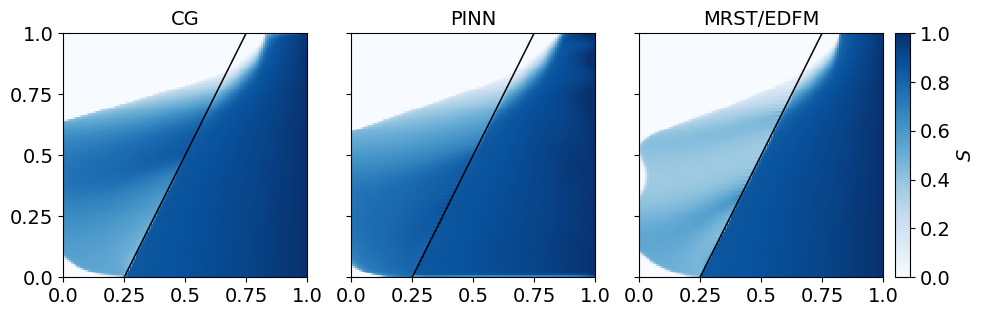

Rectangular saturation error relative to MRST:
  CG-MRST   mean|e|=8.270e-02 rmse=1.674e-01 max|e|=7.415e-01
  PINN-MRST mean|e|=8.547e-02 rmse=1.637e-01 max|e|=8.242e-01


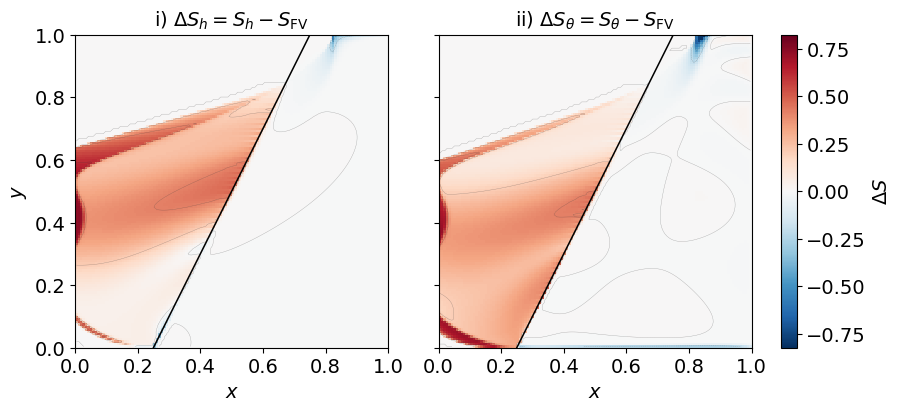

Global coupled water mass balance on the rectangular grid:
  method        M_matrix         M_frac        M_total      ext_in     ext_out          net        error     clip dM   clipped
  CG         6.321020e-01  3.927178e-02  6.713738e-01  9.983e-01  1.646e-01 8.336357e-01 -1.623e-01  0.000e+00        0
  PINN       6.292832e-01  4.864610e-02  6.779293e-01  1.002e+00  3.207e-01 6.809918e-01 -3.062e-03 -3.062e-03   514745
  MRST       5.532903e-01  1.001351e-01  6.534254e-01  1.000e+00  3.466e-01 6.534254e-01  2.514e-13  0.000e+00        0
  external in/out include matrix boundary flow and open fracture-tip flow; matrix-fracture exchange is internal.
  detailed water flux integrals and left-region water:
  CG     matrix in/out=(9.983e-01, 7.214e-02) tip in/out=(0.000e+00, 9.249e-02) interface exchange=-1.318e-01 left=4.349e-01
  PINN   matrix in/out=(1.002e+00, 7.581e-02) tip in/out=(0.000e+00, 2.449e-01) interface exchange=-2.935e-01 left=4.329e-01
  MRST   matrix in/out=(1.000e+00, 4

In [25]:
# Rectangular transport: plots + global water mass balance.
# Split out from the transport-solve cell so the plots/balance can be re-run
# WITHOUT re-running the (expensive) Buckley-Leverett solve above. It only reads
# the transport_rect_* arrays already populated by the previous cell.
_rect_s_min = float(np.nanmin(transport_rect_S)) if transport_rect_S.size else 0.0
_rect_s_max = float(np.nanmax(transport_rect_S)) if transport_rect_S.size else 1.0
_rect_extend = "neither"
if _rect_s_min < 0.0 and _rect_s_max > 1.0:
    _rect_extend = "both"
elif _rect_s_min < 0.0:
    _rect_extend = "min"
elif _rect_s_max > 1.0:
    _rect_extend = "max"

_x_rect_edges = np.linspace(xmin, xmax, sol["n_bulk"] + 1)
_y_rect_edges = np.linspace(ymin, ymax, sol["n_bulk"] + 1)
_rect_panel_titles = {"CG": "CG", "PINN": "PINN", "MRST": "MRST/EDFM"}
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4.5))
    pcm = None
    for ax, name in zip(axes, transport_rect_method_names):
        grid = rect_cell_field_to_structured_grid(transport_rect_saturation[name])
        pcm = ax.pcolormesh(_x_rect_edges, _y_rect_edges, grid, cmap="Blues", shading="flat", vmin=0.0, vmax=1.0)
        ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(_rect_panel_titles.get(name, name))
        ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.set_xticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.grid(False)
    axes[0].set_yticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    fig.subplots_adjust(left=0.06, right=0.88, bottom=0.08, top=0.95, wspace=0.18)
    fig.canvas.draw()  # finalize the equal-aspect (square) panel positions
    _pos = axes[-1].get_position()  # square panel box == domain [0,1] height
    _cax = fig.add_axes([_pos.x1 + 0.012, _pos.y0, 0.015, _pos.height])
    cbar = fig.colorbar(pcm, cax=_cax, extend=_rect_extend)
    cbar.set_label(r"$S$")
    plt.show()

transport_rect_error_method_names = np.asarray(["CG-MRST", "PINN-MRST"], dtype=object)
transport_rect_S_error = np.vstack([
    transport_rect_saturation["CG"] - transport_rect_saturation["MRST"],
    transport_rect_saturation["PINN"] - transport_rect_saturation["MRST"],
])
transport_rect_error_mean_abs = np.zeros(len(transport_rect_error_method_names), dtype=float)
transport_rect_error_rmse = np.zeros(len(transport_rect_error_method_names), dtype=float)
transport_rect_error_max_abs = np.zeros(len(transport_rect_error_method_names), dtype=float)
print("Rectangular saturation error relative to MRST:")
for _i, (_name, _err) in enumerate(zip(transport_rect_error_method_names, transport_rect_S_error)):
    _mask = np.isfinite(_err)
    if np.any(_mask):
        _e = _err[_mask]
        transport_rect_error_mean_abs[_i] = float(np.mean(np.abs(_e)))
        transport_rect_error_rmse[_i] = float(np.sqrt(np.mean(_e ** 2)))
        transport_rect_error_max_abs[_i] = float(np.max(np.abs(_e)))
    else:
        transport_rect_error_mean_abs[_i] = np.nan
        transport_rect_error_rmse[_i] = np.nan
        transport_rect_error_max_abs[_i] = np.nan
    print(
        f"  {_name:<9} mean|e|={transport_rect_error_mean_abs[_i]:.3e} "
        f"rmse={transport_rect_error_rmse[_i]:.3e} "
        f"max|e|={transport_rect_error_max_abs[_i]:.3e}"
    )

_rect_err_absmax = float(np.nanmax(np.abs(transport_rect_S_error))) if transport_rect_S_error.size else 0.0
if not np.isfinite(_rect_err_absmax) or _rect_err_absmax <= 0.0:
    _rect_err_absmax = 1.0e-15
_x_rect_centers = 0.5 * (_x_rect_edges[:-1] + _x_rect_edges[1:])
_y_rect_centers = 0.5 * (_y_rect_edges[:-1] + _y_rect_edges[1:])
_X_rect_centers, _Y_rect_centers = np.meshgrid(_x_rect_centers, _y_rect_centers)
_rect_error_titles = [
    r"i) $\Delta S_h=S_h-S_{\mathrm{FV}}$",
    r"ii) $\Delta S_\theta=S_\theta-S_{\mathrm{FV}}$",
]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    pcm_err = None
    _levels = np.linspace(-_rect_err_absmax, _rect_err_absmax, 9)
    for ax, title, err in zip(axes, _rect_error_titles, transport_rect_S_error):
        grid = rect_cell_field_to_structured_grid(err)
        pcm_err = ax.pcolormesh(
            _x_rect_edges,
            _y_rect_edges,
            grid,
            cmap="RdBu_r",
            shading="flat",
            vmin=-_rect_err_absmax,
            vmax=_rect_err_absmax,
        )
        if _rect_err_absmax > 1.0e-15:
            ax.contour(_X_rect_centers, _Y_rect_centers, grid, levels=_levels, colors="0.25", linewidths=0.25, alpha=0.45)
        ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    cbar = fig.colorbar(pcm_err, ax=axes.ravel().tolist(), fraction=0.035, pad=0.02)
    cbar.set_label(r"$\Delta S$")
    plt.show()

print("Global coupled water mass balance on the rectangular grid:")
print("  method        M_matrix         M_frac        M_total      ext_in     ext_out          net        error     clip dM   clipped")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} "
        f"{transport_rect_water_mass[_i]:16.6e} "
        f"{transport_rect_fracture_water_mass[_i]:13.6e} "
        f"{transport_rect_total_water_mass[_i]:13.6e} "
        f"{transport_rect_external_in[_i]:10.3e} "
        f"{transport_rect_external_out[_i]:10.3e} "
        f"{transport_rect_water_net[_i]:12.6e} "
        f"{transport_rect_water_balance_error[_i]:10.3e} "
        f"{transport_rect_clip_mass_delta[_i]:10.3e} "
        f"{transport_rect_clip_count[_i]:8d}"
    )
print("  external in/out include matrix boundary flow and open fracture-tip flow; matrix-fracture exchange is internal.")
print("  detailed water flux integrals and left-region water:")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} matrix in/out=({transport_rect_water_in[_i]:.3e}, {transport_rect_water_out[_i]:.3e}) "
        f"tip in/out=({transport_rect_tip_water_in[_i]:.3e}, {transport_rect_tip_water_out[_i]:.3e}) "
        f"interface exchange={transport_rect_water_exchange[_i]:+.3e} "
        f"left={transport_rect_left_region_water[_i]:.3e}"
    )
print("  pre-clip S ranges, matrix all / exchange cells / fracture:")
for _i, _name in enumerate(transport_rect_method_names):
    print(
        f"  {_name:<6} "
        f"all=[{transport_rect_S_preclip_min[_i]:+.3e}, {transport_rect_S_preclip_max[_i]:+.3e}] "
        f"cut=[{transport_rect_S_cut_preclip_min[_i]:+.3e}, {transport_rect_S_cut_preclip_max[_i]:+.3e}] "
        f"Gamma=[{transport_rect_S_frac_preclip_min[_i]:+.3e}, {transport_rect_S_frac_preclip_max[_i]:+.3e}]"
    )

if "MRST" in transport_rect_fracture_saturation:
    _Sg_mrst = np.asarray(transport_rect_fracture_saturation["MRST"], dtype=float)
    if len(_Sg_mrst) == len(mrst_s_frac):
        print(
            "  MRST fracture saturation on exported mrst_s_frac: "
            f"n={len(_Sg_mrst)}, min={_Sg_mrst.min():.3e}, max={_Sg_mrst.max():.3e}, "
            f"mean={_Sg_mrst.mean():.3e}"
        )
    else:
        print(
            "  MRST fracture saturation grid length differs from exported mrst_s_frac: "
            f"{len(_Sg_mrst)} vs {len(mrst_s_frac)}"
        )


Matrix saturation RMSE vs MRST native solver (s_matrix):
  CG   : 1.5255e-01
  PINN : 1.4726e-01
  MRST : 5.5331e-02
  notebook-MRST vs MRST matched-scheme : 5.5310e-02


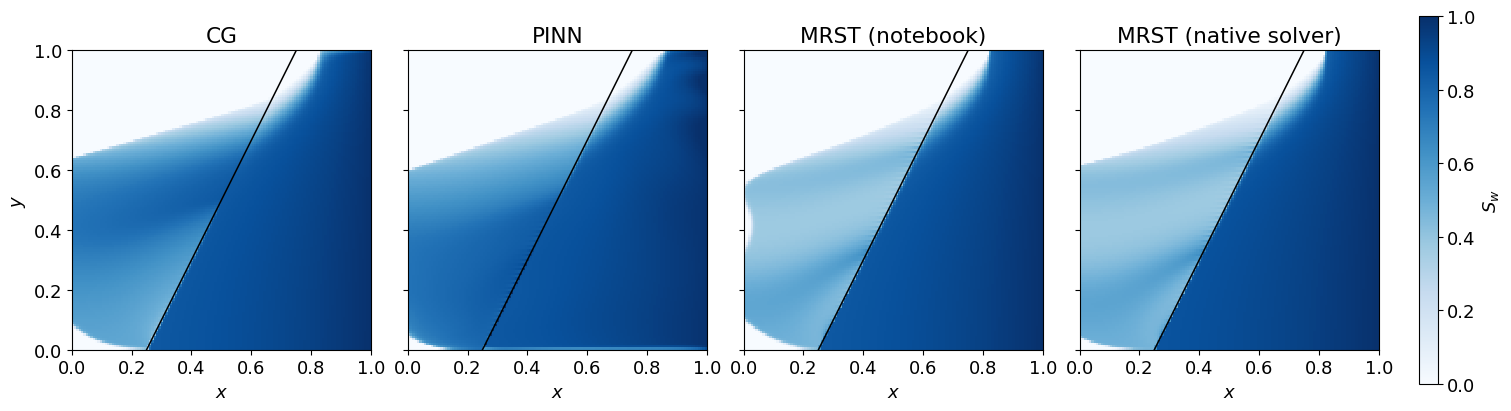

In [26]:
# 4-panel saturation comparison (RECT): CG / PINN / MRST(notebook) vs MRST(native solver).
# Panels 1-3 are the notebook's transport with each method's flux+exchange.
# Panel 4 is MRST's OWN explicitTransport (SINTEF) result, s_matrix, from the export
# -> panels 3 vs 4 = cross-validation; 1,2 vs 4 = CG/PINN against the trusted reference.

if "s_matrix" not in mrst:
    raise RuntimeError(
        "mrst['s_matrix'] not found - re-run the MRST-load cell (loadmat of case3_mrst_export.mat) "
        "so the updated export with the native-solver saturation is loaded."
    )

# Map MRST native-ordered s_matrix onto the notebook rect cells.
_s_native = np.asarray(mrst["s_matrix"], dtype=float).reshape(-1)
_mrst_to_cid = rect_mrst_to_bulk_cell_map()  # 1-based MRST index -> notebook cell id
_S_mrst_native = np.full(num_rect_cells, np.nan, dtype=float)
for _midx0 in range(len(_s_native)):
    _cid = int(_mrst_to_cid[_midx0 + 1])
    if _cid >= 0:
        _S_mrst_native[_cid] = _s_native[_midx0]
if np.any(np.isnan(_S_mrst_native)):
    raise RuntimeError("Some notebook cells were not covered by MRST s_matrix; check the cell mapping.")

# RMSE of each notebook field against the native MRST saturation (matrix).
def _rms(a, b):
    d = np.asarray(a, float) - np.asarray(b, float)
    return float(np.sqrt(np.mean(d * d)))
print("Matrix saturation RMSE vs MRST native solver (s_matrix):")
for _name in ["CG", "PINN", "MRST"]:
    print(f"  {_name:<4} : {_rms(transport_rect_saturation[_name], _S_mrst_native):.4e}")
if "s_matrix_matched" in mrst:
    _s_matched = np.asarray(mrst["s_matrix_matched"], dtype=float).reshape(-1)
    _S_matched = np.full(num_rect_cells, np.nan, dtype=float)
    for _midx0 in range(len(_s_matched)):
        _cid = int(_mrst_to_cid[_midx0 + 1])
        if _cid >= 0:
            _S_matched[_cid] = _s_matched[_midx0]
    print(f"  notebook-MRST vs MRST matched-scheme : {_rms(transport_rect_saturation['MRST'], _S_matched):.4e}")

_panels = [
    ("CG", transport_rect_saturation["CG"]),
    ("PINN", transport_rect_saturation["PINN"]),
    ("MRST (notebook)", transport_rect_saturation["MRST"]),
    ("MRST (native solver)", _S_mrst_native),
]
_xe = np.linspace(xmin, xmax, sol["n_bulk"] + 1)
_ye = np.linspace(ymin, ymax, sol["n_bulk"] + 1)
with plt.rc_context({"font.size": 13}):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
    pcm = None
    for ax, (title, vals) in zip(axes, _panels):
        grid = rect_cell_field_to_structured_grid(np.asarray(vals, dtype=float))
        pcm = ax.pcolormesh(_xe, _ye, grid, cmap="Blues", shading="flat", vmin=0.0, vmax=1.0)
        ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.1)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_xlabel(r"$x$")
        ax.grid(False)
    axes[0].set_ylabel(r"$y$")
    for ax in axes[1:]:
        ax.tick_params(labelleft=False)
    cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label(r"$S_w$")
    plt.show()


Fracture S_Gamma RMSE: notebook-MRST vs native sw_frac = 2.1212e-03


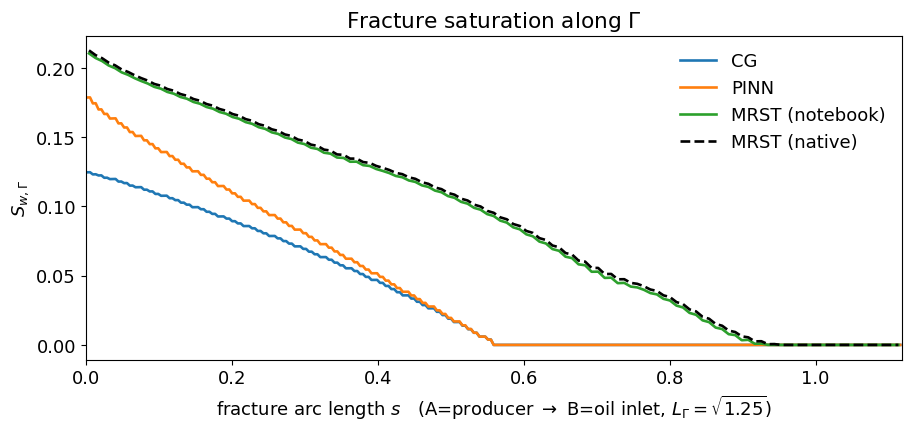

In [27]:
# 1-D fracture saturation S_Gamma(s) along the fracture: CG / PINN / MRST(notebook) / MRST(native).
# x-axis = arc length s/L_Gamma, from tip A (s=0, producer) to tip B (s=1, oil inlet).
if "sw_frac" not in mrst:
    raise RuntimeError("mrst['sw_frac'] not found - re-run the MRST-load cell to load the updated export.")

# native fracture saturation (sw_frac) on the restored arc-length coordinate (s_frac)
_s_nat = np.asarray(mrst["s_frac"], dtype=float).reshape(-1)
_sw_nat = np.asarray(mrst["sw_frac"], dtype=float).reshape(-1)
_onat = np.argsort(_s_nat)
_s_nat, _sw_nat = _s_nat[_onat], _sw_nat[_onat]

_frac_series = [
    ("CG",              transport_rect_fractures["CG"]["s_centers"],   transport_rect_fracture_saturation["CG"],   "C0", "-"),
    ("PINN",            transport_rect_fractures["PINN"]["s_centers"], transport_rect_fracture_saturation["PINN"], "C1", "-"),
    ("MRST (notebook)", transport_rect_fractures["MRST"]["s_centers"], transport_rect_fracture_saturation["MRST"], "C2", "-"),
    ("MRST (native)",   _s_nat,                                        _sw_nat,                                    "k",  "--"),
]

# fracture cross-validation: notebook-MRST vs native (same 125-cell MRST grid)
_Sg_nb = np.asarray(transport_rect_fracture_saturation["MRST"], dtype=float)
_s_nb = np.asarray(transport_rect_fractures["MRST"]["s_centers"], dtype=float)
if len(_Sg_nb) == len(_sw_nat):
    _onb = np.argsort(_s_nb)
    _rmse_frac = float(np.sqrt(np.mean((_Sg_nb[_onb] - _sw_nat) ** 2)))
    print(f"Fracture S_Gamma RMSE: notebook-MRST vs native sw_frac = {_rmse_frac:.4e}")
else:
    print(f"(notebook-MRST fracture grid {len(_Sg_nb)} != native {len(_sw_nat)}; skipping direct RMSE)")

with plt.rc_context({"font.size": 13}):
    fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
    for name, s, sg, col, ls in _frac_series:
        s = np.asarray(s, dtype=float)
        sg = np.asarray(sg, dtype=float)
        order = np.argsort(s)
        ax.plot(s[order], sg[order], ls, color=col, lw=1.9, label=name)
    ax.set_xlabel(r"fracture arc length $s$   (A=producer $\to$ B=oil inlet, $L_\Gamma=\sqrt{1.25}$)")
    ax.set_ylabel(r"$S_{w,\Gamma}$")
    ax.set_xlim(0.0, L_gamma)
    ax.set_title(r"Fracture saturation along $\Gamma$")
    ax.legend(frameon=False, loc="best")
    ax.grid(False)
    plt.show()


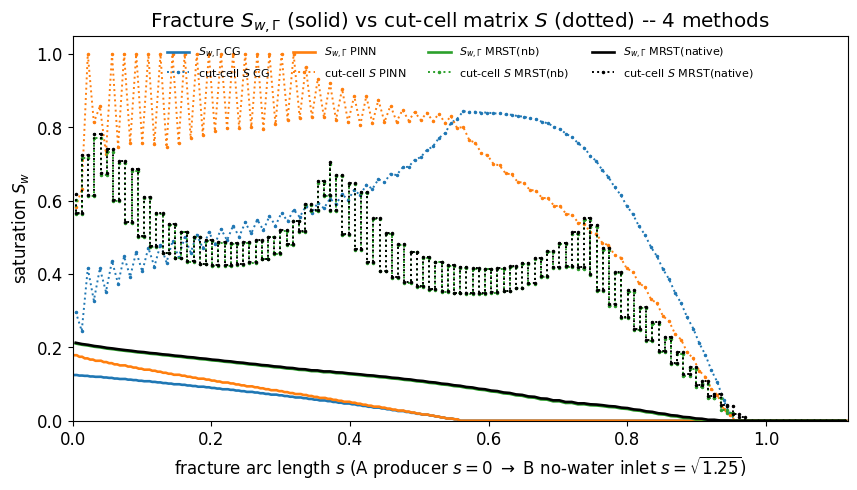

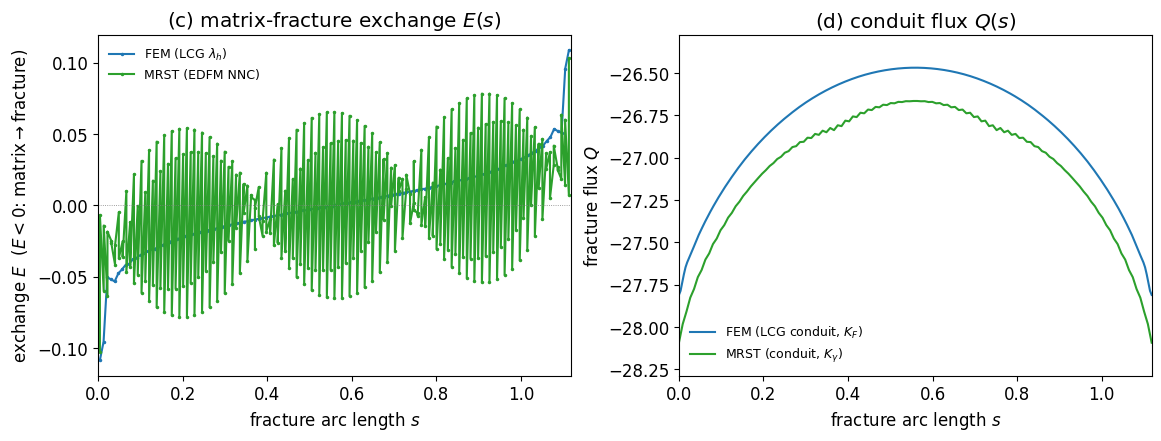

H1 conduit flux (FEM/LCG vs MRST):
  K_F(LCG)=10  meta_Kgamma(MRST)=10  ratio=1
  median|Q|: FEM=2.6712e+01  MRST=2.6932e+01  ratio=0.992
  max|Q|:    FEM=2.7811e+01  MRST=2.8093e+01
  total|E| (collect+discharge): FEM=2.7333e+00  MRST=9.8709e+00
  upper s/L>0.6 [FEM]: conns=51 collect(E<0)=0 sumE_collect=+0.000e+00 sumE_discharge=+1.329e+00
  upper s/L>0.6 [MRST]: conns=101 collect(E<0)=40 sumE_collect=-1.177e+00 sumE_discharge=+2.554e+00


In [28]:
# Fracture diagnostics along arc length s -- TWO figures.
# Fig 1: S_w,Gamma (solid) AND cut-cell matrix S (dotted) for all 4 methods, on one saturation axis.
#        Each method's cut-cell S uses ITS OWN matrix-fracture coupling cells:
#          CG, PINN          -> LCG lambda_h cut cells (shared), CG/PINN bulk fields
#          MRST(nb), MRST(nat)-> MRST EDFM NNC cut cells, notebook / native matrix fields
# Fig 2: (c) exchange E(s) and (d) fracture flux Q(s) for FEM (=CG, LCG path) vs MRST.

if "sw_frac" not in mrst:
    raise RuntimeError("mrst['sw_frac'] not found - re-run the MRST-load cell.")
_s_nat = np.asarray(mrst["s_frac"], dtype=float).reshape(-1)
_sw_nat = np.asarray(mrst["sw_frac"], dtype=float).reshape(-1)
_onat = np.argsort(_s_nat); _s_nat, _sw_nat = _s_nat[_onat], _sw_nat[_onat]

# native matrix saturation mapped onto the notebook rect cells (same mapping as the 4-panel cell)
if "s_matrix" not in mrst:
    raise RuntimeError("mrst['s_matrix'] not found - re-run the MRST-load cell.")
_s_matrix_native = np.asarray(mrst["s_matrix"], dtype=float).reshape(-1)
_mrst_to_cid = rect_mrst_to_bulk_cell_map()
_S_mrst_native = np.full(num_rect_cells, np.nan, dtype=float)
for _midx0 in range(len(_s_matrix_native)):
    _cid = int(_mrst_to_cid[_midx0 + 1])
    if _cid >= 0:
        _S_mrst_native[_cid] = _s_matrix_native[_midx0]

_ex_lcg = transport_rect_exchanges["CG"]     # LCG lambda_h cells (shared by CG/PINN/FEM)
_ex_mr = transport_rect_exchanges["MRST"]    # MRST EDFM NNC connections


def _cut_profile(exchange, sat):
    cv = np.asarray(exchange["conn_cv_ids"], dtype=np.int32)
    s = np.asarray(exchange["conn_s"], dtype=float)
    m = np.isfinite(s)
    cv, s = cv[m], s[m]
    sc = np.asarray(sat, dtype=float)[cv]
    o = np.argsort(s)
    return s[o], sc[o]


# ---------------- Figure 1: S_Gamma + cut-cell matrix S, 4 methods ----------------
# (label, s_for_SGamma, SGamma, exchange_for_cut, sat_for_cut, color)
_methods = [
    ("CG",           transport_rect_fractures["CG"]["s_centers"],   transport_rect_fracture_saturation["CG"],   _ex_lcg, transport_rect_saturation["CG"],   "C0"),
    ("PINN",         transport_rect_fractures["PINN"]["s_centers"], transport_rect_fracture_saturation["PINN"], _ex_lcg, transport_rect_saturation["PINN"], "C1"),
    ("MRST(nb)",     transport_rect_fractures["MRST"]["s_centers"], transport_rect_fracture_saturation["MRST"], _ex_mr,  transport_rect_saturation["MRST"], "C2"),
    ("MRST(native)", _s_nat,                                        _sw_nat,                                    _ex_mr,  _S_mrst_native,                    "k"),
]

with plt.rc_context({"font.size": 12}):
    fig1, ax1 = plt.subplots(figsize=(10.0, 5.0))
    for lab, sg, yg, exch, sat, col in _methods:
        sg = np.asarray(sg, dtype=float); yg = np.asarray(yg, dtype=float); o = np.argsort(sg)
        ax1.plot(sg[o], yg[o], "-", color=col, lw=1.9, label=rf"$S_{{w,\Gamma}}$ {lab}")
        scs, scv = _cut_profile(exch, sat)
        ax1.plot(scs, scv, ":", color=col, lw=1.4, marker=".", ms=3, label=f"cut-cell $S$ {lab}")
    ax1.set_xlabel(r"fracture arc length $s$ (A producer $s=0$ $\to$ B no-water inlet $s=\sqrt{1.25}$)")
    ax1.set_ylabel(r"saturation $S_w$")
    ax1.set_xlim(0.0, L_gamma); ax1.set_ylim(bottom=0.0)
    ax1.legend(frameon=False, fontsize=8, ncol=4, loc="upper center")
    ax1.set_title(r"Fracture $S_{w,\Gamma}$ (solid) vs cut-cell matrix $S$ (dotted) -- 4 methods")
    plt.show()

# ---------------- Figure 2: (c) exchange E(s) and (d) flux Q(s), FEM vs MRST ----------------
def _exch_profile(exchange):
    s = np.asarray(exchange["conn_s"], dtype=float)
    e = np.asarray(exchange["conn_E"], dtype=float)
    m = np.isfinite(s)
    s, e = s[m], e[m]
    o = np.argsort(s)
    return s[o], e[o]


def _flux_profile(fracture):
    s = np.asarray(fracture["s_faces"], dtype=float)
    q = np.asarray(fracture["Q_face"], dtype=float)
    o = np.argsort(s)
    return s[o], q[o]


_sE_fem, _E_fem = _exch_profile(_ex_lcg)
_sE_mr, _E_mr = _exch_profile(_ex_mr)
_sQ_fem, _Q_fem = _flux_profile(transport_rect_fractures["CG"])
_sQ_mr, _Q_mr = _flux_profile(transport_rect_fractures["MRST"])

with plt.rc_context({"font.size": 12}):
    fig2, (axE, axQ) = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
    axE.plot(_sE_fem, _E_fem, "-", color="C0", lw=1.5, marker=".", ms=3, label="FEM (LCG $\\lambda_h$)")
    axE.plot(_sE_mr, _E_mr, "-", color="C2", lw=1.5, marker=".", ms=3, label="MRST (EDFM NNC)")
    axE.axhline(0.0, color="0.5", lw=0.6, ls=":")
    axE.set_xlabel(r"fracture arc length $s$"); axE.set_ylabel(r"exchange $E$  ($E<0$: matrix$\to$fracture)")
    axE.set_xlim(0.0, L_gamma); axE.set_title("(c) matrix-fracture exchange $E(s)$")
    axE.legend(frameon=False, fontsize=9)

    axQ.plot(_sQ_fem, _Q_fem, "-", color="C0", lw=1.5, label="FEM (LCG conduit, $K_F$)")
    axQ.plot(_sQ_mr, _Q_mr, "-", color="C2", lw=1.5, label=r"MRST (conduit, $K_\gamma$)")
    axQ.set_xlabel(r"fracture arc length $s$"); axQ.set_ylabel(r"fracture flux $Q$")
    axQ.set_xlim(0.0, L_gamma); axQ.set_title("(d) conduit flux $Q(s)$")
    _qcat = np.concatenate([_Q_fem, _Q_mr]); _qcat = _qcat[np.isfinite(_qcat)]
    if _qcat.size:
        _qlo, _qhi = float(_qcat.min()), float(_qcat.max())
        _qpad = 0.12 * max(_qhi - _qlo, 1e-30)
        axQ.set_ylim(_qlo - _qpad, _qhi + _qpad)  # zoom to the flux band (exclude 0) so FEM vs MRST is visible
    axQ.legend(frameon=False, fontsize=9)
    plt.show()

# ---------------- Quantitative H1 (over-flush) / H2 (under-collection) summary ----------------
_Kg = float(np.asarray(mrst.get("meta_Kgamma", K_F_VALUE)).reshape(-1)[0])
print("H1 conduit flux (FEM/LCG vs MRST):")
print(f"  K_F(LCG)={K_F_VALUE:.4g}  meta_Kgamma(MRST)={_Kg:.4g}  ratio={K_F_VALUE/max(_Kg,1e-30):.3g}")
print(f"  median|Q|: FEM={np.median(np.abs(_Q_fem)):.4e}  MRST={np.median(np.abs(_Q_mr)):.4e}  ratio={np.median(np.abs(_Q_fem))/max(np.median(np.abs(_Q_mr)),1e-30):.3g}")
print(f"  max|Q|:    FEM={np.max(np.abs(_Q_fem)):.4e}  MRST={np.max(np.abs(_Q_mr)):.4e}")
print(f"  total|E| (collect+discharge): FEM={np.sum(np.abs(_E_fem)):.4e}  MRST={np.sum(np.abs(_E_mr)):.4e}")
for _lab, _s, _e in [("FEM", _sE_fem, _E_fem), ("MRST", _sE_mr, _E_mr)]:
    _u = _s > 0.6 * L_gamma
    _c = _e < 0.0
    print(f"  upper s/L>0.6 [{_lab}]: conns={int(_u.sum())} collect(E<0)={int((_u&_c).sum())} "
          f"sumE_collect={float(_e[_u&_c].sum()):+.3e} sumE_discharge={float(_e[_u&~_c].sum()):+.3e}")


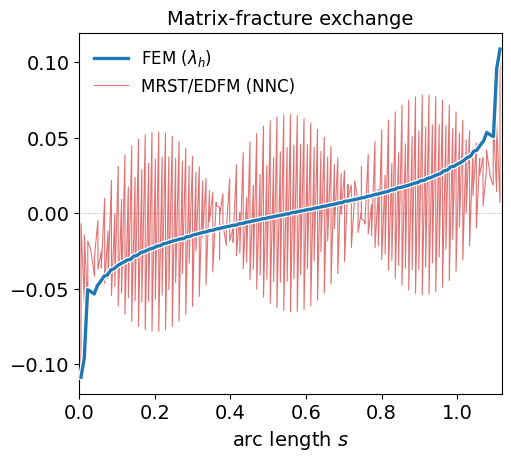

In [33]:
# Publication figure: matrix-fracture exchange E(s) along the fracture.
# FEM (LCG lambda_h, smooth) vs MRST/EDFM (NNC, sub-cell oscillation). Standalone:
# reads only the persistent transport_rect_exchanges + L_gamma.
def _Es_profile(exch):
    s = np.asarray(exch["conn_s"], dtype=float)
    e = np.asarray(exch["conn_E"], dtype=float)
    m = np.isfinite(s)
    s, e = s[m], e[m]
    o = np.argsort(s)
    return s[o], e[o]

_s_fem, _e_fem = _Es_profile(transport_rect_exchanges["CG"])    # LCG lambda_h
_s_mr,  _e_mr  = _Es_profile(transport_rect_exchanges["MRST"])  # EDFM NNC
import matplotlib.patheffects as pe

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14,
                     "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, ax = plt.subplots(figsize=(5.0, 4.5), constrained_layout=True)
    ax.axhline(0.0, color="0.6", lw=0.6, ls=":", zorder=1)
    ax.plot(_s_fem, _e_fem, "-", color="tab:blue", lw=2.4, zorder=3,
            path_effects=[pe.Stroke(linewidth=4.2, foreground="white"), pe.Normal()],
            label=r"FEM ($\lambda_h$)")
    ax.plot(_s_mr,  _e_mr,  "-", color="tab:red",  lw=0.8, alpha=0.65, zorder=2,
            label="MRST/EDFM (NNC)")
    ax.set_xlabel(r"arc length $s$")
    # ax.set_ylabel(r"exchange $E$")
    ax.set_xlim(0.0, L_gamma)
    ax.set_title(r"Matrix-fracture exchange")
    ax.legend(frameon=False, fontsize=12, loc="best")
    plt.show()


In [29]:
transport_drainage_metric_keys = np.asarray([
    "water_injected",
    "fracture_exchange_water_in",
    "fracture_exchange_water_out",
    "fracture_water_drainage",
    "fracture_exchange_water_in_by_injected",
    "fracture_exchange_water_out_by_injected",
    "fracture_water_drainage_by_injected",
    "fracture_exchange_water_in_collect_zone",
    "fracture_exchange_water_in_discharge_zone",
    "fracture_exchange_water_out_collect_zone",
    "fracture_exchange_water_out_discharge_zone",
    "fracture_spurious_drainage",
    "fracture_spurious_drainage_by_injected",
    "fracture_collect_zone_cell_count",
    "fracture_discharge_zone_cell_count",
    "matrix_exchange_collect_zone_cell_count",
    "matrix_exchange_discharge_zone_cell_count",
    "matrix_gamma_crossing_face_count",
    "matrix_gamma_crossing_water_signed",
    "matrix_gamma_crossing_water_right_to_left",
    "matrix_gamma_crossing_water_abs",
    "matrix_gamma_crossing_water_plus_to_minus",
    "matrix_gamma_crossing_water_minus_to_plus",
    "matrix_gamma_crossing_water_signed_by_injected",
    "matrix_gamma_crossing_water_right_to_left_by_injected",
    "matrix_gamma_crossing_water_abs_by_injected",
    "matrix_gamma_crossing_water_plus_to_minus_by_injected",
    "matrix_gamma_crossing_water_minus_to_plus_by_injected",
    "matrix_gamma_crossing_fluid_signed",
    "matrix_gamma_crossing_fluid_right_to_left",
    "matrix_gamma_crossing_fluid_abs",
    "matrix_gamma_crossing_fluid_plus_to_minus",
    "matrix_gamma_crossing_fluid_minus_to_plus",
    "matrix_gamma_crossing_fluid_signed_by_injected",
    "matrix_gamma_crossing_fluid_right_to_left_by_injected",
    "matrix_gamma_crossing_fluid_abs_by_injected",
    "matrix_gamma_crossing_fluid_plus_to_minus_by_injected",
    "matrix_gamma_crossing_fluid_minus_to_plus_by_injected",
    "matrix_boundary_water_production",
    "fracture_tipA_water_production",
    "fracture_tipB_water_production",
    "fracture_tip_water_production",
    "fracture_tipA_fluid_production",
    "fracture_tipB_fluid_production",
    "fracture_tip_fluid_production",
    "fracture_tipA_fluid_production_by_injected",
    "fracture_tip_fluid_production_by_injected",
    "matrix_water_storage_phi_negative",
    "matrix_water_storage_phi_positive",
    "matrix_water_storage_phi_negative_by_injected",
    "matrix_water_storage_phi_positive_by_injected",
    "gamma_fluid_balance_residual_phi_negative",
    "gamma_fluid_balance_residual_phi_positive",
    "gamma_fluid_balance_residual_phi_negative_by_injected",
    "gamma_fluid_balance_residual_phi_positive_by_injected",
    "total_domain_water_production",
    "fracture_tipA_production_by_injected",
    "fracture_tip_water_production_by_injected",
    "matrix_boundary_production_by_injected",
    "fracture_tipA_production_fraction",
    "fracture_tip_production_fraction",
    "matrix_boundary_production_fraction",
], dtype=str)


def collect_transport_drainage_metrics(meta_by_name, method_names, metric_keys=transport_drainage_metric_keys):
    method_names = np.asarray(method_names, dtype=object)
    out = np.full((len(method_names), len(metric_keys)), np.nan, dtype=float)
    for i, name in enumerate(method_names):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        for j, key in enumerate(metric_keys):
            val = meta.get(str(key), np.nan)
            try:
                out[i, j] = float(val)
            except (TypeError, ValueError):
                out[i, j] = np.nan
    return out



def _scalar_from_mrst(key, default=np.nan):
    if "mrst" not in globals() or key not in mrst:
        return default
    arr = np.asarray(mrst[key]).reshape(-1)
    return float(arr[0]) if arr.size else default


def _rel_rmse(diff, ref):
    diff = np.asarray(diff, dtype=float)
    ref = np.asarray(ref, dtype=float)
    mask = np.isfinite(diff) & np.isfinite(ref)
    if not np.any(mask):
        return np.nan, np.nan
    rmse = float(np.sqrt(np.mean(diff[mask] ** 2)))
    denom = float(np.sqrt(np.mean(ref[mask] ** 2)))
    return rmse, rmse / denom if denom > 1.0e-30 else np.nan


def _candidate_frac_face_flux_from_pressure(Keff):
    if "mrst" not in globals() or "frac_face_neighbors" not in mrst:
        return np.array([])
    neigh = np.asarray(mrst["frac_face_neighbors"], dtype=np.int64)
    p = np.asarray(mrst["p_frac"], dtype=float).reshape(-1)
    s = np.asarray(mrst.get("s_frac", mrst.get("lam_s", [])), dtype=float).reshape(-1)
    nc = int(_scalar_from_mrst("meta_nc", len(mrst_xc_matrix) if "mrst_xc_matrix" in globals() else 0))
    i = neigh[:, 0] - nc - 1
    j = neigh[:, 1] - nc - 1
    valid = (i >= 0) & (i < len(p)) & (j >= 0) & (j < len(p))
    out = np.full(len(neigh), np.nan, dtype=float)
    ds = np.abs(s[j[valid]] - s[i[valid]])
    ok = ds > 1.0e-30
    vv = np.nonzero(valid)[0][ok]
    ii = i[vv]
    jj = j[vv]
    out[vv] = -float(Keff) * (p[jj] - p[ii]) / np.abs(s[jj] - s[ii])
    return out


def print_mrst_conduit_audit():
    if "mrst" not in globals():
        print("MRST conduit/conductance audit unavailable: mrst export is not loaded.")
        return
    aperture = _scalar_from_mrst("meta_aperture")
    meta_kf = _scalar_from_mrst("meta_kf")
    meta_Kgamma = _scalar_from_mrst("meta_Kgamma")
    K_notebook = float(globals().get("K_F_VALUE", np.nan))
    print("MRST conduit/conductance audit:")
    print(f"  meta_aperture={aperture:.6g}  meta_kf={meta_kf:.6g}  meta_Kgamma={meta_Kgamma:.6g}  notebook K_Gamma={K_notebook:.6g}")
    print(f"  meta_kf*aperture={meta_kf * aperture:.6g}  meta_Kgamma*aperture={meta_Kgamma * aperture:.6g}")
    print(f"  checks: meta_Kgamma==K_Gamma {np.isclose(meta_Kgamma, K_notebook)}; meta_kf*aperture==K_Gamma {np.isclose(meta_kf * aperture, K_notebook)}; meta_Kgamma*aperture==K_Gamma {np.isclose(meta_Kgamma * aperture, K_notebook)}")

    mrst_dir = pathlib.Path(globals().get("MRST_CASE3_PATH", "case3_ecmor/case3_mrst_export.mat")).parent
    scripts = sorted(mrst_dir.glob("*.m"))
    print("  export scripts found:", ", ".join(str(s.name) for s in scripts) if scripts else "none in export directory")
    readme_path = mrst_dir / "case3_mrst_export_README.md"
    if readme_path.exists():
        print("  README conductance lines:")
        for line in readme_path.read_text(encoding="utf-8").splitlines():
            if any(key in line for key in ("meta_aperture", "meta_kf", "meta_Kgamma")):
                print("    " + line.strip())
    elif "README" in mrst:
        print("  README field present in .mat; external README file not found.")

    if "frac_face_flux" in mrst:
        native = np.asarray(mrst["frac_face_flux"], dtype=float).reshape(-1)
        native_abs_mean = float(np.mean(np.abs(native))) if native.size else np.nan
        native_abs_median = float(np.median(np.abs(native))) if native.size else np.nan
        native_abs_max = float(np.max(np.abs(native))) if native.size else np.nan
        print(f"  MRST native frac_face_flux |Q|: mean={native_abs_mean:.6e} median={native_abs_median:.6e} max={native_abs_max:.6e}")
        candidates = [
            ("notebook K_Gamma", K_notebook),
            ("meta_Kgamma", meta_Kgamma),
            ("meta_kf", meta_kf),
            ("meta_kf*aperture", meta_kf * aperture),
            ("meta_Kgamma*aperture", meta_Kgamma * aperture),
        ]
        print("  pressure-gradient reconstruction vs native frac_face_flux:")
        for label, Keff in candidates:
            if not np.isfinite(Keff):
                continue
            pred = _candidate_frac_face_flux_from_pressure(Keff)
            if pred.size != native.size:
                continue
            rmse_same, rel_same = _rel_rmse(pred - native, native)
            rmse_flip, rel_flip = _rel_rmse(-pred - native, native)
            sign = +1 if rmse_same <= rmse_flip else -1
            rmse = rmse_same if sign > 0 else rmse_flip
            rel = rel_same if sign > 0 else rel_flip
            ratio = float(np.nanmedian(np.abs(pred)) / np.nanmedian(np.abs(native))) if np.nanmedian(np.abs(native)) > 1.0e-30 else np.nan
            print(f"    {label:<22} K={Keff:.6g} sign={sign:+d} rmse={rmse:.3e} rel={rel:.3e} median|pred|/|native|={ratio:.3e}")

    if "tip_flux" in mrst:
        tip = np.asarray(mrst["tip_flux"], dtype=float).reshape(-1)
        print(f"  MRST native tip_flux={tip.tolist()}  tip throughput 0.5*sum|tip|={0.5 * np.sum(np.abs(tip)):.6e}")
    if "nnc_flux_m2f" in mrst:
        nnc = np.asarray(mrst["nnc_flux_m2f"], dtype=float).reshape(-1)
        lam = np.asarray(mrst.get("lam_flux", []), dtype=float).reshape(-1)
        print(f"  MRST NNC exchange: sum={np.sum(nnc):+.6e} sum|nnc|={np.sum(np.abs(nnc)):.6e} sum|lam_flux|={np.sum(np.abs(lam)):.6e}")

    if "transport_fracture_lcg" in globals():
        q_lcg = np.asarray(transport_fracture_lcg.get("Q_face", []), dtype=float)
        if q_lcg.size:
            q_int = q_lcg[1:-1] if q_lcg.size > 2 else q_lcg
            fem_mean = float(np.mean(np.abs(q_int))) if q_int.size else np.nan
            fem_tip = 0.5 * float(np.abs(q_lcg[0]) + np.abs(q_lcg[-1])) if q_lcg.size >= 2 else np.nan
            print(f"  FEM/LCG q_Gamma |Q|: internal mean={fem_mean:.6e} tip throughput={fem_tip:.6e}")
            if "frac_face_flux" in mrst and q_int.size:
                print(f"  MRST/FEM throughput ratios: native internal mean / FEM internal mean={native_abs_mean / fem_mean:.6e}; native tip / FEM tip={(0.5 * np.sum(np.abs(np.asarray(mrst.get('tip_flux', []), dtype=float).reshape(-1))) / fem_tip):.6e}")



def _meta_float(meta, key, default=np.nan):
    try:
        value = meta.get(key, default)
    except AttributeError:
        value = default
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def _safe_ratio(num, den):
    num = float(num)
    den = float(den)
    return num / den if np.isfinite(num) and np.isfinite(den) and abs(den) > 1.0e-30 else np.nan


def _transport_context(label):
    label = str(label).lower()
    if "rect" in label:
        return {
            "fluxes": globals().get("transport_rect_fluxes", {}),
            "fractures": globals().get("transport_rect_fractures", {}),
            "centers": globals().get("cell_centroids", np.zeros((0, 2))),
            "T": globals().get("TRANSPORT_RECT_T_FIXED", np.nan),
        }
    return {
        "fluxes": globals().get("transport_fluxes", {}),
        "fractures": globals().get("transport_fractures", {}),
        "centers": globals().get("zeta_centers", np.zeros((0, 2))),
        "T": globals().get("TRANSPORT_T_FIXED", np.nan),
    }


def _gamma_fluid_right_to_left_from_fluxes(oriented, centers, T):
    if not callable(globals().get("transport_gamma_crossing_face_data", None)):
        return np.nan
    if not isinstance(oriented, dict) or "F_out" not in oriented:
        return np.nan
    centers = np.asarray(centers, dtype=float)
    if centers.size == 0 or not np.isfinite(T):
        return np.nan
    gamma_cross = transport_gamma_crossing_face_data(oriented, centers)
    ids = gamma_cross.get("ids", np.array([], dtype=np.int64))
    pm_sign = gamma_cross.get("plus_to_minus_sign", np.array([], dtype=float))
    if len(ids) == 0:
        return 0.0
    signed_plus_to_minus = float(np.sum(np.asarray(oriented["F_out"], dtype=float)[ids] * pm_sign))
    return -float(T) * signed_plus_to_minus


def _tipA_fluid_from_fracture(fracture, T):
    if not isinstance(fracture, dict) or not np.isfinite(T):
        return np.nan
    q = np.asarray(fracture.get("Q_face", []), dtype=float)
    if q.size == 0:
        return np.nan
    return float(T) * max(-float(q[0]), 0.0)


def _fluid_partition_values(label, method_name, meta):
    ctx = _transport_context(label)
    name = str(method_name)
    T = _meta_float(meta, "T_final", ctx["T"])
    right_inflow_rate = _meta_float(meta, "right_inflow", np.nan)
    right_inflow = right_inflow_rate * T if np.isfinite(right_inflow_rate) and np.isfinite(T) else np.nan
    fg_rl = _meta_float(meta, "matrix_gamma_crossing_fluid_right_to_left", np.nan)
    if not np.isfinite(fg_rl):
        fg_rl = _gamma_fluid_right_to_left_from_fluxes(ctx["fluxes"].get(name, {}), ctx["centers"], T)
    tipA = _meta_float(meta, "fracture_tipA_fluid_production", np.nan)
    if not np.isfinite(tipA):
        tipA = _tipA_fluid_from_fracture(ctx["fractures"].get(name, {}), T)
    total = right_inflow + tipA if np.isfinite(right_inflow) and np.isfinite(tipA) else np.nan
    rate_equiv = total / T if np.isfinite(total) and np.isfinite(T) and T > 1.0e-30 else np.nan
    return fg_rl, tipA, right_inflow, total, rate_equiv


def print_transport_drainage_metrics(label, meta_by_name, method_names):
    metric_keys = transport_drainage_metric_keys
    metrics = collect_transport_drainage_metrics(meta_by_name, method_names, metric_keys)
    key_to_col = {key: j for j, key in enumerate(metric_keys)}
    print(f"{label} drainage/pathway metrics (normalized by cumulative injected water W_inj):")
    print("  D_spur uses matrix-cell net E zones; Gamma crossing is one face layer, signed right-to-left.")
    if metrics.size and np.all(~np.isfinite(metrics[:, key_to_col["fracture_water_drainage_by_injected"]])):
        print("  unavailable: rerun the transport solve cells after this metric patch to populate meta.")
        return metrics
    print(
        "  method   W_inj       G_in/W   G_out/W  D_w/W    "
        "D_spur/W  WgRL/W   WgGross/W  P_tipA/W  tipA/prod  matrix/prod"
    )
    for i, name in enumerate(np.asarray(method_names, dtype=object)):
        row = metrics[i]
        print(
            f"  {str(name):<6} "
            f"{row[key_to_col['water_injected']]:10.3e} "
            f"{row[key_to_col['fracture_exchange_water_in_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_exchange_water_out_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_water_drainage_by_injected']]:8.3e} "
            f"{row[key_to_col['fracture_spurious_drainage_by_injected']]:8.3e} "
            f"{row[key_to_col['matrix_gamma_crossing_water_right_to_left_by_injected']]:8.3e} "
            f"{row[key_to_col['matrix_gamma_crossing_water_abs_by_injected']]:10.3e} "
            f"{row[key_to_col['fracture_tipA_production_by_injected']]:9.3e} "
            f"{row[key_to_col['fracture_tipA_production_fraction']]:9.3e} "
            f"{row[key_to_col['matrix_boundary_production_fraction']]:11.3e}"
        )
    print("  water balance: W_inj = matrix_boundary_water_out + P_tipA + storage")
    print("  method   out_m/W  P_tipA/W  storage/W  residual/W")
    for name in np.asarray(method_names, dtype=object):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        W_inj = _meta_float(meta, "water_injected", np.nan)
        if not np.isfinite(W_inj):
            W_inj = _meta_float(meta, "water_flux", np.nan) * _meta_float(meta, "T_final", np.nan)
        if not np.isfinite(W_inj):
            W_inj = _meta_float(meta, "water_in", np.nan)
        out_m = _meta_float(meta, "matrix_boundary_water_production", _meta_float(meta, "water_out", np.nan))
        P_tipA = _meta_float(meta, "fracture_tipA_water_production", _meta_float(meta, "tip_water_out", np.nan))
        storage = _meta_float(meta, "total_water_mass", np.nan)
        if not np.isfinite(storage):
            storage = _meta_float(meta, "water_mass", 0.0) + _meta_float(meta, "fracture_water_mass", 0.0)
        residual = W_inj - out_m - P_tipA - storage
        print(
            f"  {str(name):<6} "
            f"{_safe_ratio(out_m, W_inj):8.3e} "
            f"{_safe_ratio(P_tipA, W_inj):9.3e} "
            f"{_safe_ratio(storage, W_inj):9.3e} "
            f"{_safe_ratio(residual, W_inj):10.3e}"
        )
    print("  fluid partition: signed fluid rates/volumes only, not water; fracture conduit fluid is mostly oil here.")
    print("  method   FgRL/fluid  tipA_fluid/fluid  matrix_in/fluid  total_fluid_rate")
    for name in np.asarray(method_names, dtype=object):
        meta = meta_by_name.get(str(name), {}) if isinstance(meta_by_name, dict) else {}
        fg_rl, tipA_fluid, matrix_in, total_fluid, rate_equiv = _fluid_partition_values(label, name, meta)
        print(
            f"  {str(name):<6} "
            f"{_safe_ratio(fg_rl, total_fluid):11.3e} "
            f"{_safe_ratio(tipA_fluid, total_fluid):16.3e} "
            f"{_safe_ratio(matrix_in, total_fluid):15.3e} "
            f"{rate_equiv:16.3e}"
        )
    return metrics


transport_drainage_metrics = np.zeros((0, len(transport_drainage_metric_keys)), dtype=float)
if "transport_meta" in globals() and "transport_method_names" in globals():
    transport_drainage_metrics = print_transport_drainage_metrics(
        "Rotated-zeta", transport_meta, transport_method_names
    )
transport_rect_drainage_metric_keys = transport_drainage_metric_keys.copy()
transport_rect_drainage_metrics = np.zeros((0, len(transport_rect_drainage_metric_keys)), dtype=float)
if "transport_rect_meta" in globals() and "transport_rect_method_names" in globals():
    transport_rect_drainage_metrics = print_transport_drainage_metrics(
        "Standard rectangular", transport_rect_meta, transport_rect_method_names
    )



Rotated-zeta drainage/pathway metrics (normalized by cumulative injected water W_inj):
  D_spur uses matrix-cell net E zones; Gamma crossing is one face layer, signed right-to-left.
  method   W_inj       G_in/W   G_out/W  D_w/W    D_spur/W  WgRL/W   WgGross/W  P_tipA/W  tipA/prod  matrix/prod
  CG      9.939e-01 2.589e-01 0.000e+00 2.589e-01 0.000e+00 2.641e-01  2.641e-01 2.122e-01 7.606e-01   2.394e-01
  PINN    9.961e-01 2.973e-01 0.000e+00 2.973e-01 0.000e+00 2.956e-01  2.956e-01 2.484e-01 7.791e-01   2.209e-01
  MRST    9.956e-01 2.588e-01 1.311e-05 2.588e-01 0.000e+00 2.361e-01  2.361e-01 2.081e-01 8.142e-01   1.858e-01
  water balance: W_inj = matrix_boundary_water_out + P_tipA + storage
  method   out_m/W  P_tipA/W  storage/W  residual/W
  CG     6.678e-02 2.122e-01 6.819e-01  3.911e-02
  PINN   7.043e-02 2.484e-01 6.798e-01  1.338e-03
  MRST   4.747e-02 2.081e-01 6.549e-01  8.954e-02
  fluid partition: signed fluid rates/volumes only, not water; fracture conduit fluid is mostl

In [30]:
print_mrst_conduit_audit()

MRST conduit/conductance audit:
  meta_aperture=0.01  meta_kf=1000  meta_Kgamma=10  notebook K_Gamma=10
  meta_kf*aperture=10  meta_Kgamma*aperture=0.1
  checks: meta_Kgamma==K_Gamma True; meta_kf*aperture==K_Gamma True; meta_Kgamma*aperture==K_Gamma False
  export scripts found: none in export directory
  README conductance lines:
    `meta_fracB` `[0.75 1]`, `meta_tau` (unit tangent A→B), `meta_aperture` `0.01`,
    `meta_kf` `1000`, `meta_km` `1`, `meta_Kgamma` `10`, `meta_nc` `16384`,
  MRST native frac_face_flux |Q|: mean=2.704414e+01 median=2.692001e+01 max=2.798305e+01
  pressure-gradient reconstruction vs native frac_face_flux:
    notebook K_Gamma       K=10 sign=+1 rmse=2.295e-13 rel=8.484e-15 median|pred|/|native|=1.000e+00
    meta_Kgamma            K=10 sign=+1 rmse=2.295e-13 rel=8.484e-15 median|pred|/|native|=1.000e+00
    meta_kf                K=1000 sign=+1 rmse=2.678e+03 rel=9.900e+01 median|pred|/|native|=1.000e+02
    meta_kf*aperture       K=10 sign=+1 rmse=2.295e

In [31]:
outdir = pathlib.Path("result_koppel_martin_case1_pinn")
outdir.mkdir(exist_ok=True)
torch.save(
    {
        "q_plus": q_plus_net.state_dict(),
        "q_minus": q_minus_net.state_dict(),
        "FRAC_A": FRAC_A,
        "FRAC_B": FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END": GHOST_END,
        "normal": normal_np,
        "tau": tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "FRACTURE_CONS_TARGET": FRACTURE_CONS_TARGET,
        "DATA_SAMPLE_MODE": DATA_SAMPLE_MODE,
        "DATA_SKELETON": DATA_SKELETON,
        "N_DIV_PTS_PER_CV_AXIS": N_DIV_PTS_PER_CV_AXIS,
        "DIV_R_XI_THRESHOLD": DIV_R_XI_THRESHOLD,
        "MULTIPLIER_SPACE": "P0",
        "h_gamma": sol["h_gamma"],
        "h_lambda": sol["h_lambda"],
        "xy_center": xy_center_np,
        "xy_scale": xy_scale,
            },
    outdir / "km_case1_pinn_flux.pt",
)
np.savez(
    outdir / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cell_centroids,
    R_cg=R_cg,
    R_rec=R_rec,
    frac_cell_ids=frac_cell_ids,
    cv_vertices=cv_rect["vertices_xy"],
    R_cv_cg=R_cv_cg,
    R_cv_rec=R_cv_rec,
    interior_vertex_ids=interior_vertex_ids,
    frac_cv_ids=frac_cv_ids,
    cv_frac_source_abs=cv_data["frac_source_abs"],
    shifted_rect_polys=globals().get("shifted_rect_polys", np.zeros((0, 4, 2))),
    shifted_rect_centers=globals().get("shifted_rect_centers", np.zeros((0, 2))),
    shifted_rect_areas=globals().get("shifted_rect_areas", np.array([])),
    R_shifted_rect_cg=globals().get("R_shifted_rect_cg", np.array([])),
    R_shifted_rect_rec=globals().get("R_shifted_rect_rec", np.array([])),
    shifted_rect_frac_ids=globals().get("shifted_rect_frac_ids", np.array([], dtype=np.int32)),
    shifted_rect_frac_source_abs=globals().get("shifted_rect_data", {}).get("frac_source_abs", np.array([])),
    SHIFTED_RECT_HX=globals().get("SHIFTED_RECT_HX", np.nan),
    SHIFTED_RECT_HY=globals().get("SHIFTED_RECT_HY", np.nan),
    SHIFTED_RECT_SHIFT_X=globals().get("SHIFTED_RECT_SHIFT_X", np.nan),
    SHIFTED_RECT_SHIFT_Y=globals().get("SHIFTED_RECT_SHIFT_Y", np.nan),
    rotated_rect_polys=globals().get("rotated_rect_polys_padded", np.zeros((0, 0, 2))),
    rotated_rect_poly_counts=globals().get("rotated_rect_poly_counts", np.array([], dtype=np.int32)),
    rotated_rect_centers=globals().get("rotated_rect_centers", np.zeros((0, 2))),
    rotated_rect_areas=globals().get("rotated_rect_areas", np.array([])),
    R_rotated_rect_cg=globals().get("R_rotated_rect_cg", np.array([])),
    R_rotated_rect_rec=globals().get("R_rotated_rect_rec", np.array([])),
    rotated_rect_frac_ids=globals().get("rotated_rect_frac_ids", np.array([], dtype=np.int32)),
    rotated_rect_frac_source_abs=globals().get("rotated_rect_data", {}).get("frac_source_abs", np.array([])),
    ROT_RECT_ANGLE_DEG=globals().get("ROT_RECT_ANGLE_DEG", np.nan),
    ROT_RECT_HU=globals().get("ROT_RECT_HU", np.nan),
    ROT_RECT_HV=globals().get("ROT_RECT_HV", np.nan),
    ROT_RECT_SHIFT_U=globals().get("ROT_RECT_SHIFT_U", np.nan),
    ROT_RECT_SHIFT_V=globals().get("ROT_RECT_SHIFT_V", np.nan),
    mid_diamond_polys=globals().get("mid_diamond_polys", np.zeros((0, 4, 2))),
    mid_diamond_centers=globals().get("mid_diamond_centers", np.zeros((0, 2))),
    mid_diamond_areas=globals().get("mid_diamond_areas", np.array([])),
    mid_diamond_cell_ids=globals().get("mid_diamond_cell_ids", np.array([], dtype=np.int32)),
    R_mid_diamond_cg=globals().get("R_mid_diamond_cg", np.array([])),
    R_mid_diamond_rec=globals().get("R_mid_diamond_rec", np.array([])),
    mid_diamond_frac_ids=globals().get("mid_diamond_frac_ids", np.array([], dtype=np.int32)),
    mid_diamond_frac_source_abs=globals().get("mid_diamond_data", {}).get("frac_source_abs", np.array([])),
    vertex_diamond_polys=globals().get("vertex_diamond_polys", np.zeros((0, 4, 2))),
    vertex_diamond_centers=globals().get("vertex_diamond_centers", np.zeros((0, 2))),
    vertex_diamond_areas=globals().get("vertex_diamond_areas", np.array([])),
    vertex_diamond_vertex_ids=globals().get("vertex_diamond_vertex_ids", np.array([], dtype=np.int32)),
    R_vertex_diamond_cg=globals().get("R_vertex_diamond_cg", np.array([])),
    R_vertex_diamond_rec=globals().get("R_vertex_diamond_rec", np.array([])),
    vertex_diamond_frac_ids=globals().get("vertex_diamond_frac_ids", np.array([], dtype=np.int32)),
    vertex_diamond_frac_source_abs=globals().get("vertex_diamond_data", {}).get("frac_source_abs", np.array([])),
    mrst_case3_available=globals().get("mrst_case3_available", False),
    mrst_xc_matrix=globals().get("mrst_xc_matrix", np.zeros((0, 2))),
    mrst_p_matrix=globals().get("mrst_p_matrix", np.array([])),
    mrst_p_matrix_lcg=globals().get("p_matrix_lcg_on_mrst", np.array([])),
    mrst_p_matrix_diff=globals().get("p_matrix_diff_lcg_mrst", np.array([])),
    mrst_matrix_near_gamma_mask=globals().get("matrix_near_gamma_mask", np.array([], dtype=bool)),
    mrst_s_frac=globals().get("mrst_s_frac", np.array([])),
    mrst_p_frac=globals().get("mrst_p_frac", np.array([])),
    mrst_p_frac_lcg=globals().get("p_frac_lcg_on_mrst", np.array([])),
    mrst_p_frac_diff=globals().get("p_frac_diff_lcg_mrst", np.array([])),
    mrst_face_centroid=globals().get("mrst_face_centroid", np.zeros((0, 2))),
    mrst_face_flux=globals().get("mrst_face_flux", np.array([])),
    mrst_flux_pinn=globals().get("mrst_flux_pinn", np.array([])),
    mrst_flux_pinn_diff=globals().get("mrst_flux_pinn_diff", np.array([])),
    mrst_flux_cg_owner=globals().get("mrst_flux_cg_owner", np.array([])),
    mrst_flux_cg_owner_diff=globals().get("mrst_flux_cg_owner_diff", np.array([])),
    mrst_face_frac_cut=globals().get("mrst_face_frac_cut", np.array([], dtype=bool)),
    mrst_face_is_boundary=globals().get("mrst_face_is_boundary", np.array([], dtype=bool)),
    mrst_lam_s=globals().get("mrst_lam_s", np.array([])),
    mrst_lam_density=globals().get("mrst_lam_density", np.array([])),
    mrst_lam_seglen=globals().get("mrst_lam_seglen", np.array([])),
    mrst_lambda_lcg_raw=globals().get("mrst_lambda_lcg_raw", np.array([])),
    mrst_lambda_lcg_to_mrst=globals().get("mrst_lambda_lcg_to_mrst", np.array([])),
    mrst_lambda_diff_lcg_mrst=globals().get("mrst_lambda_diff_lcg_mrst", np.array([])),
    mrst_lambda_sign_to_mrst=globals().get("mrst_lambda_sign_to_mrst", np.nan),
    transport_method_names=globals().get("transport_method_names", np.array([])),
    transport_S=globals().get("transport_S", np.zeros((0, 0))),
    transport_S_frac=globals().get("transport_S_frac", np.array([], dtype=object)),
    transport_nsteps=globals().get("transport_nsteps", np.array([], dtype=np.int32)),
    transport_dt=globals().get("transport_dt", np.array([])),
    transport_dt_cfl=globals().get("transport_dt_cfl", np.array([])),
    transport_T=globals().get("transport_T", np.array([])),
    transport_pvi=globals().get("transport_pvi", np.array([])),
    transport_right_inflow=globals().get("transport_right_inflow_values", np.array([])),
    transport_water_exchange=globals().get("transport_water_exchange", np.array([])),
    transport_water_in=globals().get("transport_water_in", np.array([])),
    transport_water_out=globals().get("transport_water_out", np.array([])),
    transport_tip_water_in=globals().get("transport_tip_water_in", np.array([])),
    transport_tip_water_out=globals().get("transport_tip_water_out", np.array([])),
    transport_fracture_water_mass=globals().get("transport_fracture_water_mass", np.array([])),
    transport_total_water_mass=globals().get("transport_total_water_mass", np.array([])),
    transport_water_balance_error=globals().get("transport_water_balance_error", np.array([])),
    transport_left_region_water=globals().get("transport_left_region_water", np.array([])),
    transport_n_exchange=globals().get("transport_n_exchange", np.array([], dtype=np.int32)),
    transport_drainage_metric_keys=globals().get("transport_drainage_metric_keys", np.array([], dtype=str)),
    transport_drainage_metrics=globals().get("transport_drainage_metrics", np.zeros((0, 0))),
    zeta_exchange_lcg_E=globals().get("zeta_exchange_lcg", {}).get("E_by_cell", np.array([])),
    zeta_exchange_mrst_E=globals().get("zeta_exchange_mrst", {}).get("E_by_cell", np.array([])),
    zeta_exchange_balance_CG=globals().get("zeta_exchange_balance", {}).get("CG", np.array([])),
    zeta_exchange_balance_PINN=globals().get("zeta_exchange_balance", {}).get("PINN", np.array([])),
    zeta_exchange_balance_MRST=globals().get("zeta_exchange_balance", {}).get("MRST", np.array([])),
    zeta_fracture_balance_CG=globals().get("zeta_fracture_balance", {}).get("CG", np.array([])),
    zeta_fracture_balance_PINN=globals().get("zeta_fracture_balance", {}).get("PINN", np.array([])),
    zeta_fracture_balance_MRST=globals().get("zeta_fracture_balance", {}).get("MRST", np.array([])),
    transport_fracture_lcg_s_faces=globals().get("transport_fracture_lcg", {}).get("s_faces", np.array([])),
    transport_fracture_lcg_Q_face=globals().get("transport_fracture_lcg", {}).get("Q_face", np.array([])),
    transport_fracture_mrst_s_faces=globals().get("transport_fracture_mrst", {}).get("s_faces", np.array([])),
    transport_fracture_mrst_Q_face=globals().get("transport_fracture_mrst", {}).get("Q_face", np.array([])),
    transport_rect_grid_kind=globals().get("transport_rect_grid_kind", ""),
    transport_rect_method_names=globals().get("transport_rect_method_names", np.array([])),
    transport_rect_S=globals().get("transport_rect_S", np.zeros((0, 0))),
    transport_rect_S_frac=globals().get("transport_rect_S_frac", np.array([], dtype=object)),
    transport_rect_nsteps=globals().get("transport_rect_nsteps", np.array([], dtype=np.int32)),
    transport_rect_dt=globals().get("transport_rect_dt", np.array([])),
    transport_rect_dt_cfl=globals().get("transport_rect_dt_cfl", np.array([])),
    transport_rect_T=globals().get("transport_rect_T", np.array([])),
    transport_rect_pvi=globals().get("transport_rect_pvi", np.array([])),
    transport_rect_right_inflow=globals().get("transport_rect_right_inflow", np.array([])),
    transport_rect_n_inj=globals().get("transport_rect_n_inj", np.array([], dtype=np.int32)),
    transport_rect_n_inj_inflow=globals().get("transport_rect_n_inj_inflow", np.array([], dtype=np.int32)),
    transport_rect_water_flux=globals().get("transport_rect_water_flux", np.array([])),
    transport_rect_water_pv=globals().get("transport_rect_water_pv", np.array([])),
    transport_rect_water_in=globals().get("transport_rect_water_in", np.array([])),
    transport_rect_water_out=globals().get("transport_rect_water_out", np.array([])),
    transport_rect_water_exchange=globals().get("transport_rect_water_exchange", np.array([])),
    transport_rect_water_net=globals().get("transport_rect_water_net", np.array([])),
    transport_rect_water_mass=globals().get("transport_rect_water_mass", np.array([])),
    transport_rect_fracture_water_mass=globals().get("transport_rect_fracture_water_mass", np.array([])),
    transport_rect_total_water_mass=globals().get("transport_rect_total_water_mass", np.array([])),
    transport_rect_tip_water_in=globals().get("transport_rect_tip_water_in", np.array([])),
    transport_rect_tip_water_out=globals().get("transport_rect_tip_water_out", np.array([])),
    transport_rect_external_in=globals().get("transport_rect_external_in", np.array([])),
    transport_rect_external_out=globals().get("transport_rect_external_out", np.array([])),
    transport_rect_left_region_water=globals().get("transport_rect_left_region_water", np.array([])),
    transport_rect_water_balance_error=globals().get("transport_rect_water_balance_error", np.array([])),
    transport_rect_water_balance_error_pv=globals().get("transport_rect_water_balance_error_pv", np.array([])),
    transport_rect_clip_mass_delta=globals().get("transport_rect_clip_mass_delta", np.array([])),
    transport_rect_clip_count=globals().get("transport_rect_clip_count", np.array([], dtype=np.int64)),
    transport_rect_S_preclip_min=globals().get("transport_rect_S_preclip_min", np.array([])),
    transport_rect_S_preclip_max=globals().get("transport_rect_S_preclip_max", np.array([])),
    transport_rect_S_cut_preclip_min=globals().get("transport_rect_S_cut_preclip_min", np.array([])),
    transport_rect_S_cut_preclip_max=globals().get("transport_rect_S_cut_preclip_max", np.array([])),
    transport_rect_S_frac_preclip_min=globals().get("transport_rect_S_frac_preclip_min", np.array([])),
    transport_rect_S_frac_preclip_max=globals().get("transport_rect_S_frac_preclip_max", np.array([])),
    transport_rect_n_exchange=globals().get("transport_rect_n_exchange", np.array([], dtype=np.int32)),
    transport_rect_drainage_metric_keys=globals().get("transport_rect_drainage_metric_keys", np.array([], dtype=str)),
    transport_rect_drainage_metrics=globals().get("transport_rect_drainage_metrics", np.zeros((0, 0))),
    transport_rect_error_method_names=globals().get("transport_rect_error_method_names", np.array([])),
    transport_rect_S_error=globals().get("transport_rect_S_error", np.zeros((0, 0))),
    transport_rect_error_mean_abs=globals().get("transport_rect_error_mean_abs", np.array([])),
    transport_rect_error_rmse=globals().get("transport_rect_error_rmse", np.array([])),
    transport_rect_error_max_abs=globals().get("transport_rect_error_max_abs", np.array([])),
    transport_rect_exchange_lcg_E=globals().get("transport_rect_exchange_lcg", {}).get("E_by_cell", np.array([])),
    transport_rect_exchange_mrst_E=globals().get("transport_rect_exchange_mrst", {}).get("E_by_cell", np.array([])),
    transport_rect_exchange_mrst_line_E=globals().get("transport_rect_exchange_mrst_line", {}).get("E_by_cell", np.array([])),
    transport_rect_mrst_exchange_nnc_minus_line=globals().get("transport_rect_mrst_exchange_nnc_minus_line", np.array([])),
    transport_rect_exchange_balance_CG=globals().get("transport_rect_exchange_balance", {}).get("CG", np.array([])),
    transport_rect_exchange_balance_PINN=globals().get("transport_rect_exchange_balance", {}).get("PINN", np.array([])),
    transport_rect_exchange_balance_MRST=globals().get("transport_rect_exchange_balance", {}).get("MRST", np.array([])),
    transport_rect_exchange_balance_MRST_line=globals().get("transport_rect_exchange_balance_mrst_line", np.array([])),
    transport_rect_fracture_balance_CG=globals().get("transport_rect_fracture_balance", {}).get("CG", np.array([])),
    transport_rect_fracture_balance_PINN=globals().get("transport_rect_fracture_balance", {}).get("PINN", np.array([])),
    transport_rect_fracture_balance_MRST=globals().get("transport_rect_fracture_balance", {}).get("MRST", np.array([])),
    TRANSPORT_RIGHT_NFACES=globals().get("TRANSPORT_RIGHT_NFACES", -1),
    TRANSPORT_RECT_T_FIXED=globals().get("TRANSPORT_RECT_T_FIXED", np.nan),
    TRANSPORT_PVI_TARGET=globals().get("TRANSPORT_PVI_TARGET", np.nan),
    TRANSPORT_CFL=globals().get("TRANSPORT_CFL", np.nan),
    transport_grid_kind=globals().get("transport_grid_kind", ""),
    TRANSPORT_T_FIXED=globals().get("TRANSPORT_T_FIXED", np.nan),
    TRANSPORT_RIGHT_BC_S=globals().get("TRANSPORT_RIGHT_BC_S", np.nan),
    TRANSPORT_RIGHT_BC_NFACES=globals().get("TRANSPORT_RIGHT_BC_NFACES", -1),
    TRANSPORT_DEFAULT_INFLOW_S=globals().get("TRANSPORT_DEFAULT_INFLOW_S", np.nan),
    TRANSPORT_CLIP=globals().get("TRANSPORT_CLIP", False),
    TRANSPORT_FRACTURE_S_GAMMA=globals().get("TRANSPORT_FRACTURE_S_GAMMA", np.nan),
    TRANSPORT_FRAC_APERTURE=globals().get("TRANSPORT_FRAC_APERTURE", np.nan),
    TRANSPORT_FRAC_POROSITY=globals().get("TRANSPORT_FRAC_POROSITY", np.nan),
    TRANSPORT_FRAC_TIP_S_A=globals().get("TRANSPORT_FRAC_TIP_S_A", np.nan),
    TRANSPORT_FRAC_TIP_S_B=globals().get("TRANSPORT_FRAC_TIP_S_B", np.nan),
    TRANSPORT_MAX_STEPS=globals().get("TRANSPORT_MAX_STEPS", -1),
    TRANSPORT_EXCHANGE_TOL=globals().get("TRANSPORT_EXCHANGE_TOL", np.nan),
    TRANSPORT_LCG_EXCHANGE_SIGN=globals().get("TRANSPORT_LCG_EXCHANGE_SIGN", np.nan),
    TRANSPORT_MRST_EXCHANGE_SIGN=globals().get("TRANSPORT_MRST_EXCHANGE_SIGN", np.nan),
    FRACTURE_CONS_TARGET=FRACTURE_CONS_TARGET,
    DATA_SAMPLE_MODE=DATA_SAMPLE_MODE,
    DATA_SKELETON=DATA_SKELETON,
    N_DIV_PTS_PER_CV_AXIS=N_DIV_PTS_PER_CV_AXIS,
    DIV_R_XI_THRESHOLD=DIV_R_XI_THRESHOLD,
    div_cv_ids=div_cv_ids,
    X_div=X_div,
    h_gamma=sol["h_gamma"],
    h_lambda=sol["h_lambda"],
    s_real=s_real,
    lambda_target=lambda_target,
    jump_rec=jump_rec,
    jump_cg=cg_jump_on_fracture(s_real),
)
print("saved:", outdir)


saved: result_koppel_martin_case1_pinn
